In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
from dcr import *  

data = data.query('time <=40').copy() 

_, data_train, data_test, X_train_scaled, X_test_scaled, y_train, y_test = dataprep(data,  depvar='default_time', splitvar='time', threshold=26)

In [4]:
print('Shape train data:', X_train_scaled.shape) 
print('Shape test data:', X_test_scaled.shape)  
print('Default rate train data:', np.mean(y_train).round(4))  
print('Default rate test data:', np.mean(y_test).round(4)) 

Shape train data: (12702, 11)
Shape test data: (27368, 11)
Default rate train data: 0.0104
Default rate test data: 0.0355


In [5]:
model_lr = LogisticRegression(penalty='none', fit_intercept=True, solver='saga', tol =1e-15, max_iter=15000)  

model_lr.fit(X_train_scaled, y_train)  
print('Coefficients:', model_lr.coef_.round(decimals=4))  
print('Intercept:', model_lr.intercept_.round(decimals=4))


Coefficients: [[-0.2817 -0.2565  0.2965 -0.8004  0.0186 -0.0263  0.09    0.0147 -0.0978
  -0.056  -0.2978]]
Intercept: [-4.9873]


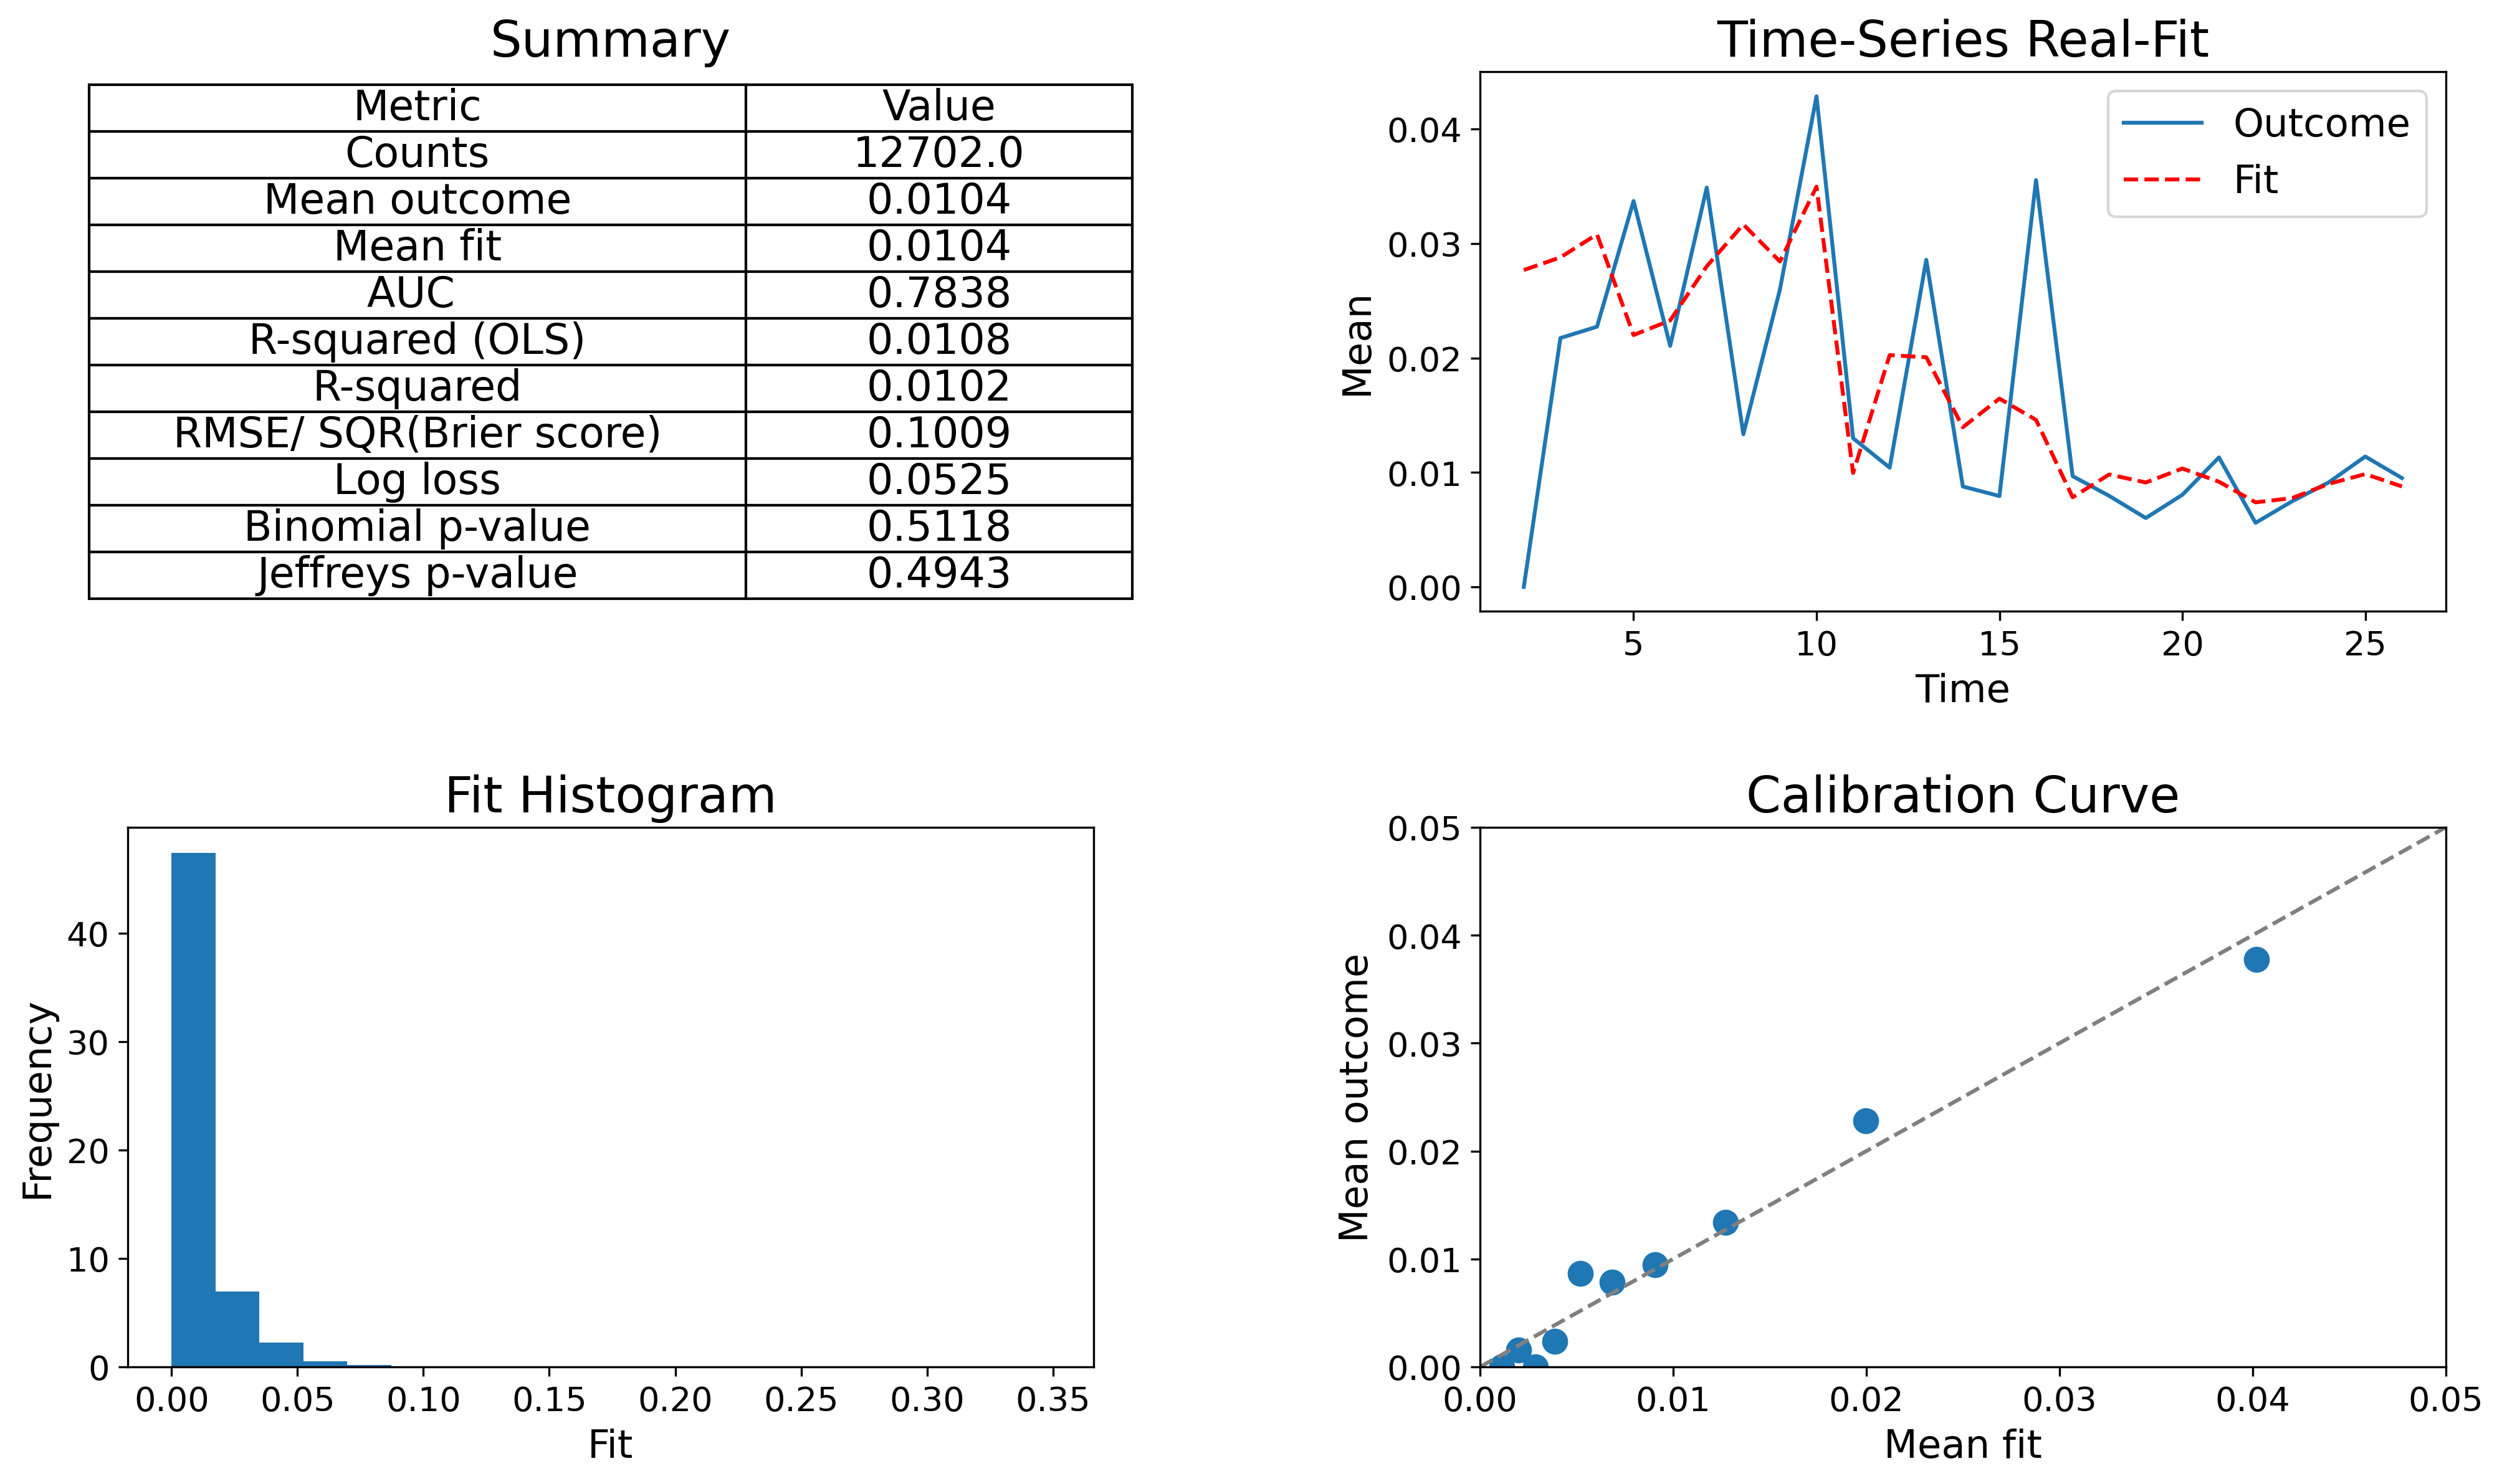

In [6]:
predictions_train = model_lr.predict_proba(X_train_scaled)[:,1].T  

validation(predictions_train, y_train, data_train['time'].values)  

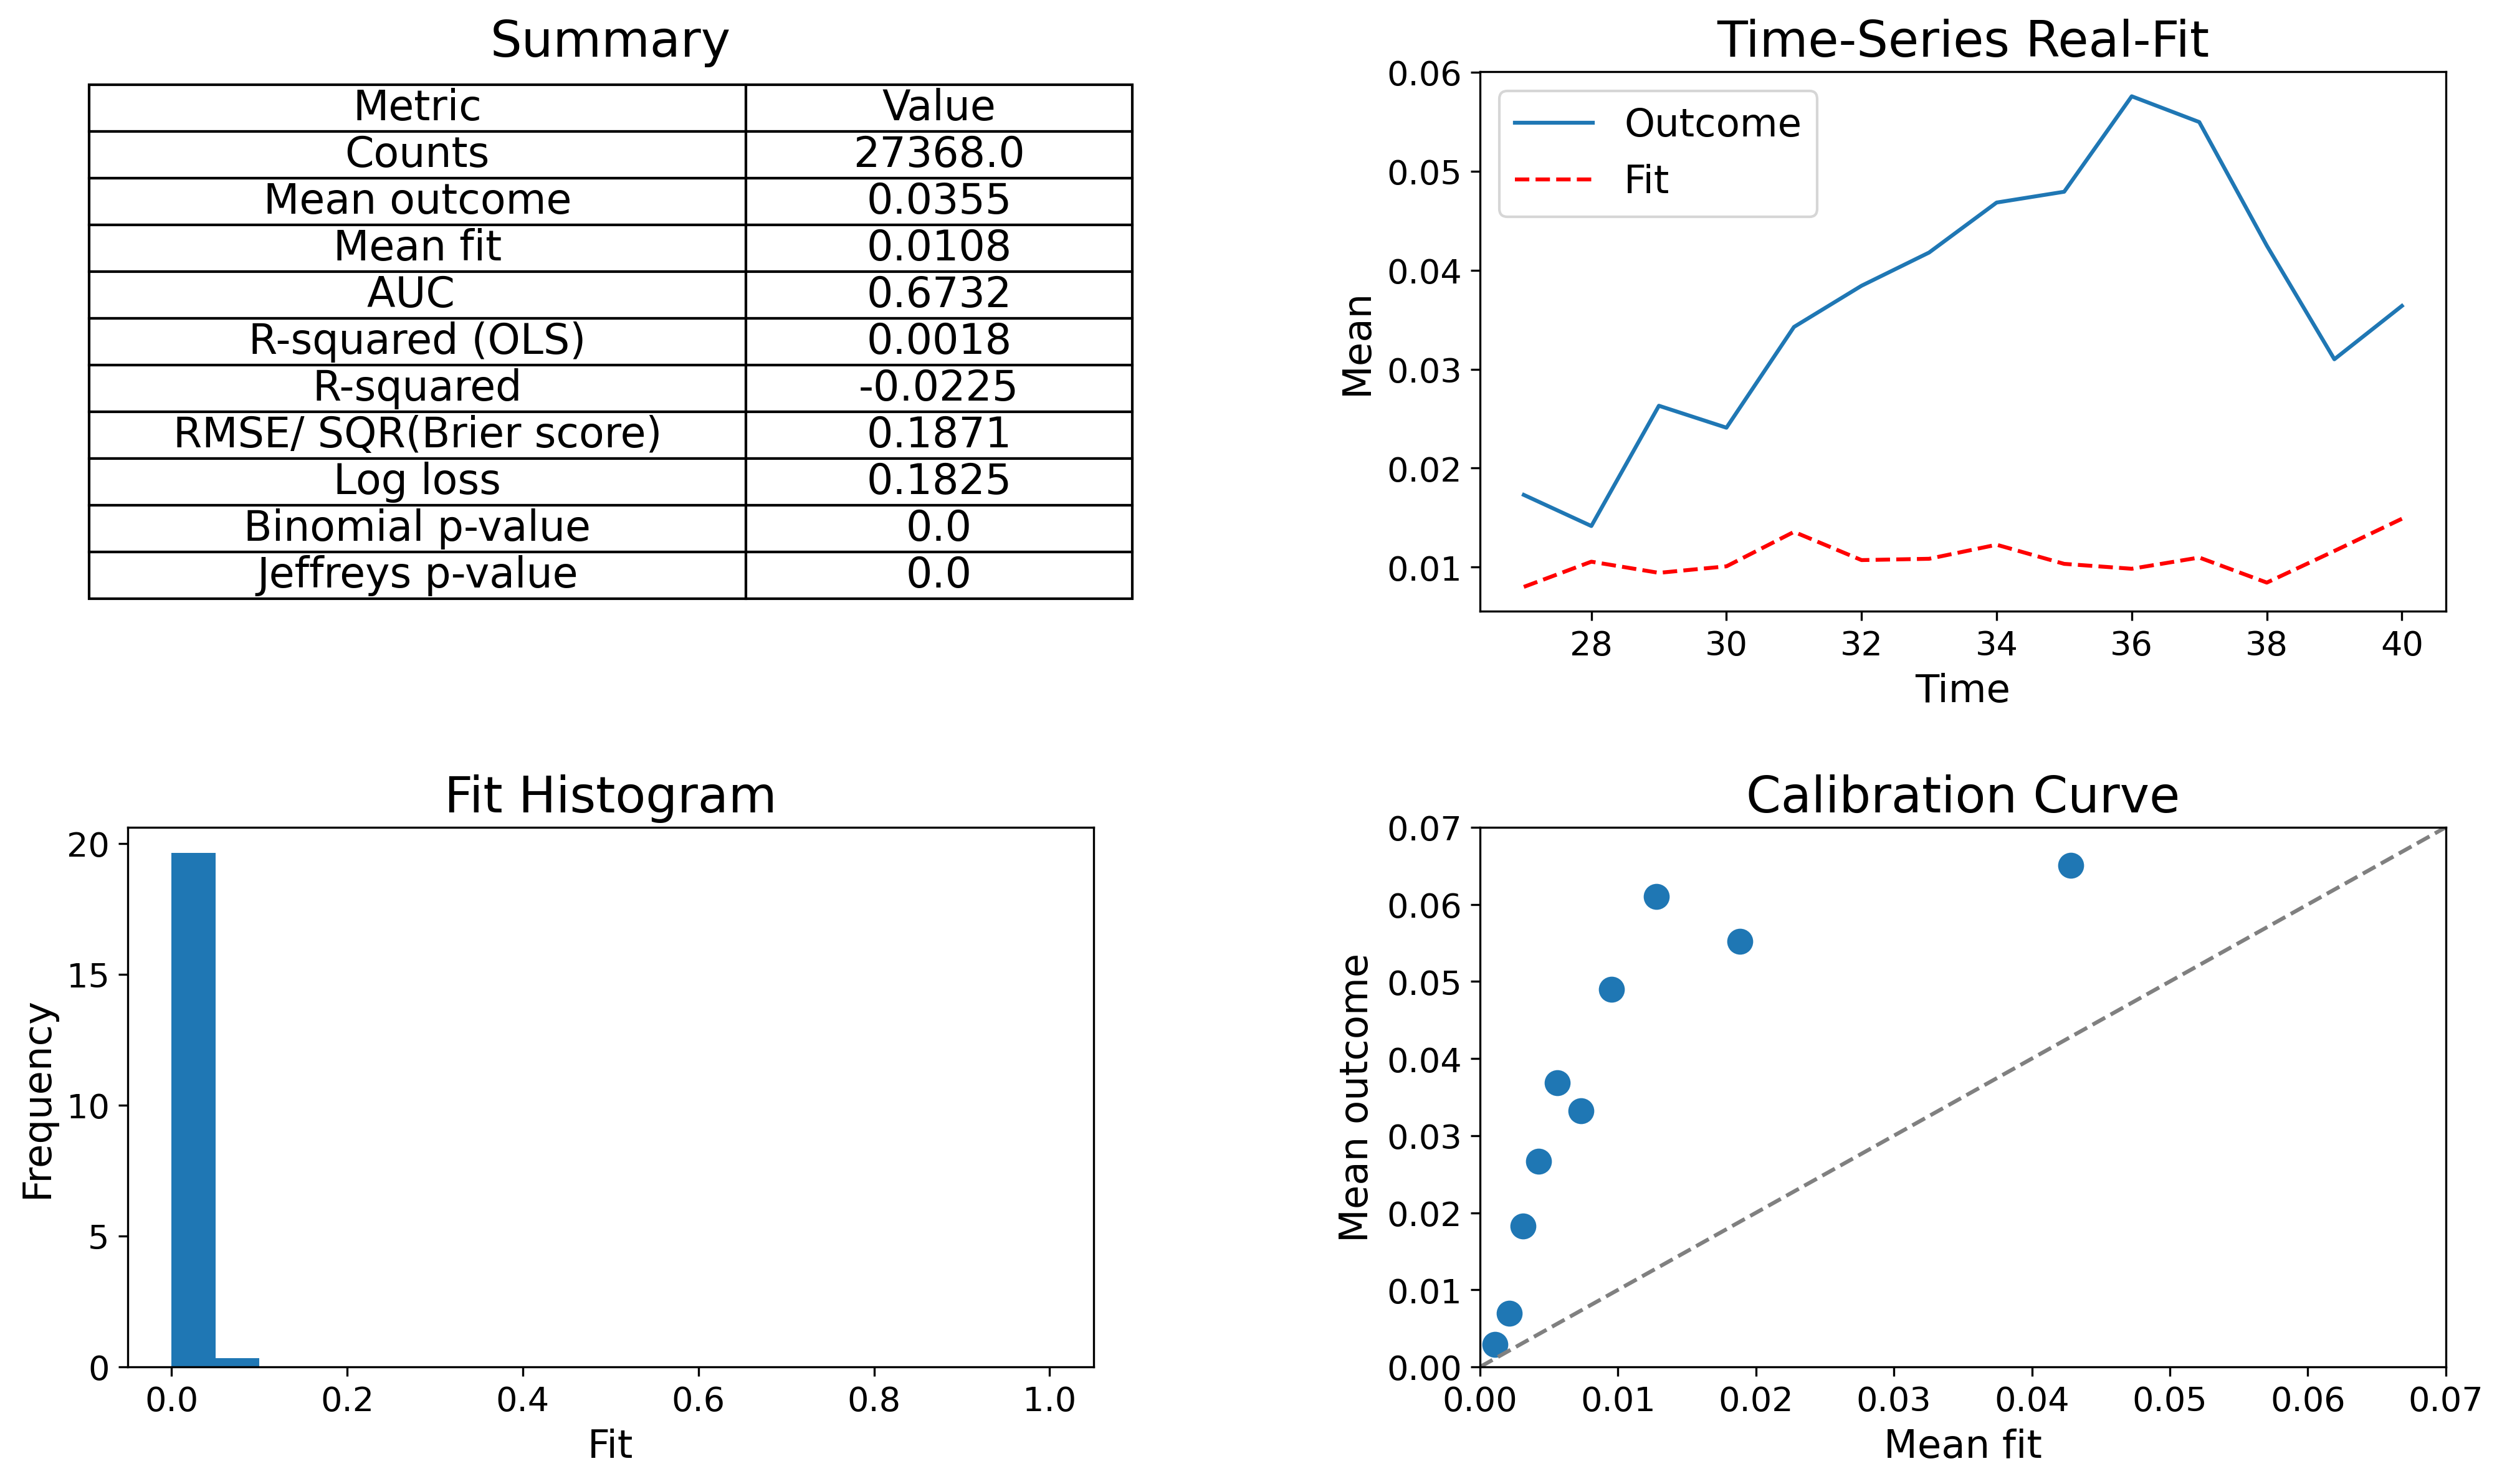

In [7]:
predictions_test = model_lr.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_logreg = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_logreg = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

In [8]:
model_lr_reg1 = LogisticRegression(penalty='l1', fit_intercept=True, C=0.2, solver='saga',  tol =1e-15, max_iter=3000)  
model_lr_reg1.fit(X_train_scaled, y_train)  
print('Coefficients:', model_lr_reg1.coef_.round(decimals=4))  
print('Intercept:', model_lr_reg1.intercept_.round(decimals=4))  
predictions_reg1 = model_lr_reg1.predict_proba(X_train_scaled) 
print('Log Loss:', log_loss(y_train, predictions_reg1).round(4)) 

Coefficients: [[-0.1857 -0.1932  0.2858 -0.743   0.     -0.014   0.      0.     -0.0279
  -0.0352  0.    ]]
Intercept: [-5.019]
Log Loss: 0.0526


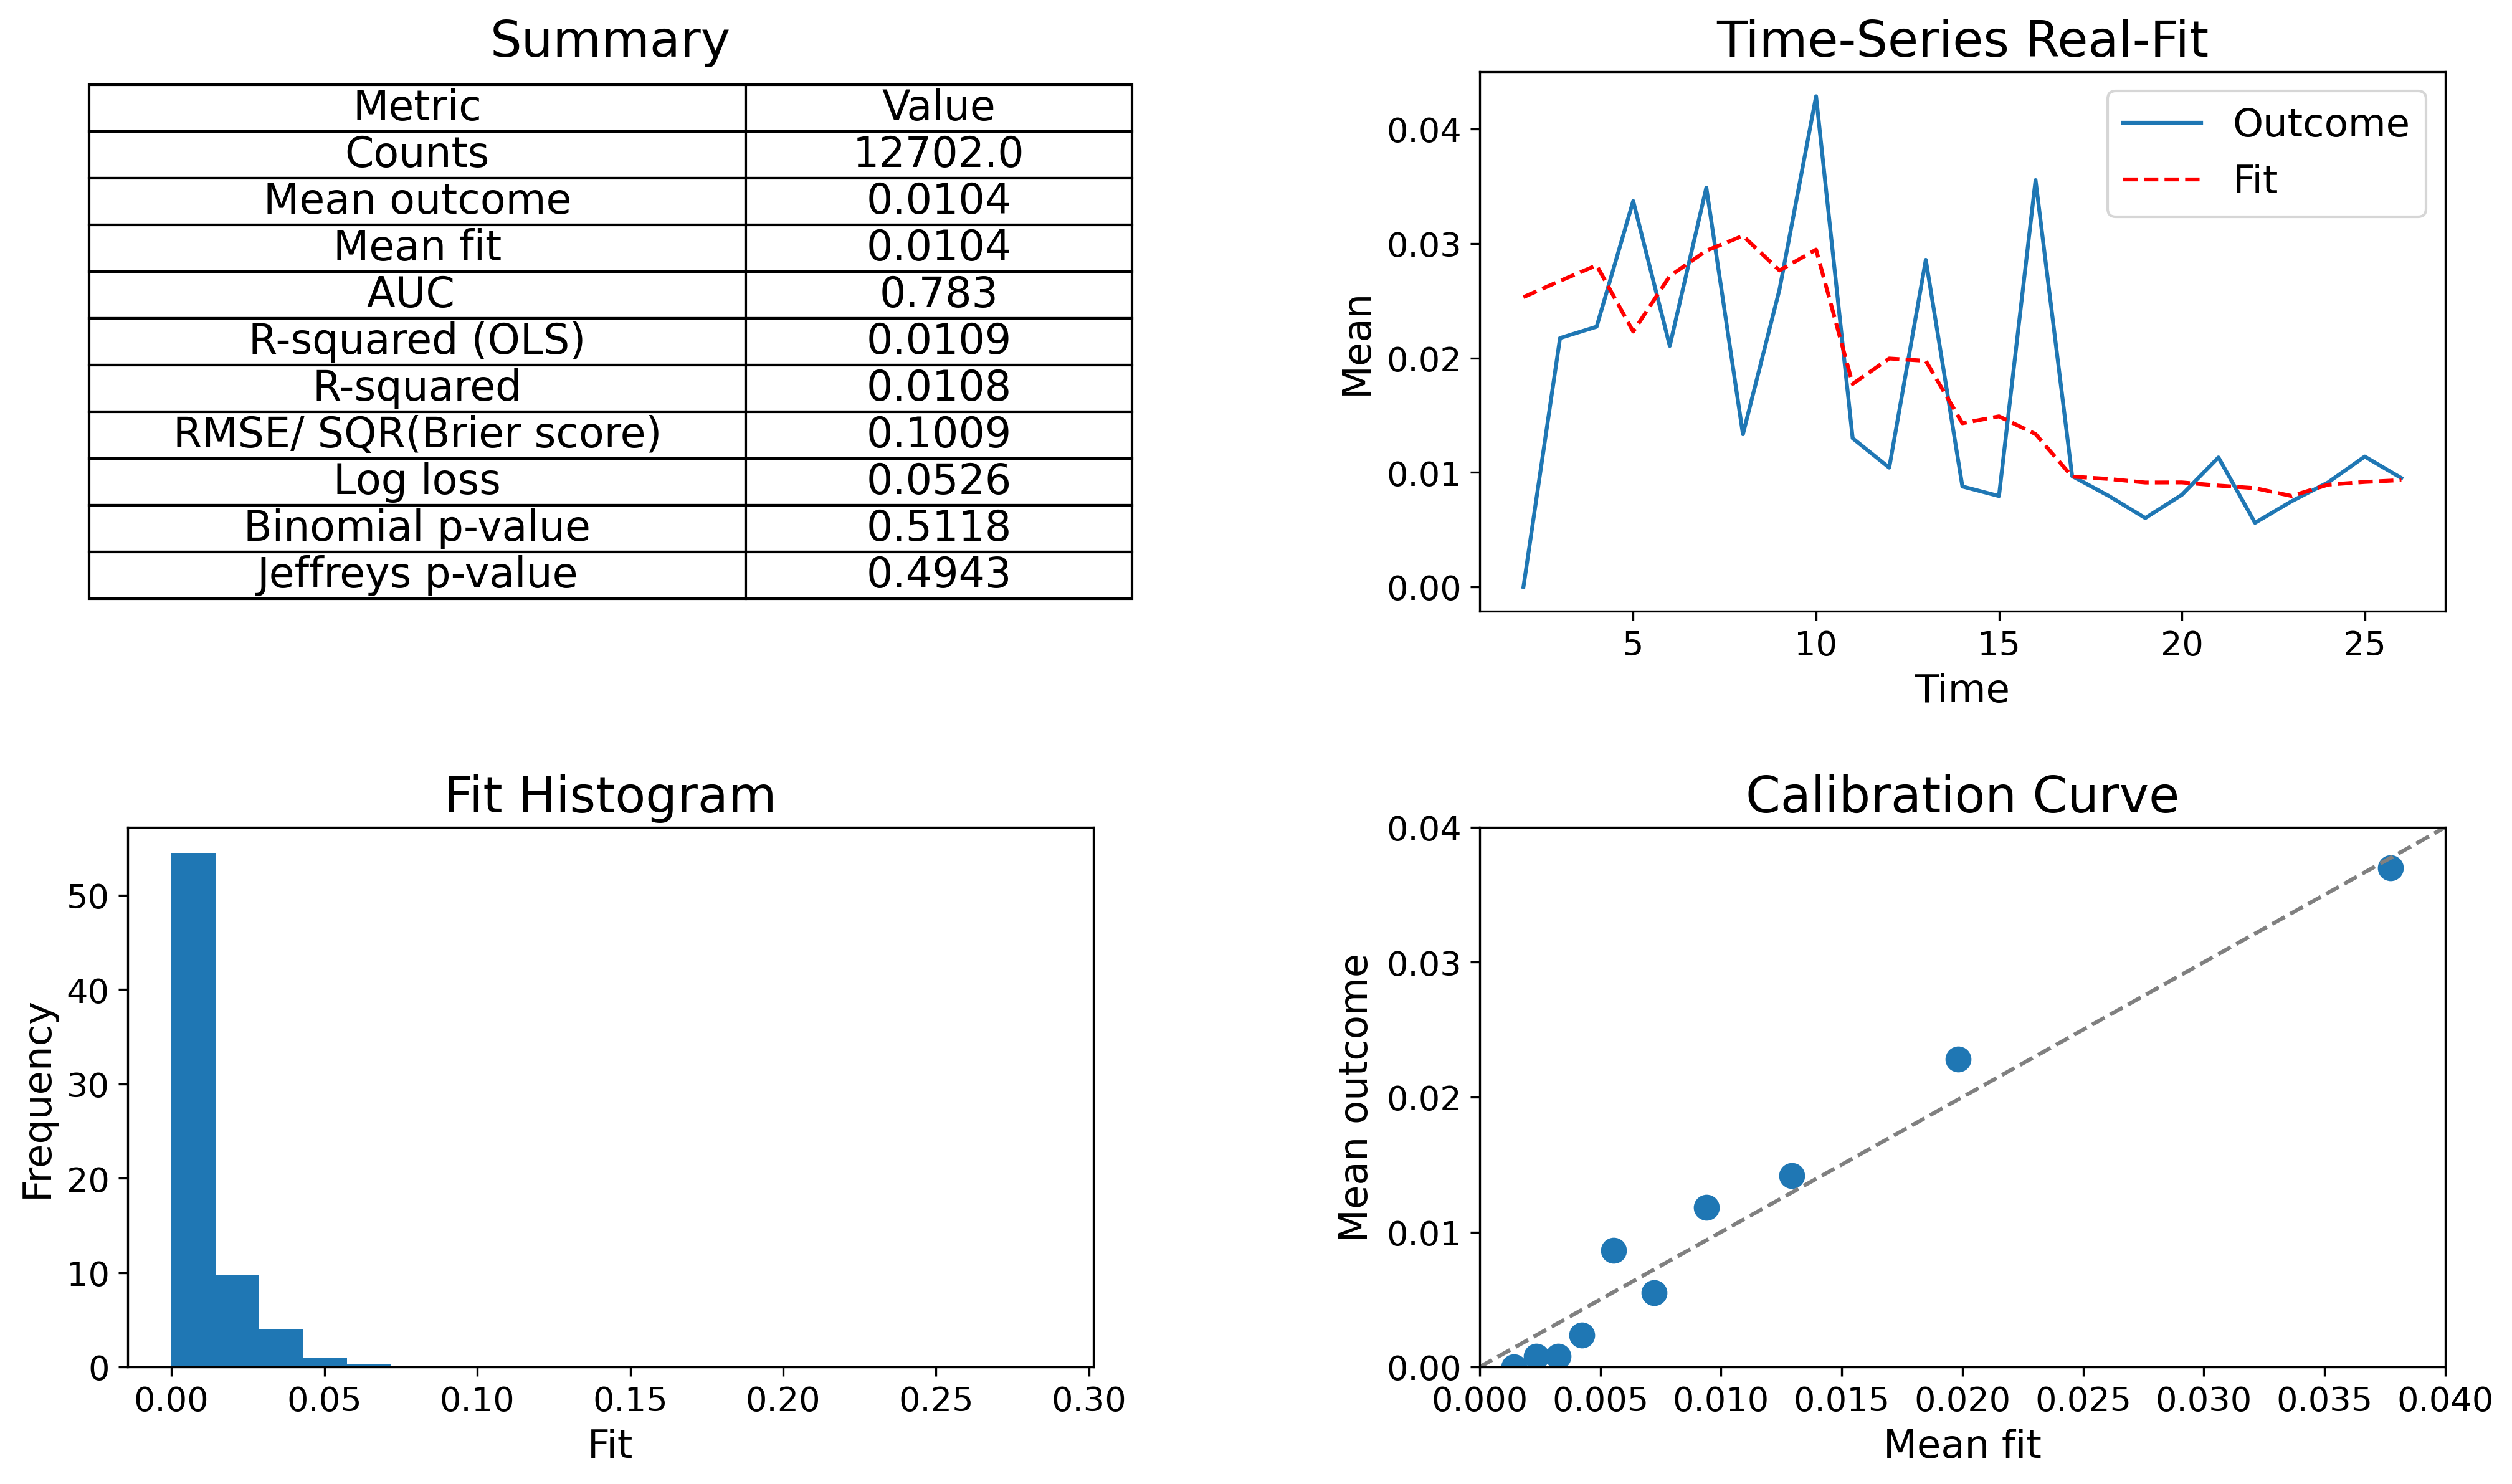

In [9]:
predictions_train = model_lr_reg1.predict_proba(X_train_scaled)[:,1].T 
validation(predictions_train, y_train, data_train['time'].values) 

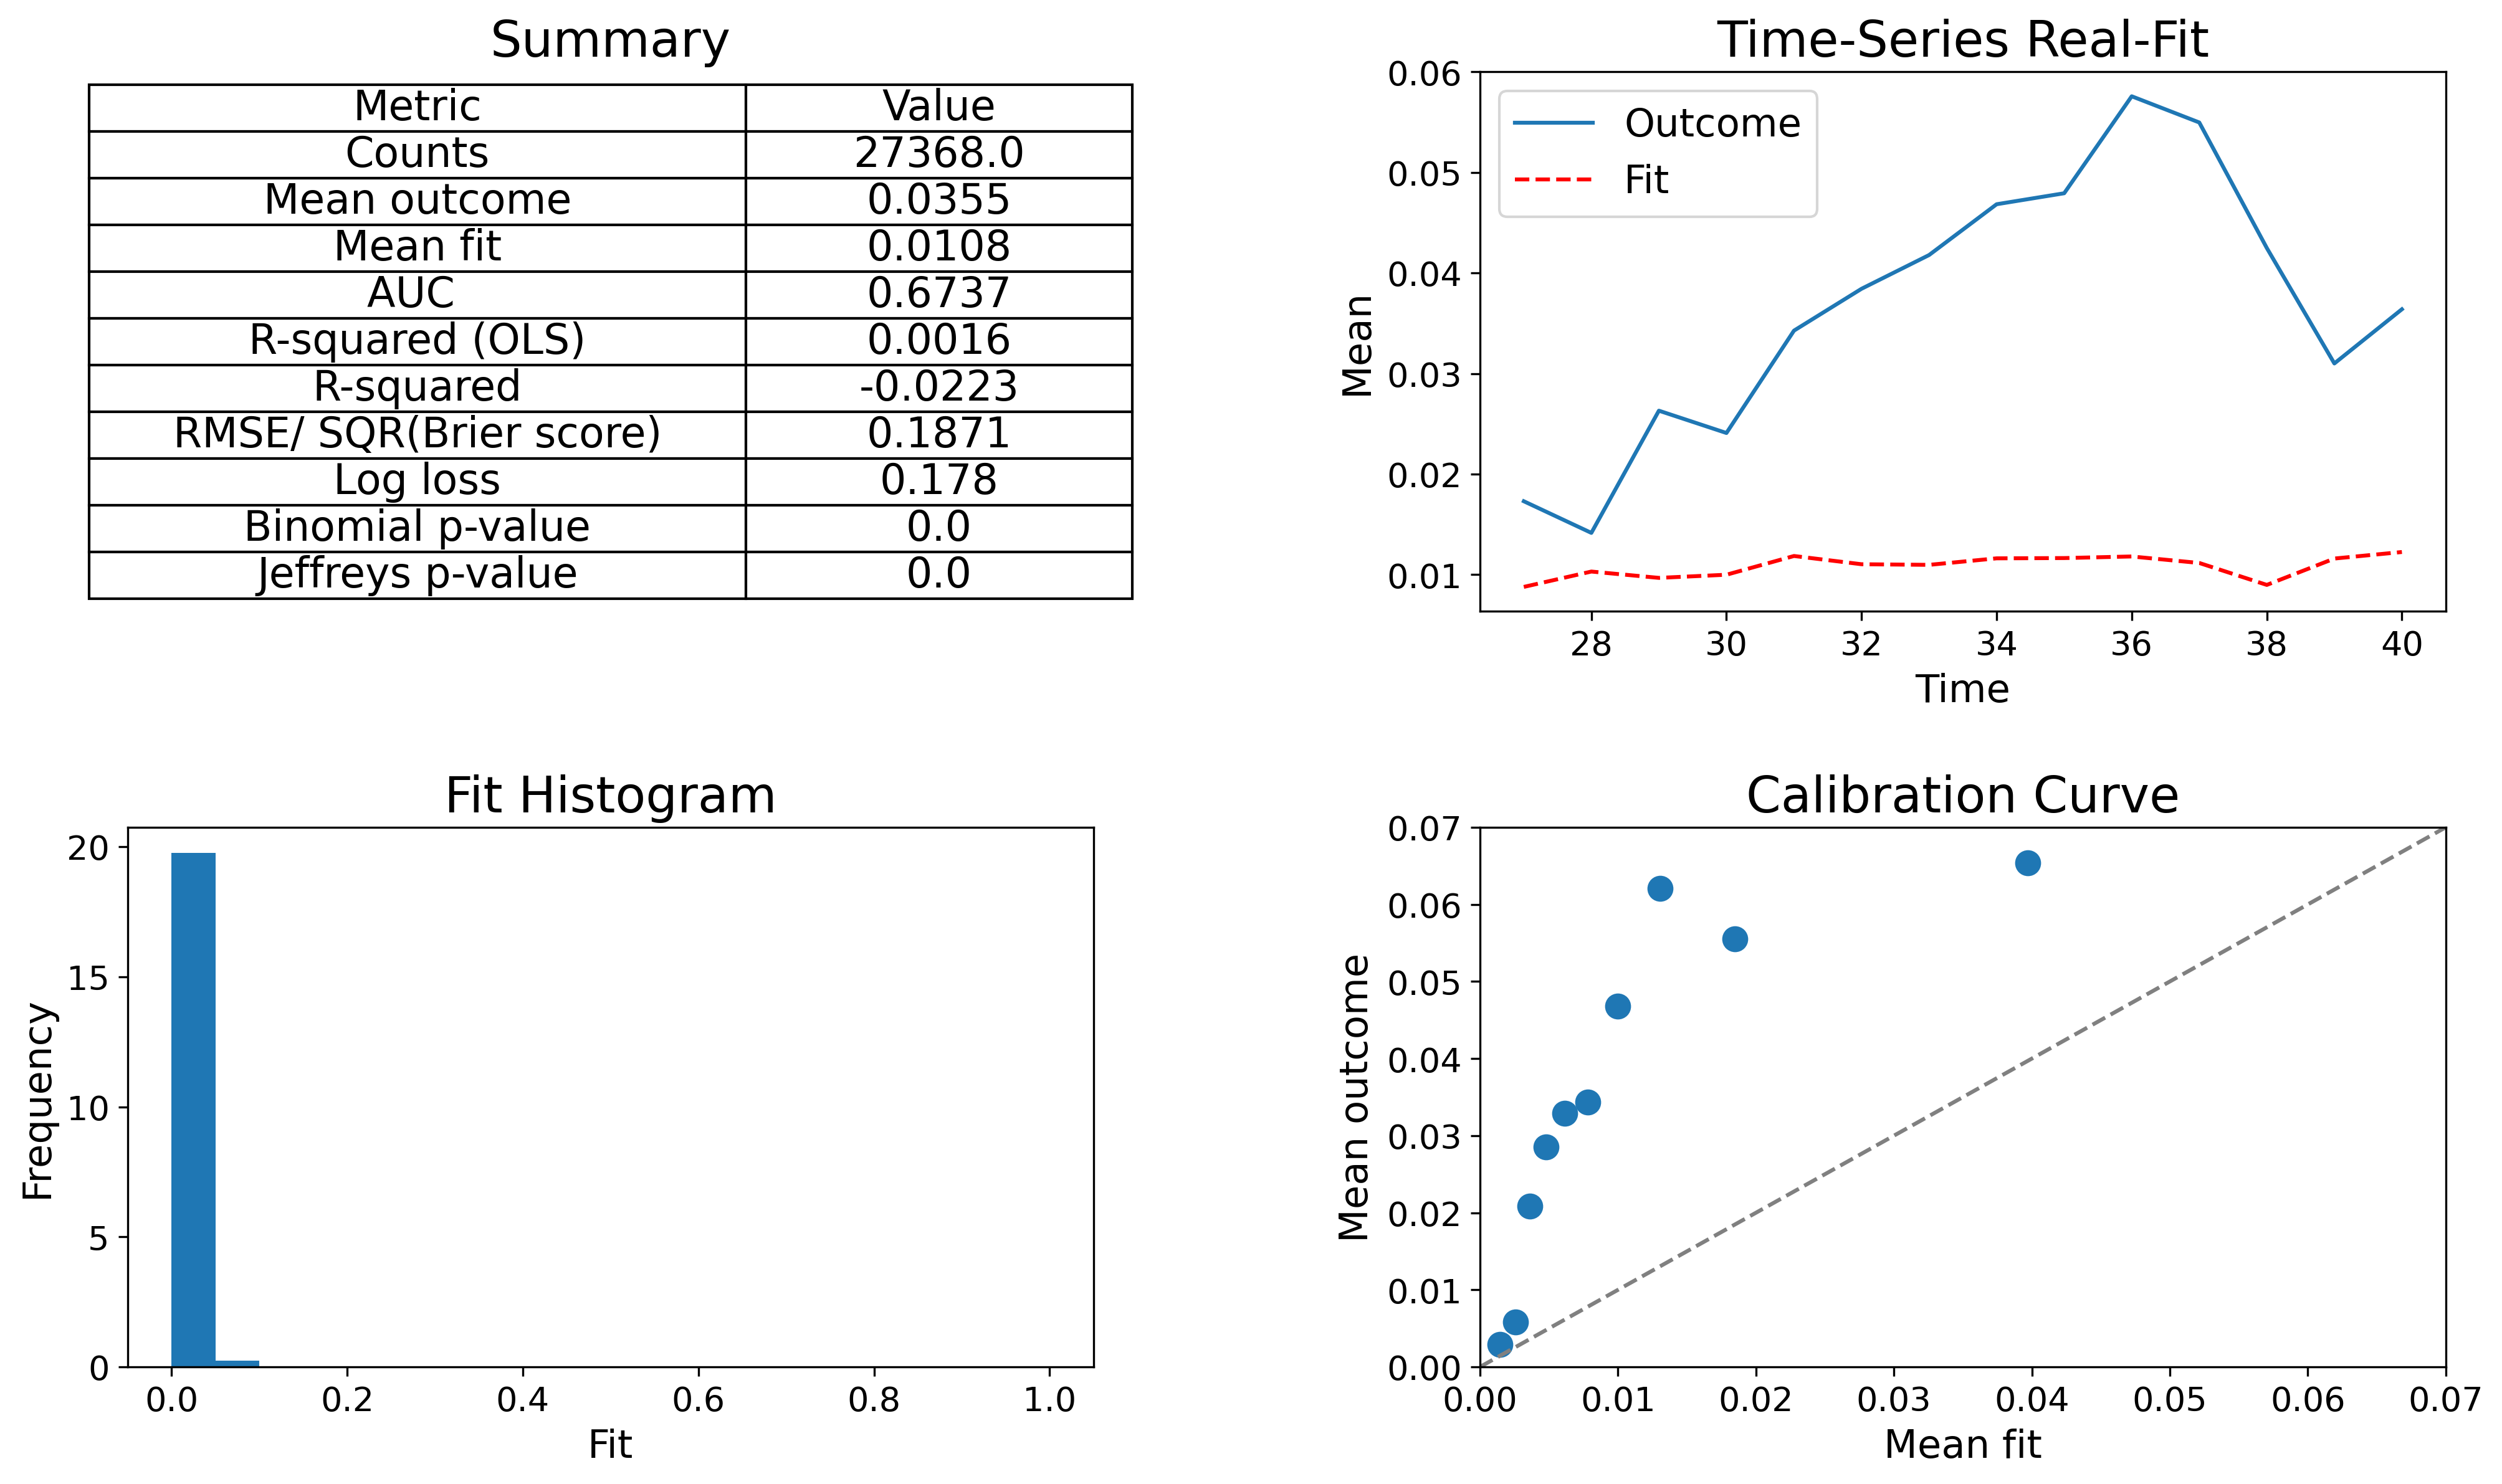

In [10]:
predictions_test = model_lr_reg1.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_logreg_reg1 = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_logreg_reg1 = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

In [12]:
np.random.seed(12345) 
penalty = ['l1', 'l2']
C_range = [0.1, 0.2, 0.5, 0.8, 1, 2, 5] 
params_lr = {'penalty': penalty, 'C': C_range}
print(params_lr) 
model_lr_reg = LogisticRegression(fit_intercept=True, solver='saga', tol =1e-15, max_iter  =5000) 

gs_lr = GridSearchCV(model_lr_reg, params_lr, verbose=2, n_jobs=2, cv=5, scoring = 'roc_auc')  
gs_lr.fit(X_train_scaled, y_train) 
print(gs_lr.best_params_) 

filename = 'Mortgage_lr_GridSearch.sav' 
pickle.dump(gs_lr, open(filename, 'wb'))

{'penalty': ['l1', 'l2'], 'C': [0.1, 0.2, 0.5, 0.8, 1, 2, 5]}
Fitting 5 folds for each of 14 candidates, totalling 70 fits
{'C': 0.1, 'penalty': 'l1'}


In [13]:
filename = 'Mortgage_lr_GridSearch.sav'  
gs_lr = pickle.load(open(filename, 'rb')) 
model_lr_best = LogisticRegression(penalty = gs_lr.best_params_.get('penalty'),  C = gs_lr.best_params_.get('C'),  fit_intercept=True, solver='saga', tol =1e-15, max_iter=5000)  
model_lr_best.fit(X_train_scaled, y_train) 
print('Coefficients:', model_lr_best.coef_.round(decimals=4))
print('Intercept:', model_lr_best.intercept_.round(decimals=4)) 


Coefficients: [[-0.0763 -0.1403  0.2736 -0.6955  0.      0.      0.      0.      0.
  -0.0118  0.    ]]
Intercept: [-4.9579]


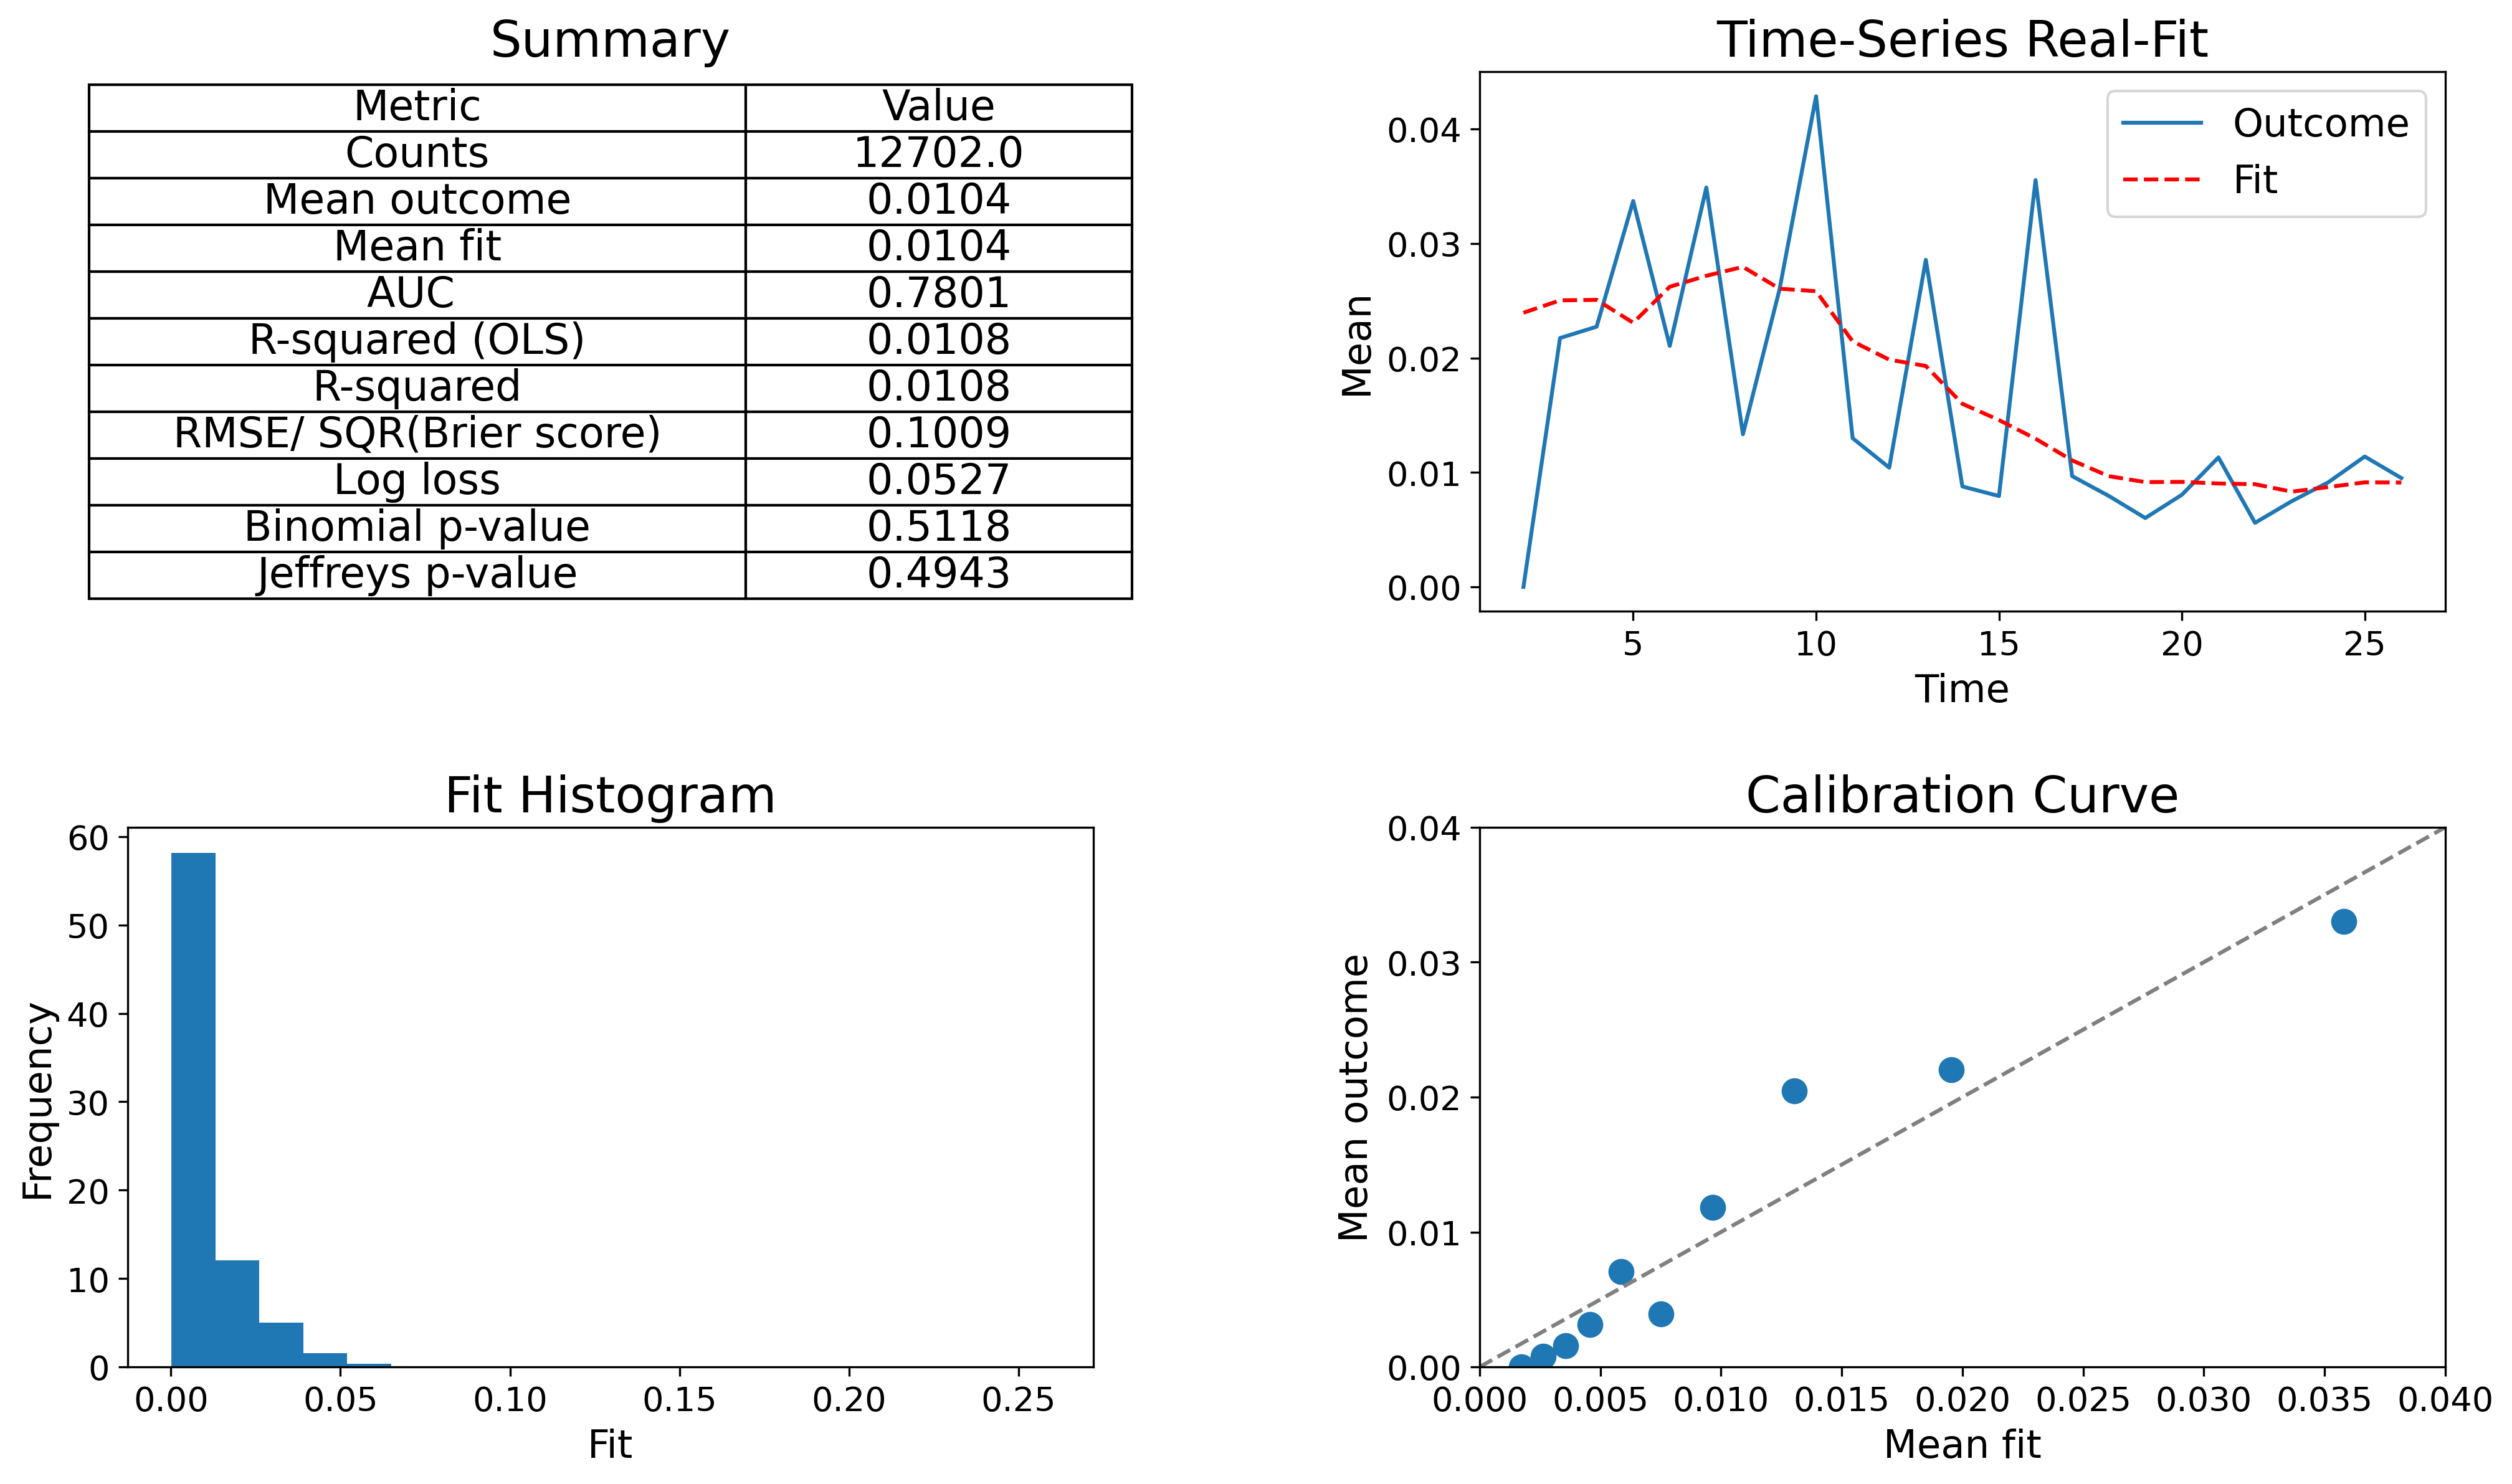

In [15]:
predictions_train = model_lr_best.predict_proba(X_train_scaled)[:,1].T
validation(predictions_train, y_train, data_train['time'].values) 

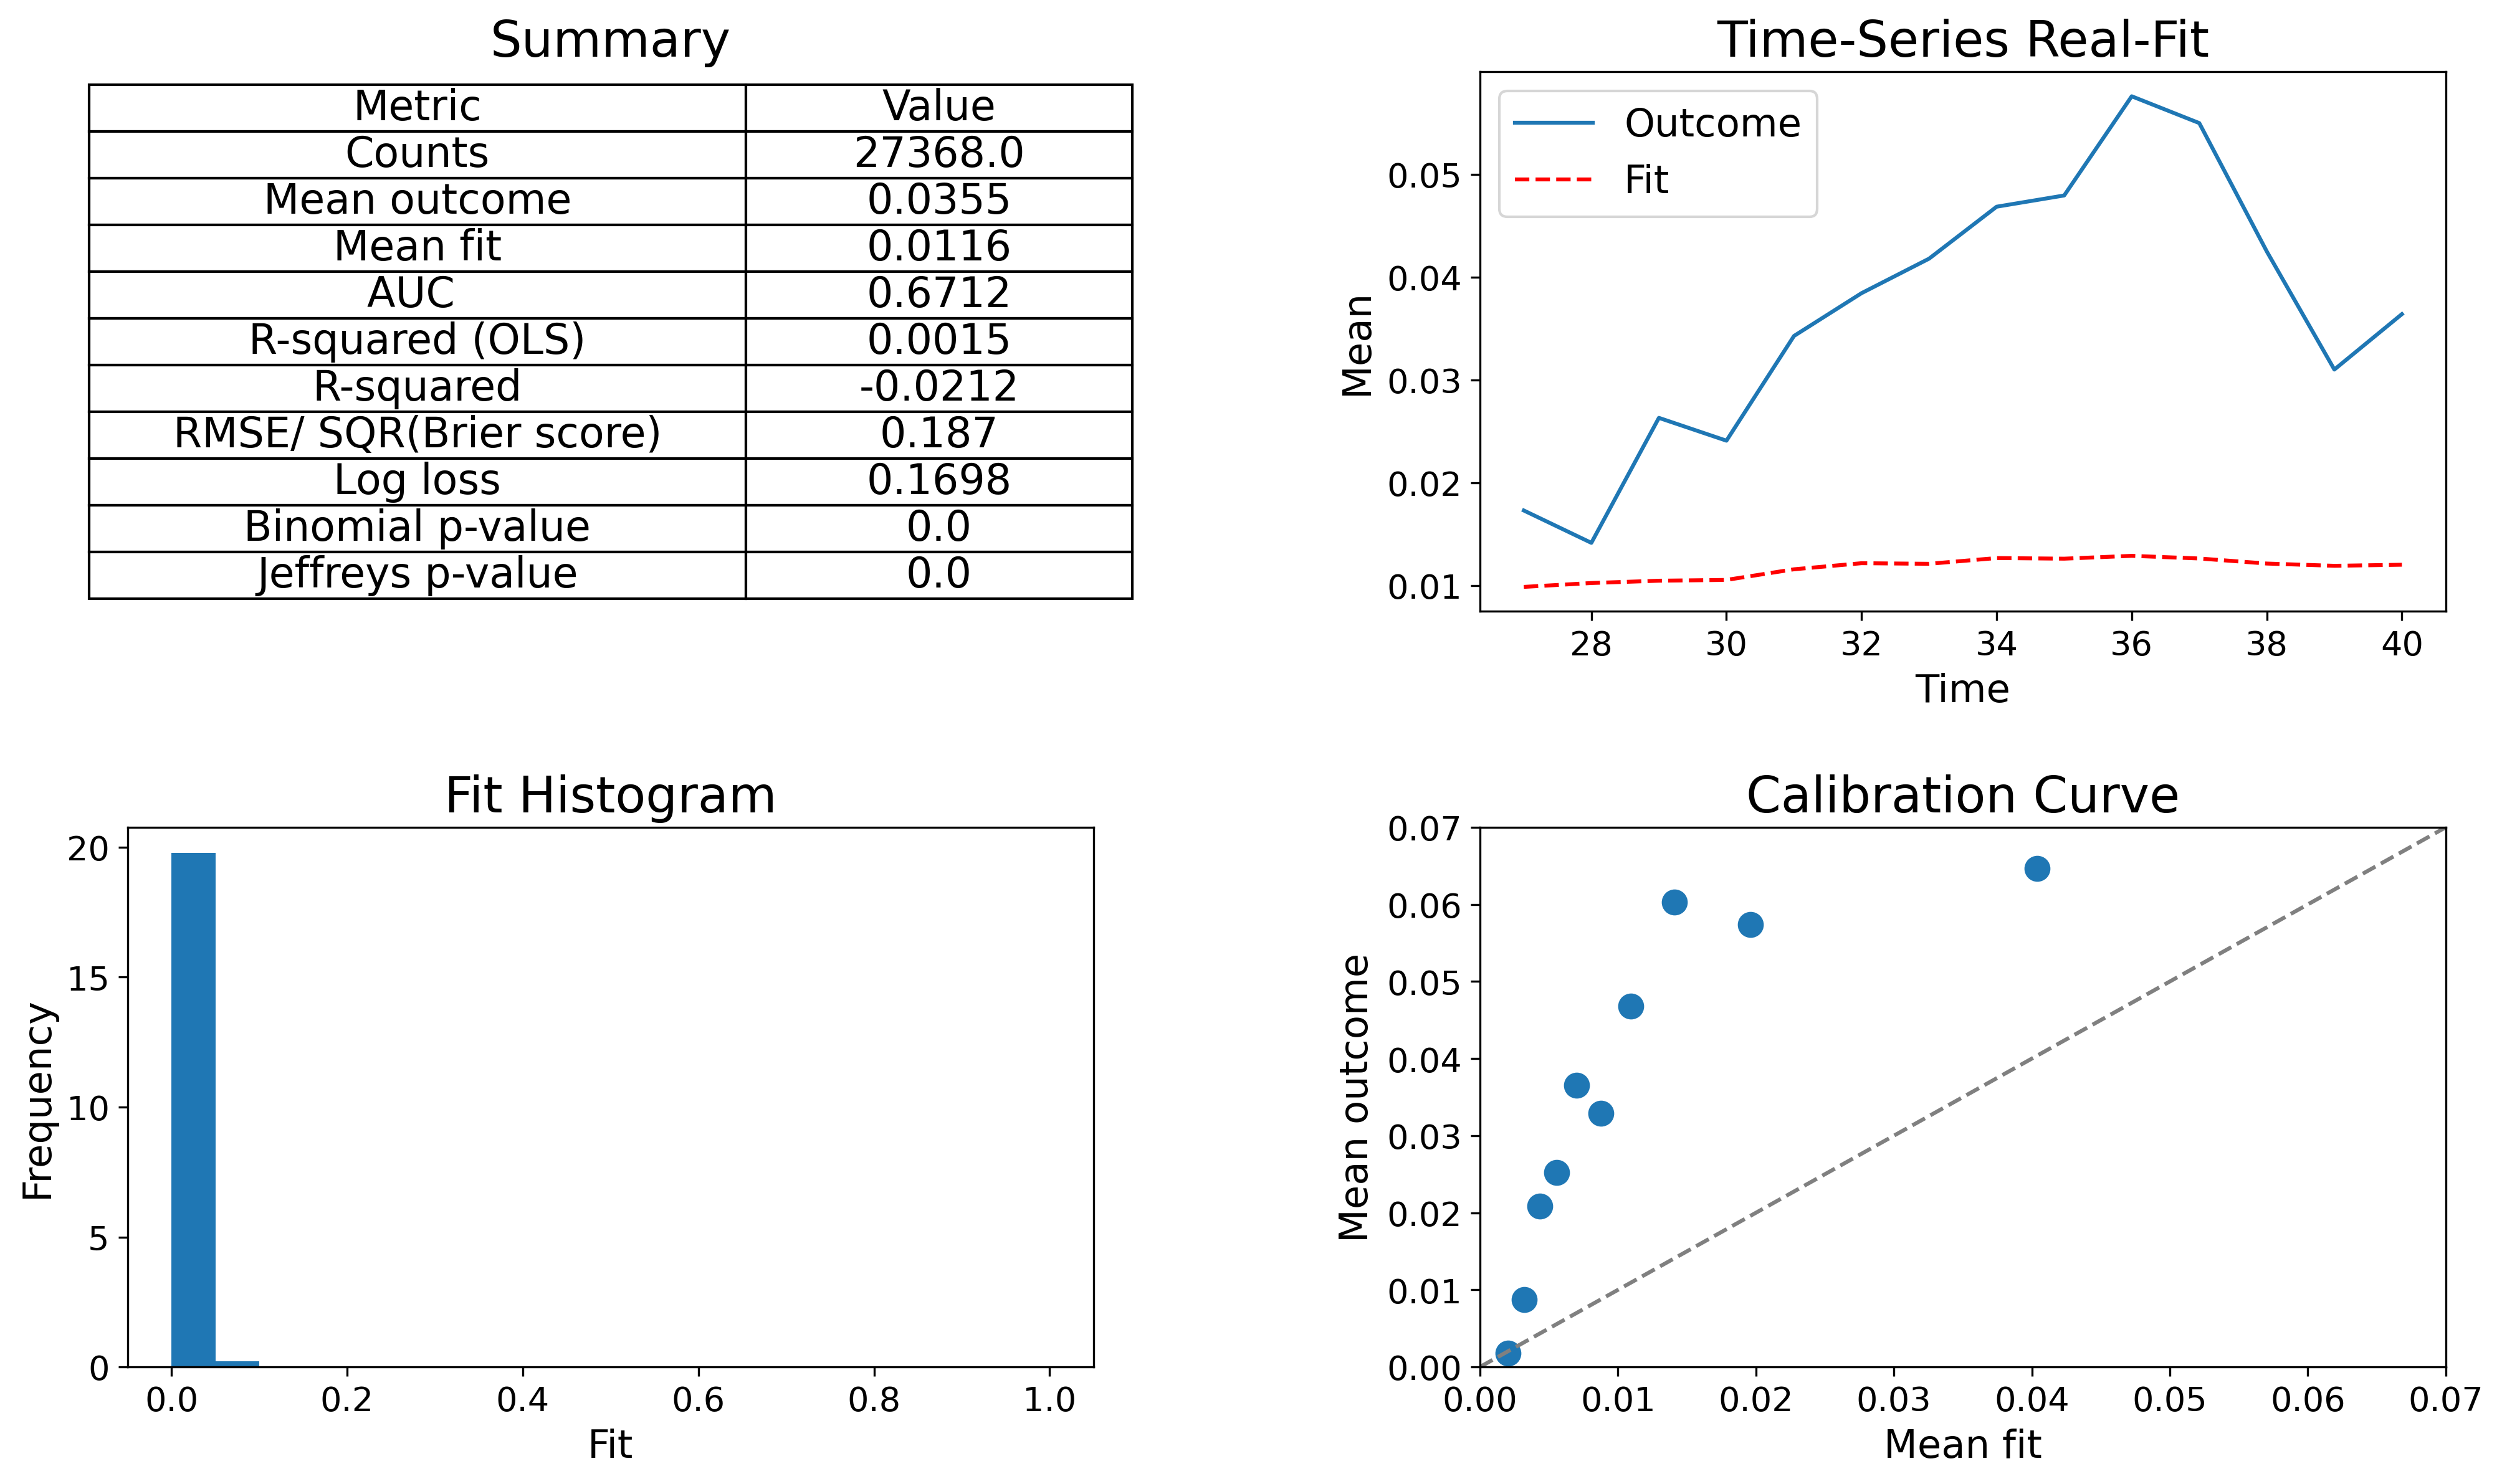

In [16]:
predictions_test = model_lr_best.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_logreg_reg2 = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_logreg_reg2 = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

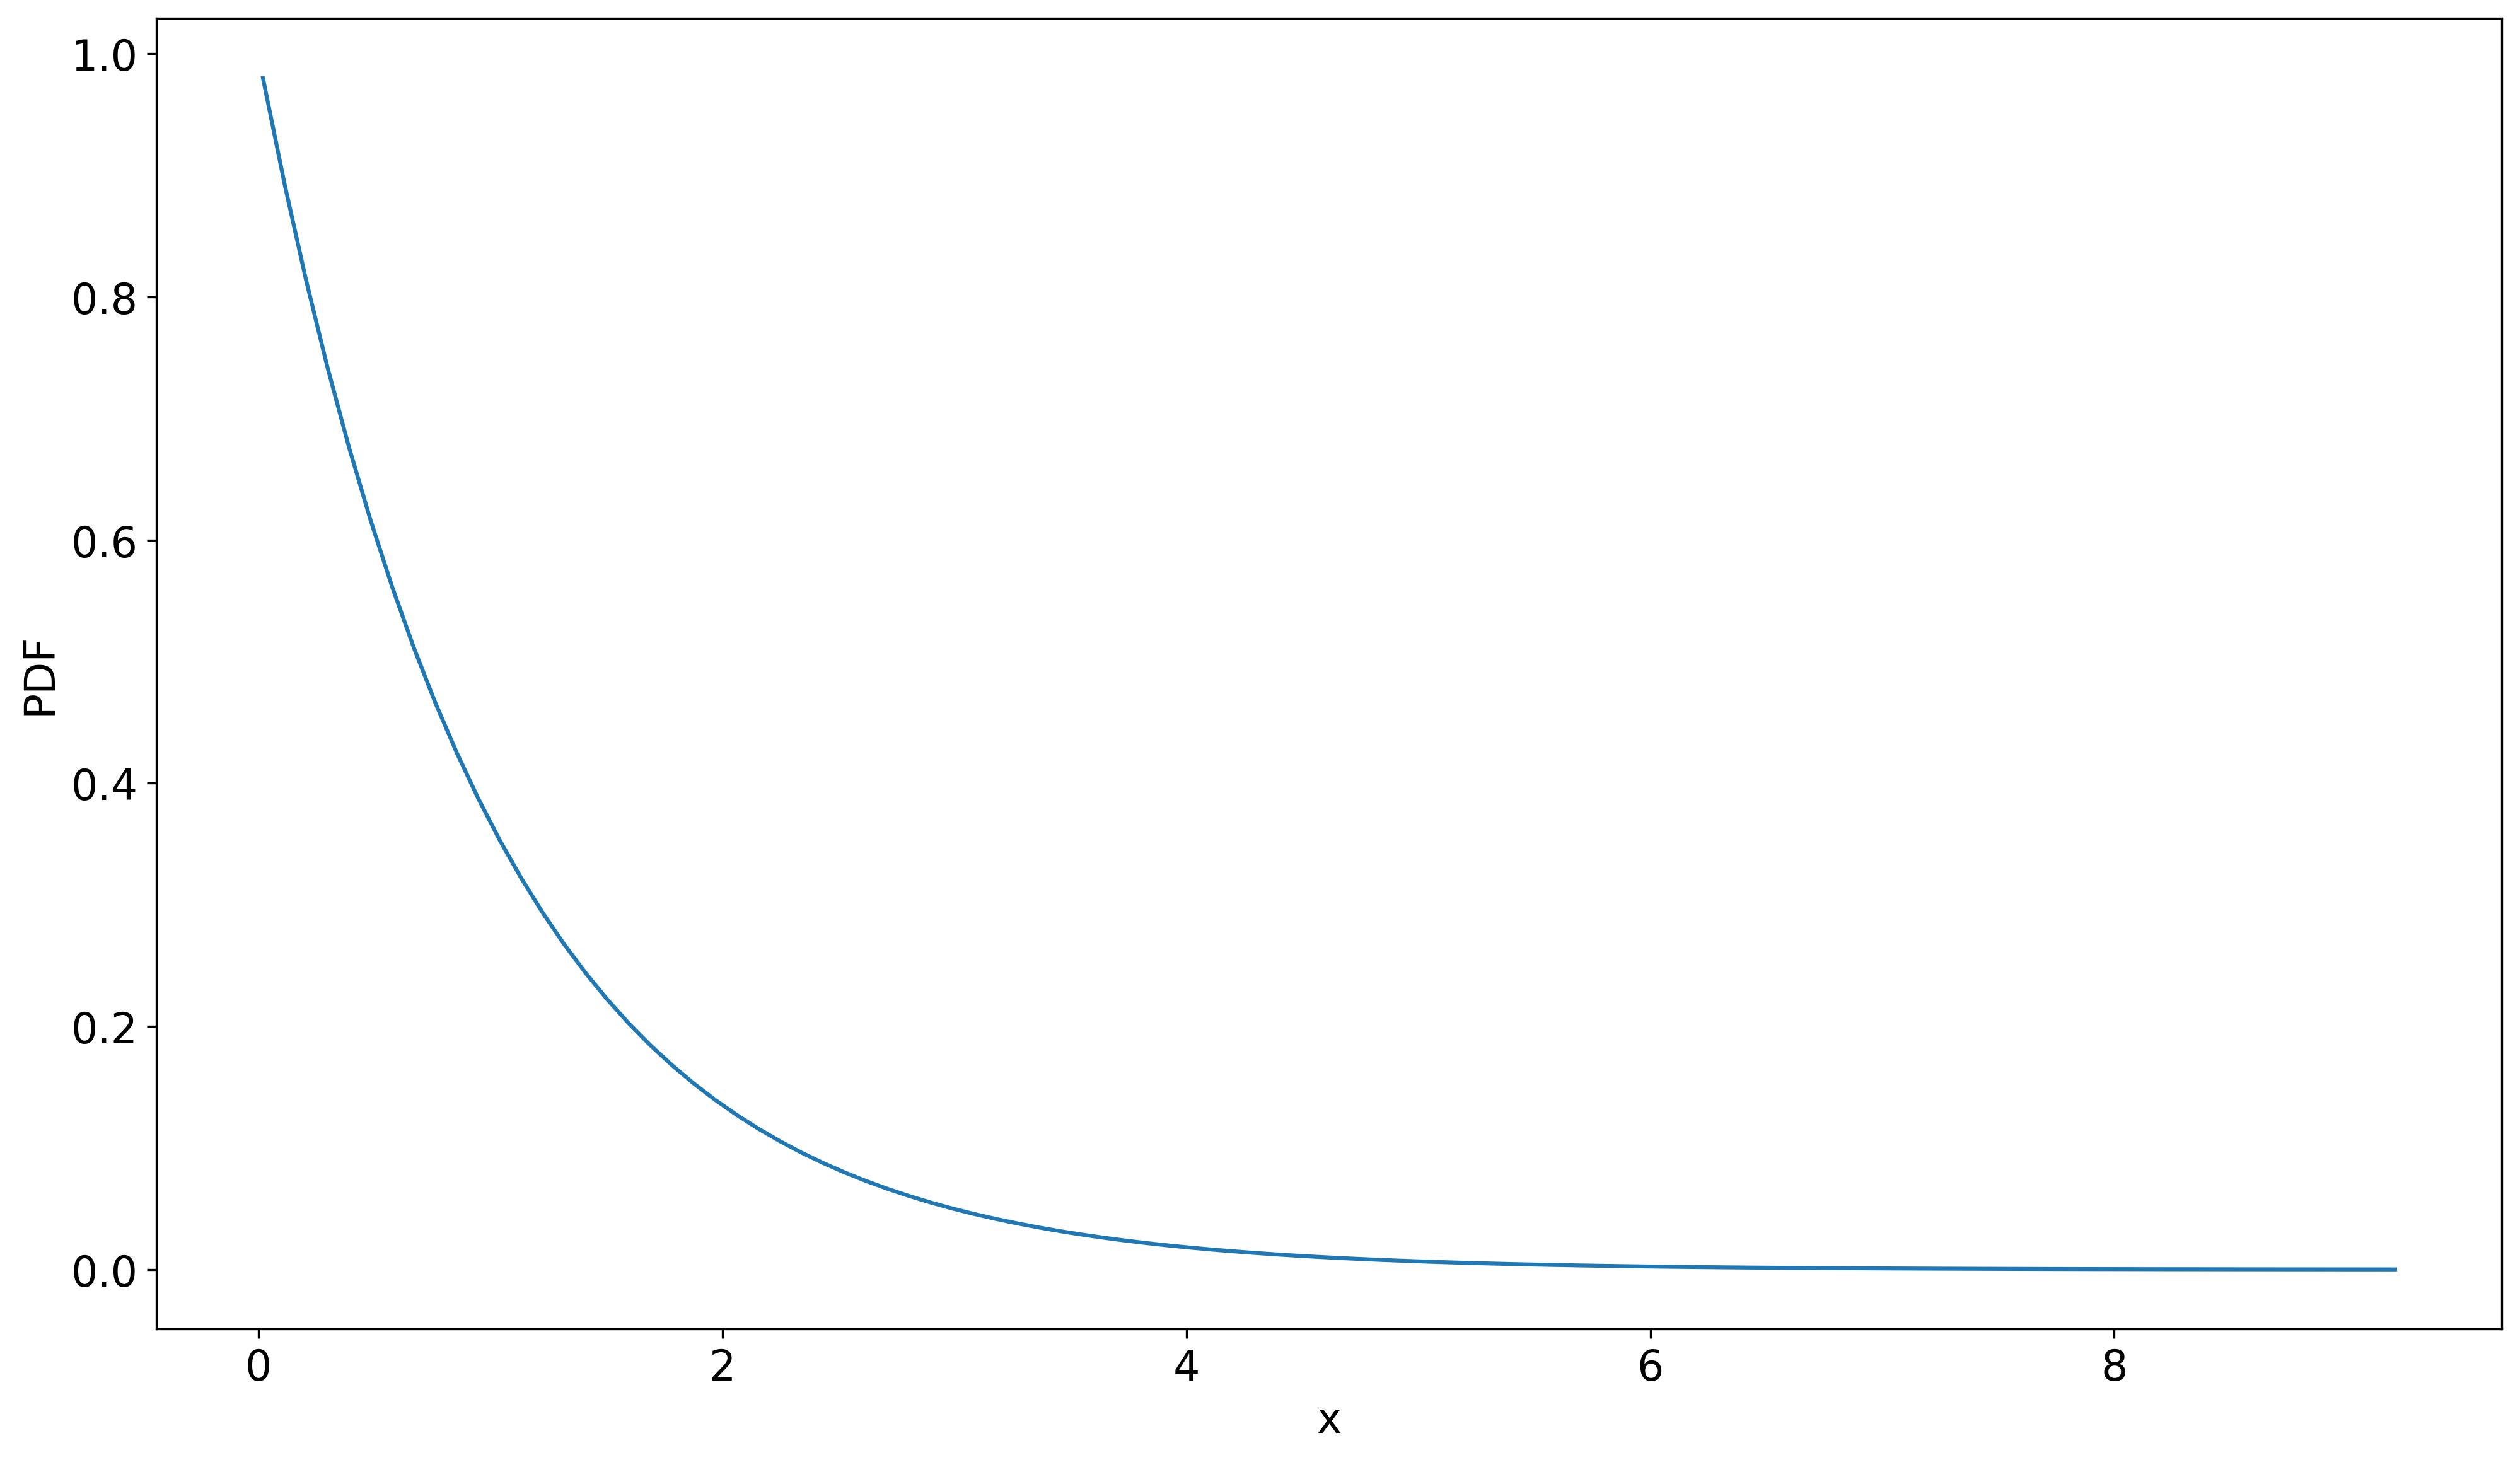

In [17]:
lambda_exp = 0.5  
scale = 1/lambda_exp 
x = np.linspace(expon.ppf(0.01)*scale, expon.ppf(0.99)*scale, 100)  
plt.plot(x, expon.pdf(x)) 
plt.xlabel('x') 
plt.ylabel('PDF') 
plt.show() 

In [18]:
np.random.seed(12345)  
params_lr = {'penalty': ['l1', 'l2'], 'C': expon(scale=0.5)}
model_lr_reg = LogisticRegression(fit_intercept=True, solver='saga', tol=1e-15, max_iter  =5000) 
rs_lr = RandomizedSearchCV(model_lr_reg, params_lr, verbose=1, n_iter=50, n_jobs=2, cv=5,  scoring='roc_auc')  
rs_lr.fit(X_train_scaled, y_train)  
print(rs_lr.best_params_) 
filename = 'Mortgage_lr_RandomizedSearch.sav'  
pickle.dump(rs_lr, open(filename, 'wb'))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
{'C': 0.025903531714783053, 'penalty': 'l1'}


In [19]:
filename = 'Mortgage_lr_RandomizedSearch.sav'  
rs_lr = pickle.load(open(filename, 'rb')) 
model_lr_best = LogisticRegression(  penalty = rs_lr.best_params_.get('penalty'),  C = rs_lr.best_params_.get('C'),  fit_intercept=True, solver='saga', tol=1e-15, max_iter=5000)  
model_lr_best.fit(X_train_scaled, y_train)  
print('Coefficients:', model_lr_best.coef_.round(decimals=4)) 
print('Intercept:', model_lr_best.intercept_.round(decimals=4))

Coefficients: [[ 0.      0.      0.2001 -0.488   0.      0.      0.      0.      0.
   0.      0.    ]]
Intercept: [-4.759]


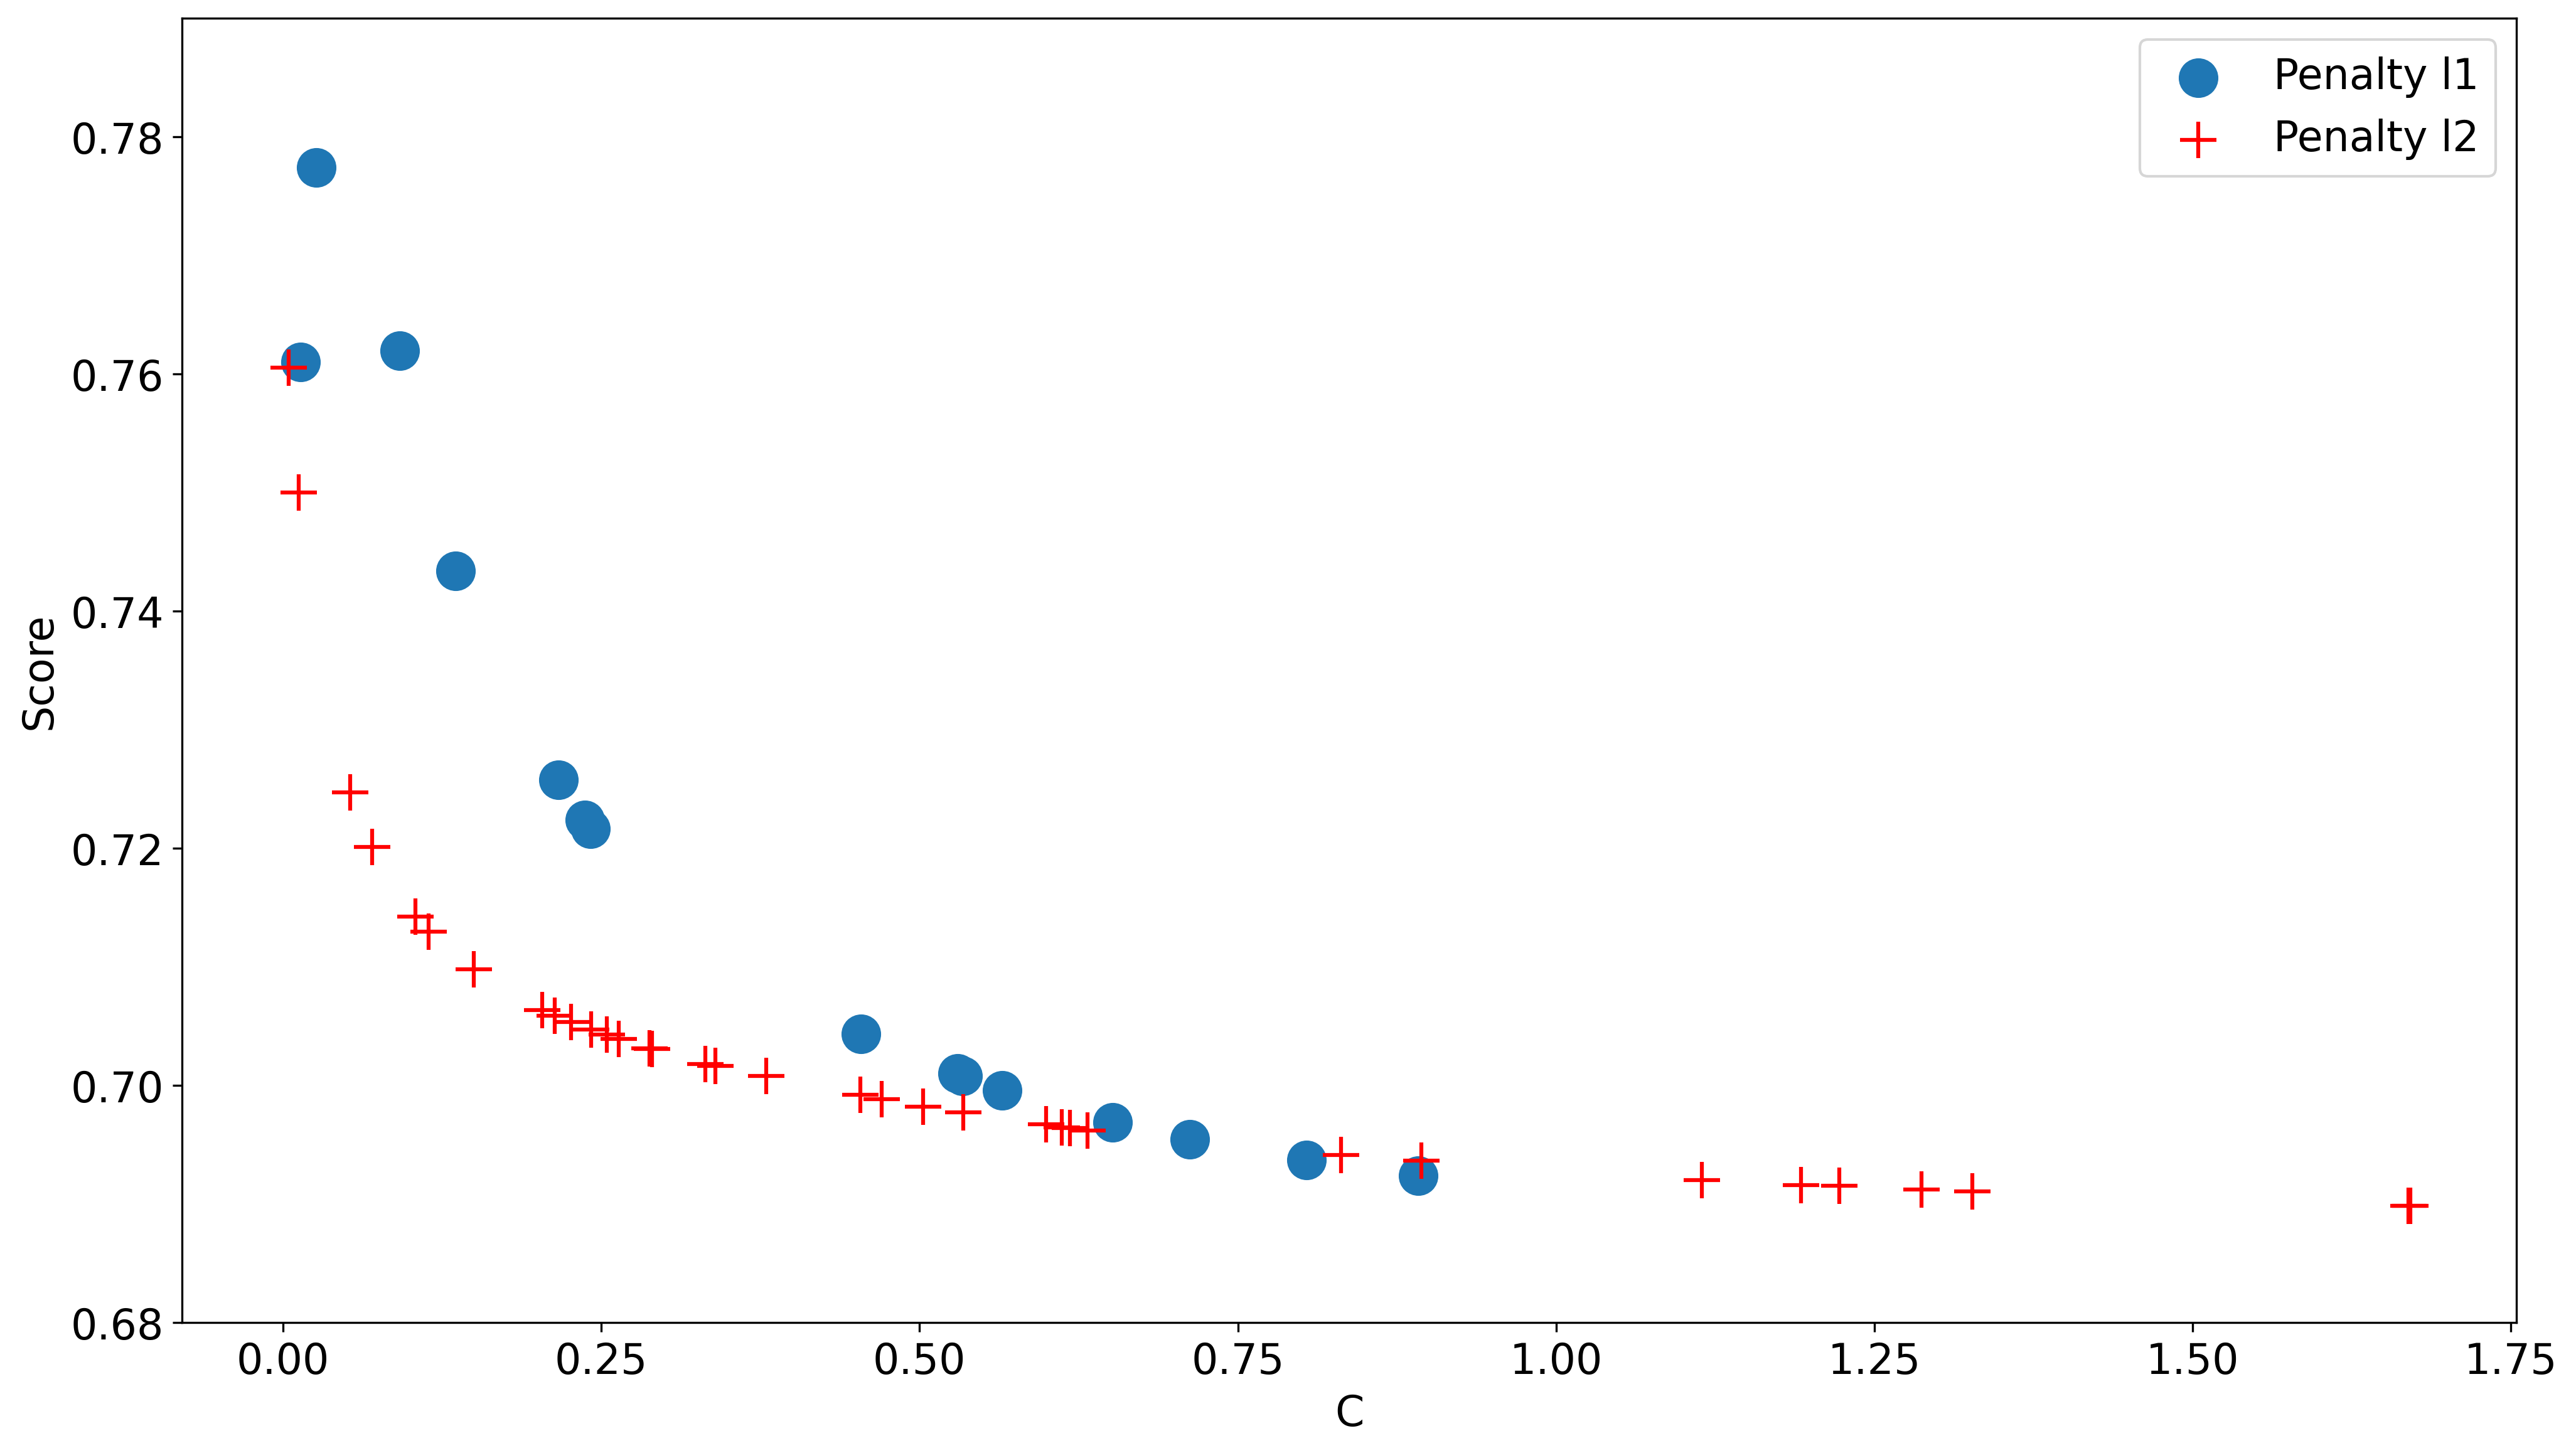

In [20]:
results = pd.DataFrame(rs_lr.cv_results_.get('params')) 
results['mean_test_score'] = rs_lr.cv_results_['mean_test_score']  
results_l1 = results[results['penalty']=='l1']  
results_l2 = results[results['penalty']=='l2']  
plt.scatter(results_l1['C'], results_l1['mean_test_score'], s=200, label = 'Penalty l1') 
plt.scatter(results_l2['C'], results_l2['mean_test_score'], s=200, marker = '+', color = 'red', label = 'Penalty l2')  
plt.ylabel('Score')  
plt.xlabel('C') 
plt.ylim(0.68, 0.79)  
plt.legend()  
plt.show() 

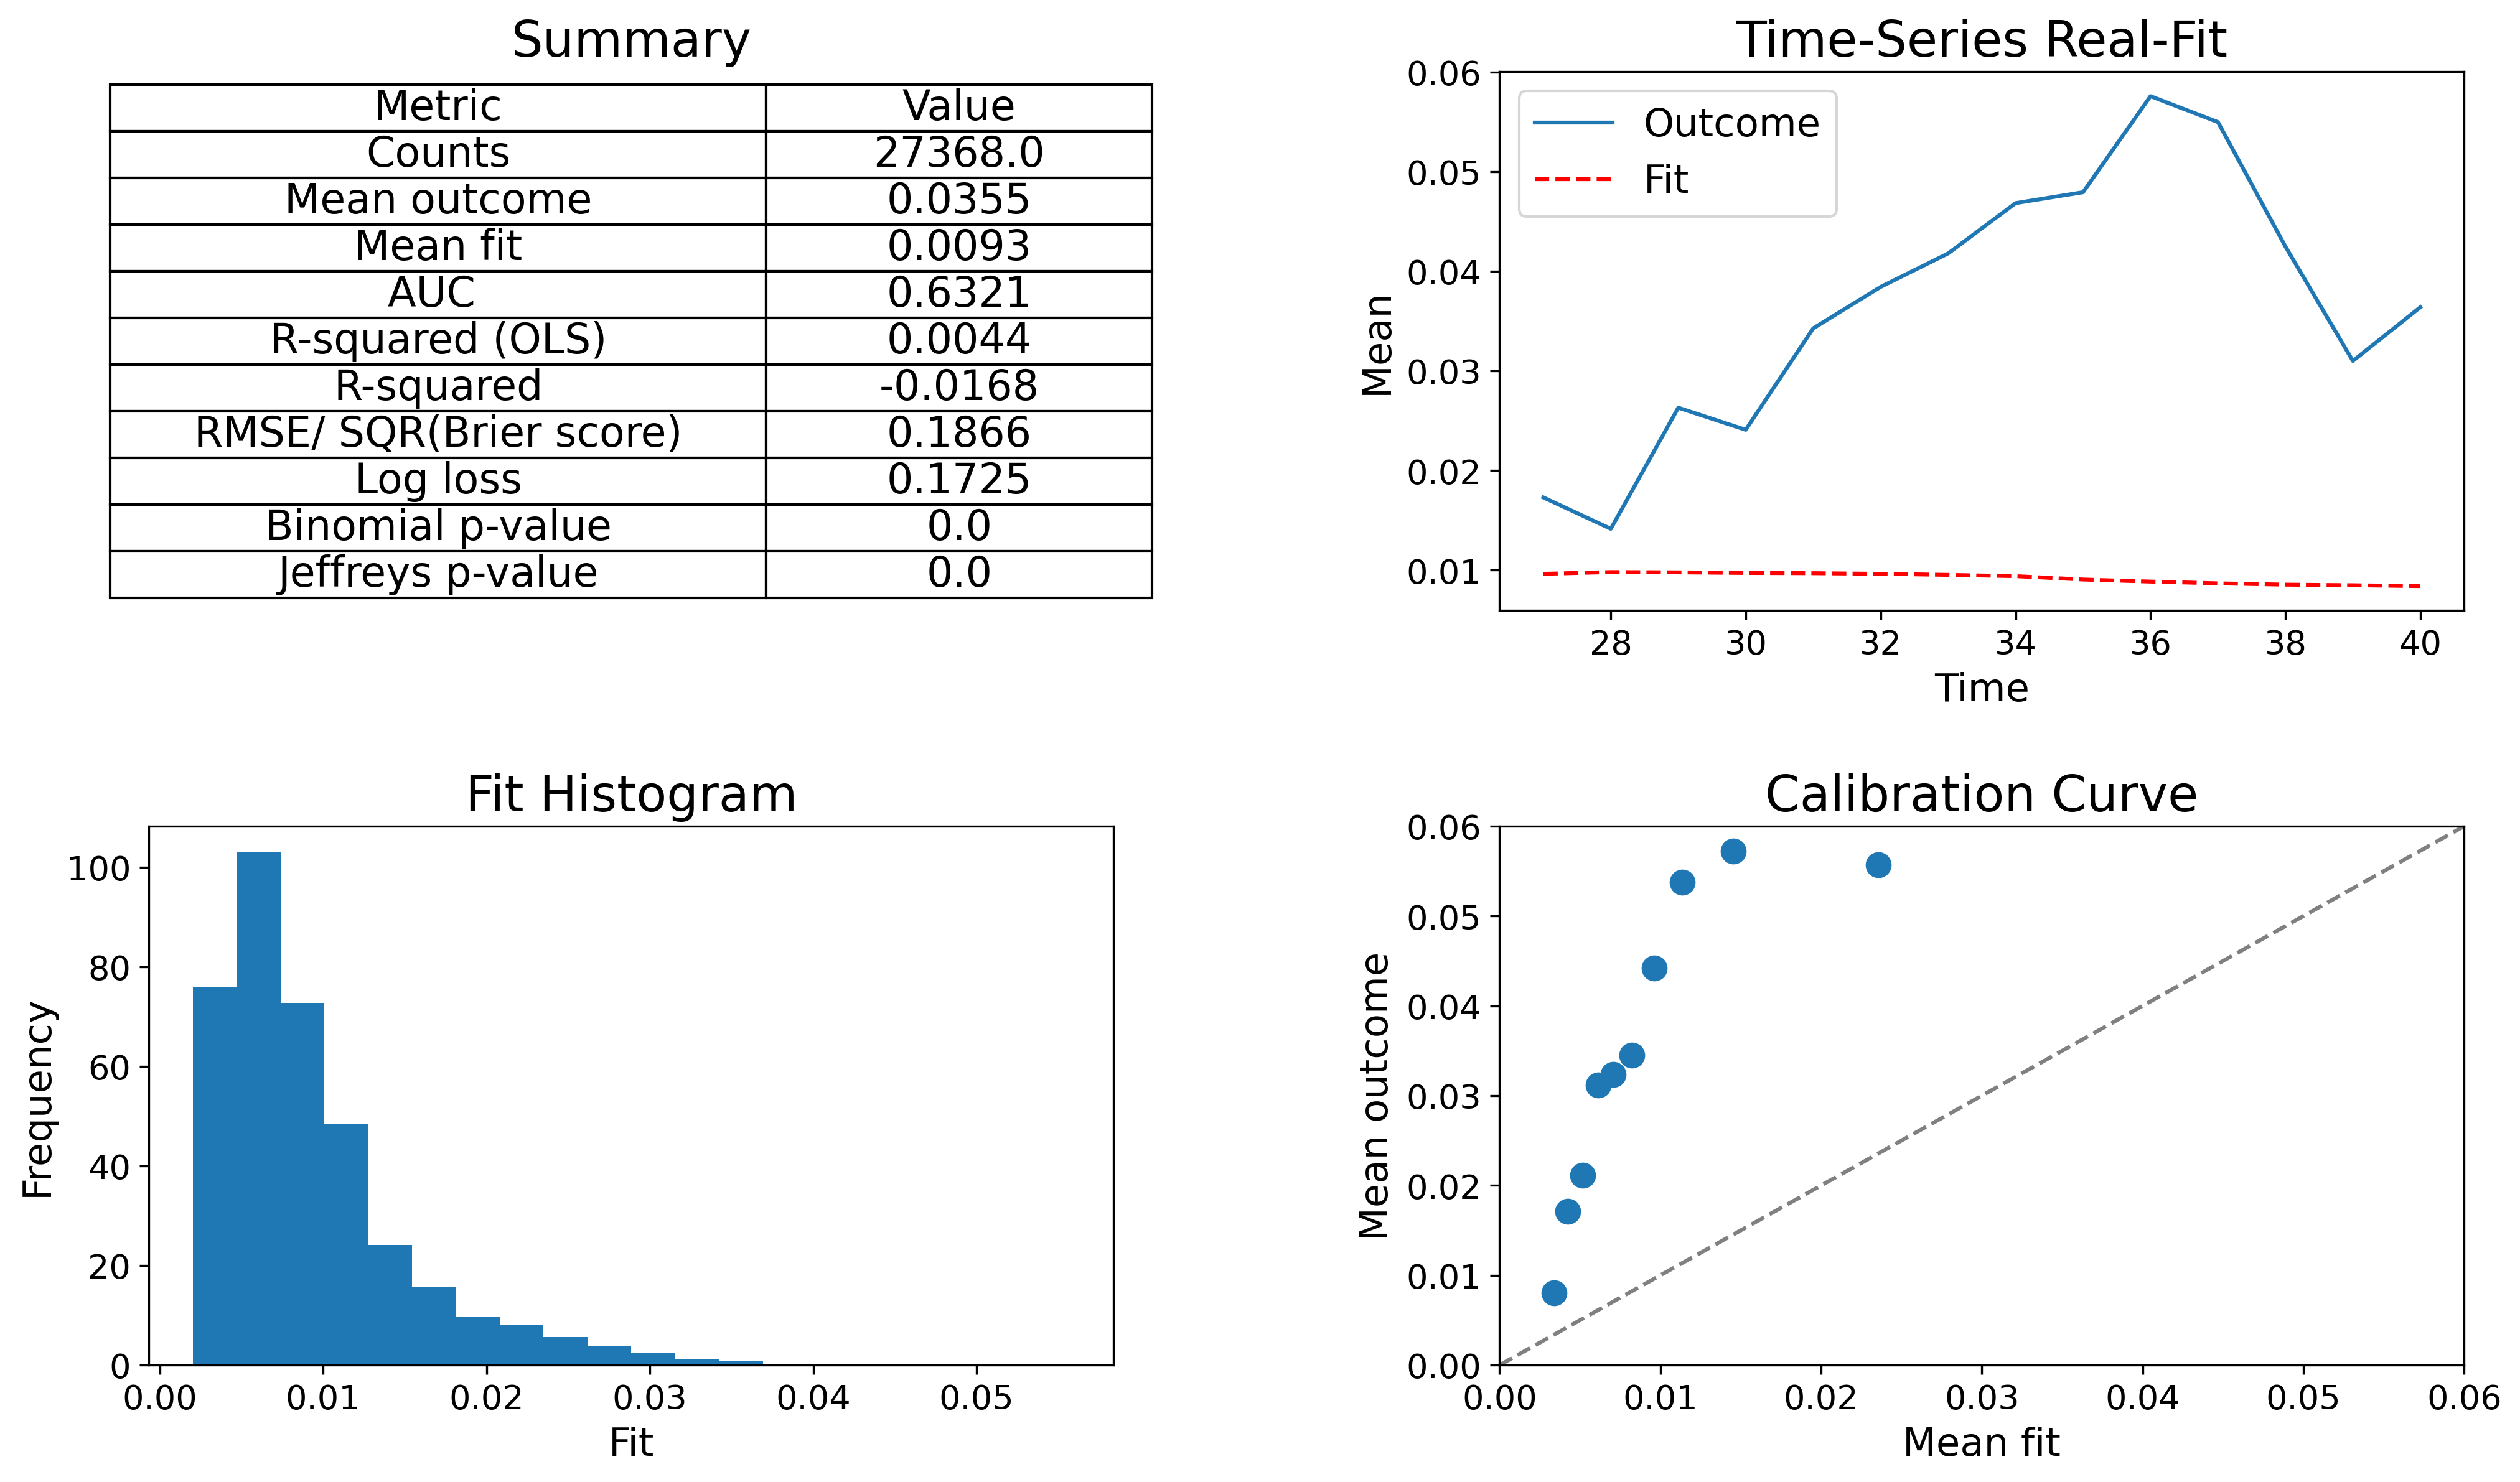

In [21]:
predictions_test = model_lr_best.predict_proba(X_test_scaled)[:,1].T 
validation(predictions_test, y_test, data_test['time'].values)  
AUC_logreg_reg3 = roc_auc_score(y_test, predictions_test).round(4) 
sqrt_brier_logreg_reg3 = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

In [22]:
def data_generation_KNN(n0,n1):  
    global X_train_scaled_knn, X_test_scaled_knn, y_train_knn, y_test_knn  
    np.random.seed(1234)  
    sigma=1 
    mean1 = [1, 1] 
    mean2 = [-1, -1]  
    cov = [[1, 0], [0, 1]]  
    
    X1 = np.random.multivariate_normal(mean1, cov, n0)  
    X2 = np.random.multivariate_normal(mean2, cov, n1) 
    
    y1 = np.ones(n0) 
    y2 = np.ones(n1)-1  
    
    X = np.append(X1,X2, axis =0)  
    y = np.append(y1,y2, axis =0)  
    
    X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X, y, test_size  =0.33, random_state=5)  
    scaler = StandardScaler().fit(X_train_knn) 
    X_train_scaled_knn = scaler.transform(X_train_knn)  
    X_test_scaled_knn = scaler.transform(X_test_knn) 

In [23]:
data_generation_KNN(3,2) 
print(y_train_knn, y_test_knn) 

[1. 1. 0.] [0. 1.]


In [24]:
n_neighbors = 2  
model_knn = KNeighborsClassifier(n_neighbors, weights='uniform') 
model_knn.fit(X_train_scaled_knn, y_train_knn)

KNeighborsClassifier(n_neighbors=2)

In [25]:
predictions_train = model_knn.predict_proba(X_train_scaled_knn)[:,1].T  
predictions_class_train = model_knn.predict(X_train_scaled_knn)  
print(predictions_train, predictions_class_train, y_train_knn) 

predictions_test = model_knn.predict_proba(X_test_scaled_knn)[:,1].T 
predictions_class_test = model_knn.predict(X_test_scaled_knn) 
print(predictions_test, predictions_class_test, y_test_knn) 

[1.  1.  0.5] [1. 1. 0.] [1. 1. 0.]
[0.5 0.5] [0. 0.] [0. 1.]


In [27]:
print('In_Sample:')  
print(classification_report(y_train_knn,predictions_class_train))  
print(confusion_matrix(y_train_knn,predictions_class_train))  
print("ROC AUC (Train):", roc_auc_score(y_train_knn, predictions_train))
print("Accuracy (Train):", accuracy_score(y_train_knn, predictions_class_train)) 
print('Out-of-Sample:')  
print(classification_report(y_test_knn,predictions_class_test)) 
print(confusion_matrix(y_test_knn,predictions_class_test))  
print("ROC AUC (Test):", roc_auc_score(y_test_knn, predictions_test))
print("Accuracy (Test):", accuracy_score(y_test_knn, predictions_class_test))

In_Sample:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

[[1 0]
 [0 2]]
ROC AUC (Train): 1.0
Accuracy (Train): 1.0
Out-of-Sample:
              precision    recall  f1-score   support

         0.0       0.50      1.00      0.67         1
         1.0       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2

[[1 0]
 [1 0]]
ROC AUC (Test): 0.5
Accuracy (Test): 0.5


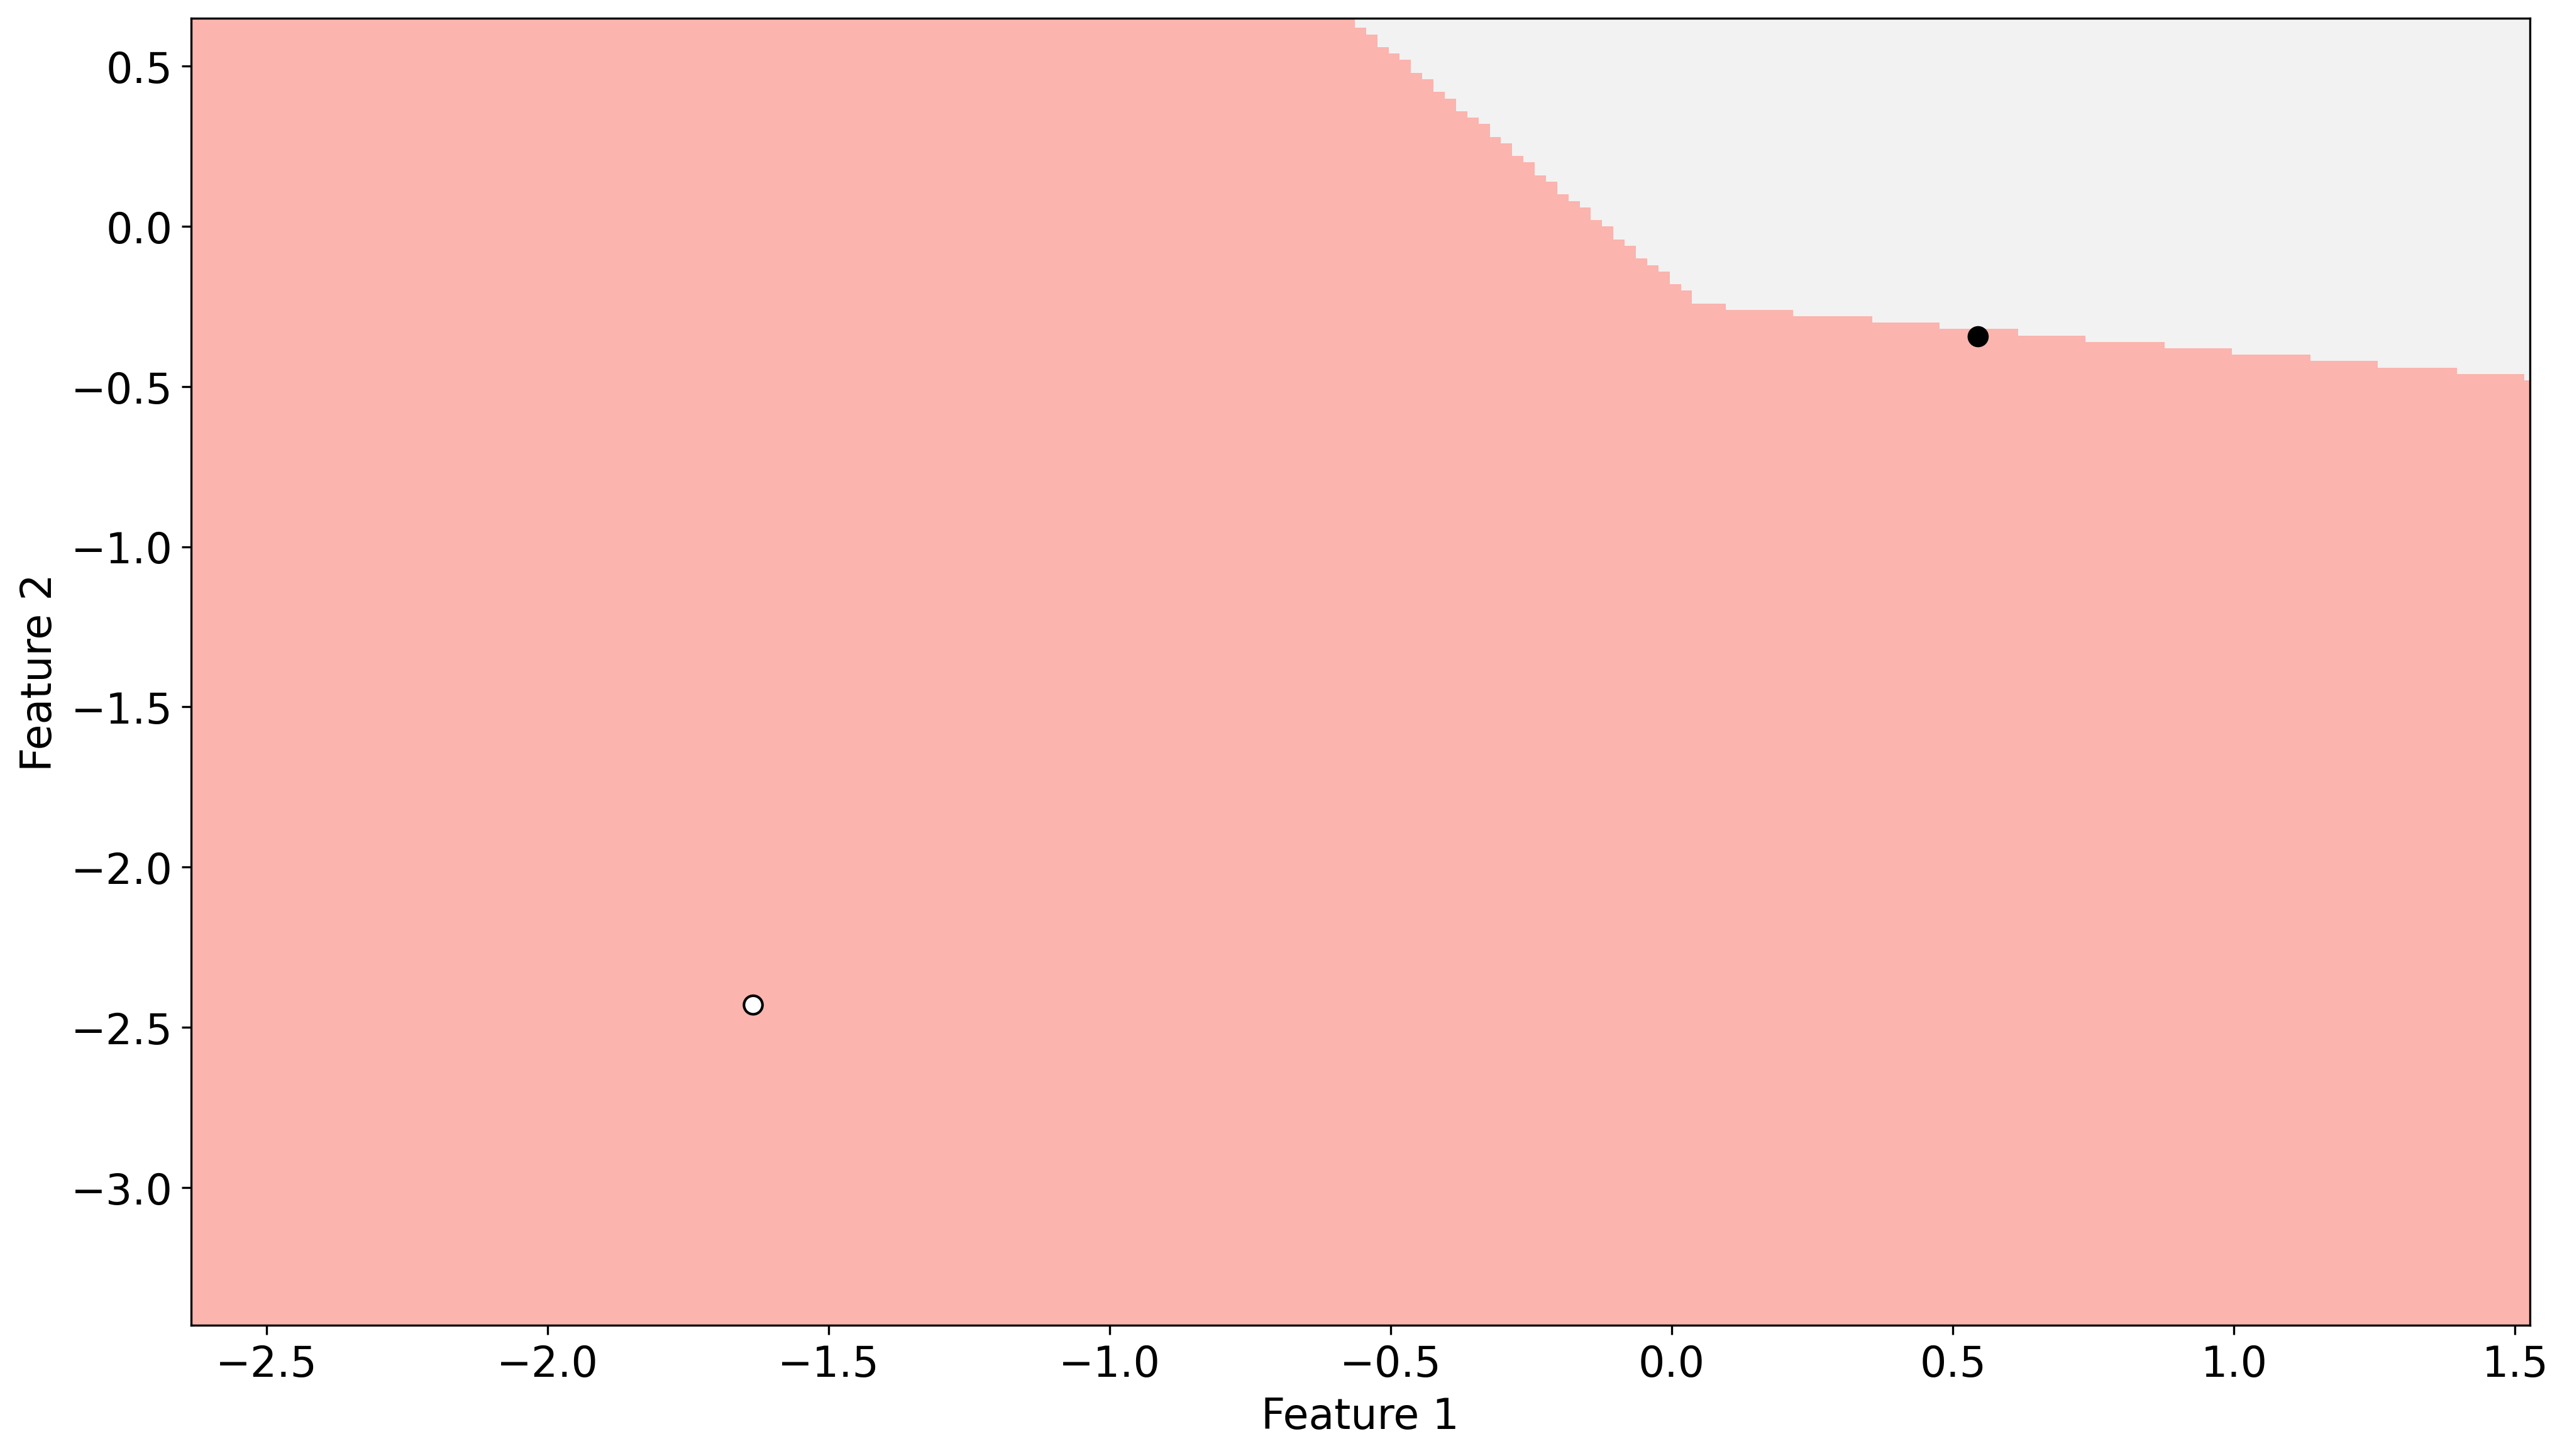

In [28]:
def KNN_dec_bound():
    global X_train_scaled_knn, X_test_scaled_knn, y_train_knn, y_test_knn 
    h = .02  
    x_min, x_max = X_test_scaled_knn[:, 0].min() -1, X_test_scaled_knn[:, 0].max() +1  
    y_min, y_max = X_test_scaled_knn[:, 1].min() -1, X_test_scaled_knn[:, 1].max() +1  
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),  np.arange(y_min, y_max, h))  
    Z = model_knn.predict(np.c_[xx.ravel(), yy.ravel()])  
    
    Z = Z.reshape(xx.shape)
    
    plt.figure()  
    plt.pcolormesh(xx, yy, Z, cmap='Pastel1')  
    plt.scatter(X_test_scaled_knn[:, 0], X_test_scaled_knn[:, 1], c=y_test_knn, cmap='Greys', edgecolor='k', s=50) 
    plt.xlim(xx.min(), xx.max())  
    plt.ylim(yy.min(), yy.max())  
    plt.xlabel('Feature 1')  
    plt.ylabel('Feature 2')  
    plt.show()  
    
KNN_dec_bound() 


In [29]:
data_generation_KNN(200,100)

In [30]:
n_neighbors = 2  
model_knn = KNeighborsClassifier(n_neighbors, weights='uniform')  
model_knn.fit(X_train_scaled_knn, y_train_knn)

KNeighborsClassifier(n_neighbors=2)

In [31]:
predictions_train = model_knn.predict_proba(X_train_scaled_knn)[:,1].T 
predictions_class_train = model_knn.predict(X_train_scaled_knn) 
predictions_test = model_knn.predict_proba(X_test_scaled_knn)[:,1].T 
predictions_class_test = model_knn.predict(X_test_scaled_knn)


In [32]:
print('In_Sample')
print(classification_report(y_train_knn, predictions_class_train))  
print(confusion_matrix(y_train_knn, predictions_class_train))
print("ROC AUC (Train):", roc_auc_score(y_train_knn, predictions_train))  
print("Accuracy (Train):", accuracy_score(y_train_knn, predictions_class_train))  
print('Out-of-Sample') 
print(classification_report(y_test_knn, predictions_class_test))  
print(confusion_matrix(y_test_knn, predictions_class_test))  
print("ROC AUC (Test):", roc_auc_score(y_test_knn, predictions_test))  
print("Accuracy (Test):", accuracy_score(y_test_knn, predictions_class_test)) 


In_Sample
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95        63
         1.0       1.00      0.95      0.97       138

    accuracy                           0.97       201
   macro avg       0.95      0.97      0.96       201
weighted avg       0.97      0.97      0.97       201

[[ 63   0]
 [  7 131]]
ROC AUC (Train): 0.9971819645732689
Accuracy (Train): 0.9651741293532339
Out-of-Sample
              precision    recall  f1-score   support

         0.0       0.79      0.92      0.85        37
         1.0       0.95      0.85      0.90        62

    accuracy                           0.88        99
   macro avg       0.87      0.89      0.87        99
weighted avg       0.89      0.88      0.88        99

[[34  3]
 [ 9 53]]
ROC AUC (Test): 0.9367916303400174
Accuracy (Test): 0.8787878787878788


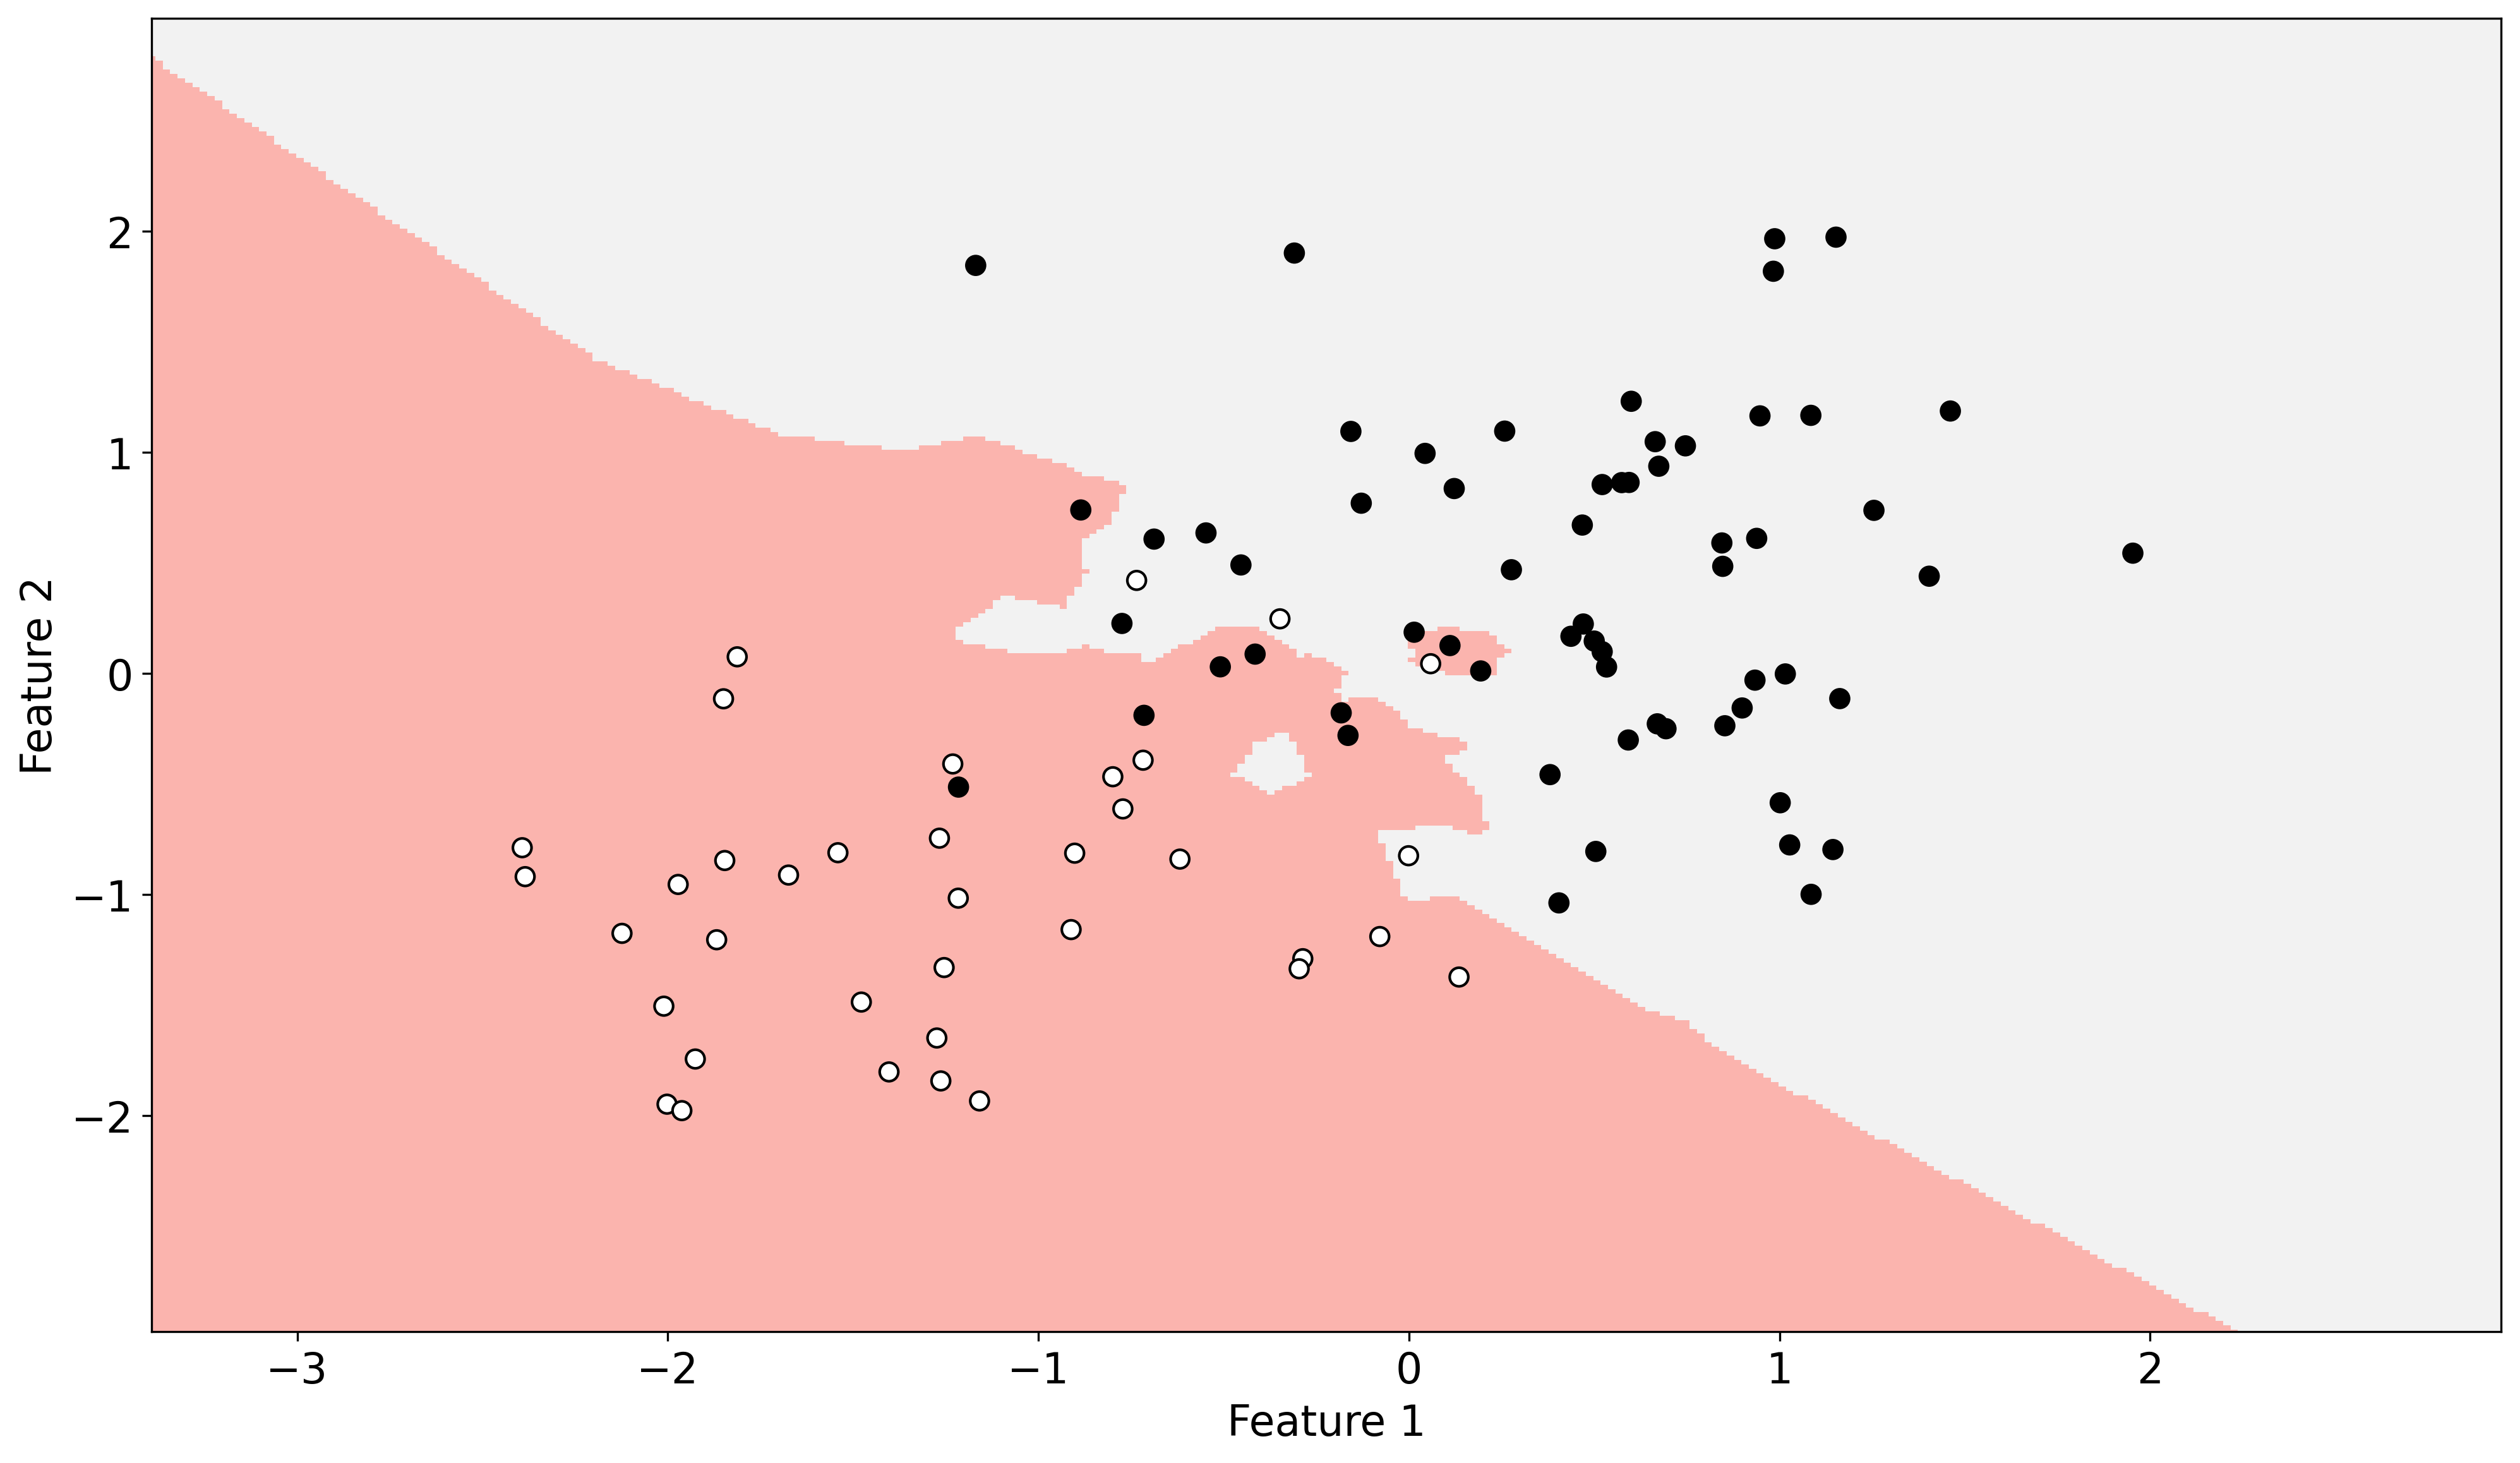

In [33]:
KNN_dec_bound()

In [34]:
n,acc_train,acc_test = [],[],[] 

for i in range(1,100):  
    model_knn = KNeighborsClassifier(i, weights='uniform')  
    model_knn.fit(X_train_scaled_knn, y_train_knn)  
    
    predictions_train = model_knn.predict_proba(X_train_scaled_knn)[:,1].T 
    predictions_class_train = model_knn.predict(X_train_scaled_knn)  
    predictions_test = model_knn.predict_proba(X_test_scaled_knn)[:,1].T  
    predictions_class_test = model_knn.predict(X_test_scaled_knn) 
    n.append(i) 
    acc_train.append(accuracy_score(y_train_knn, predictions_class_train))  
    acc_test.append(accuracy_score(y_test_knn, predictions_class_test))

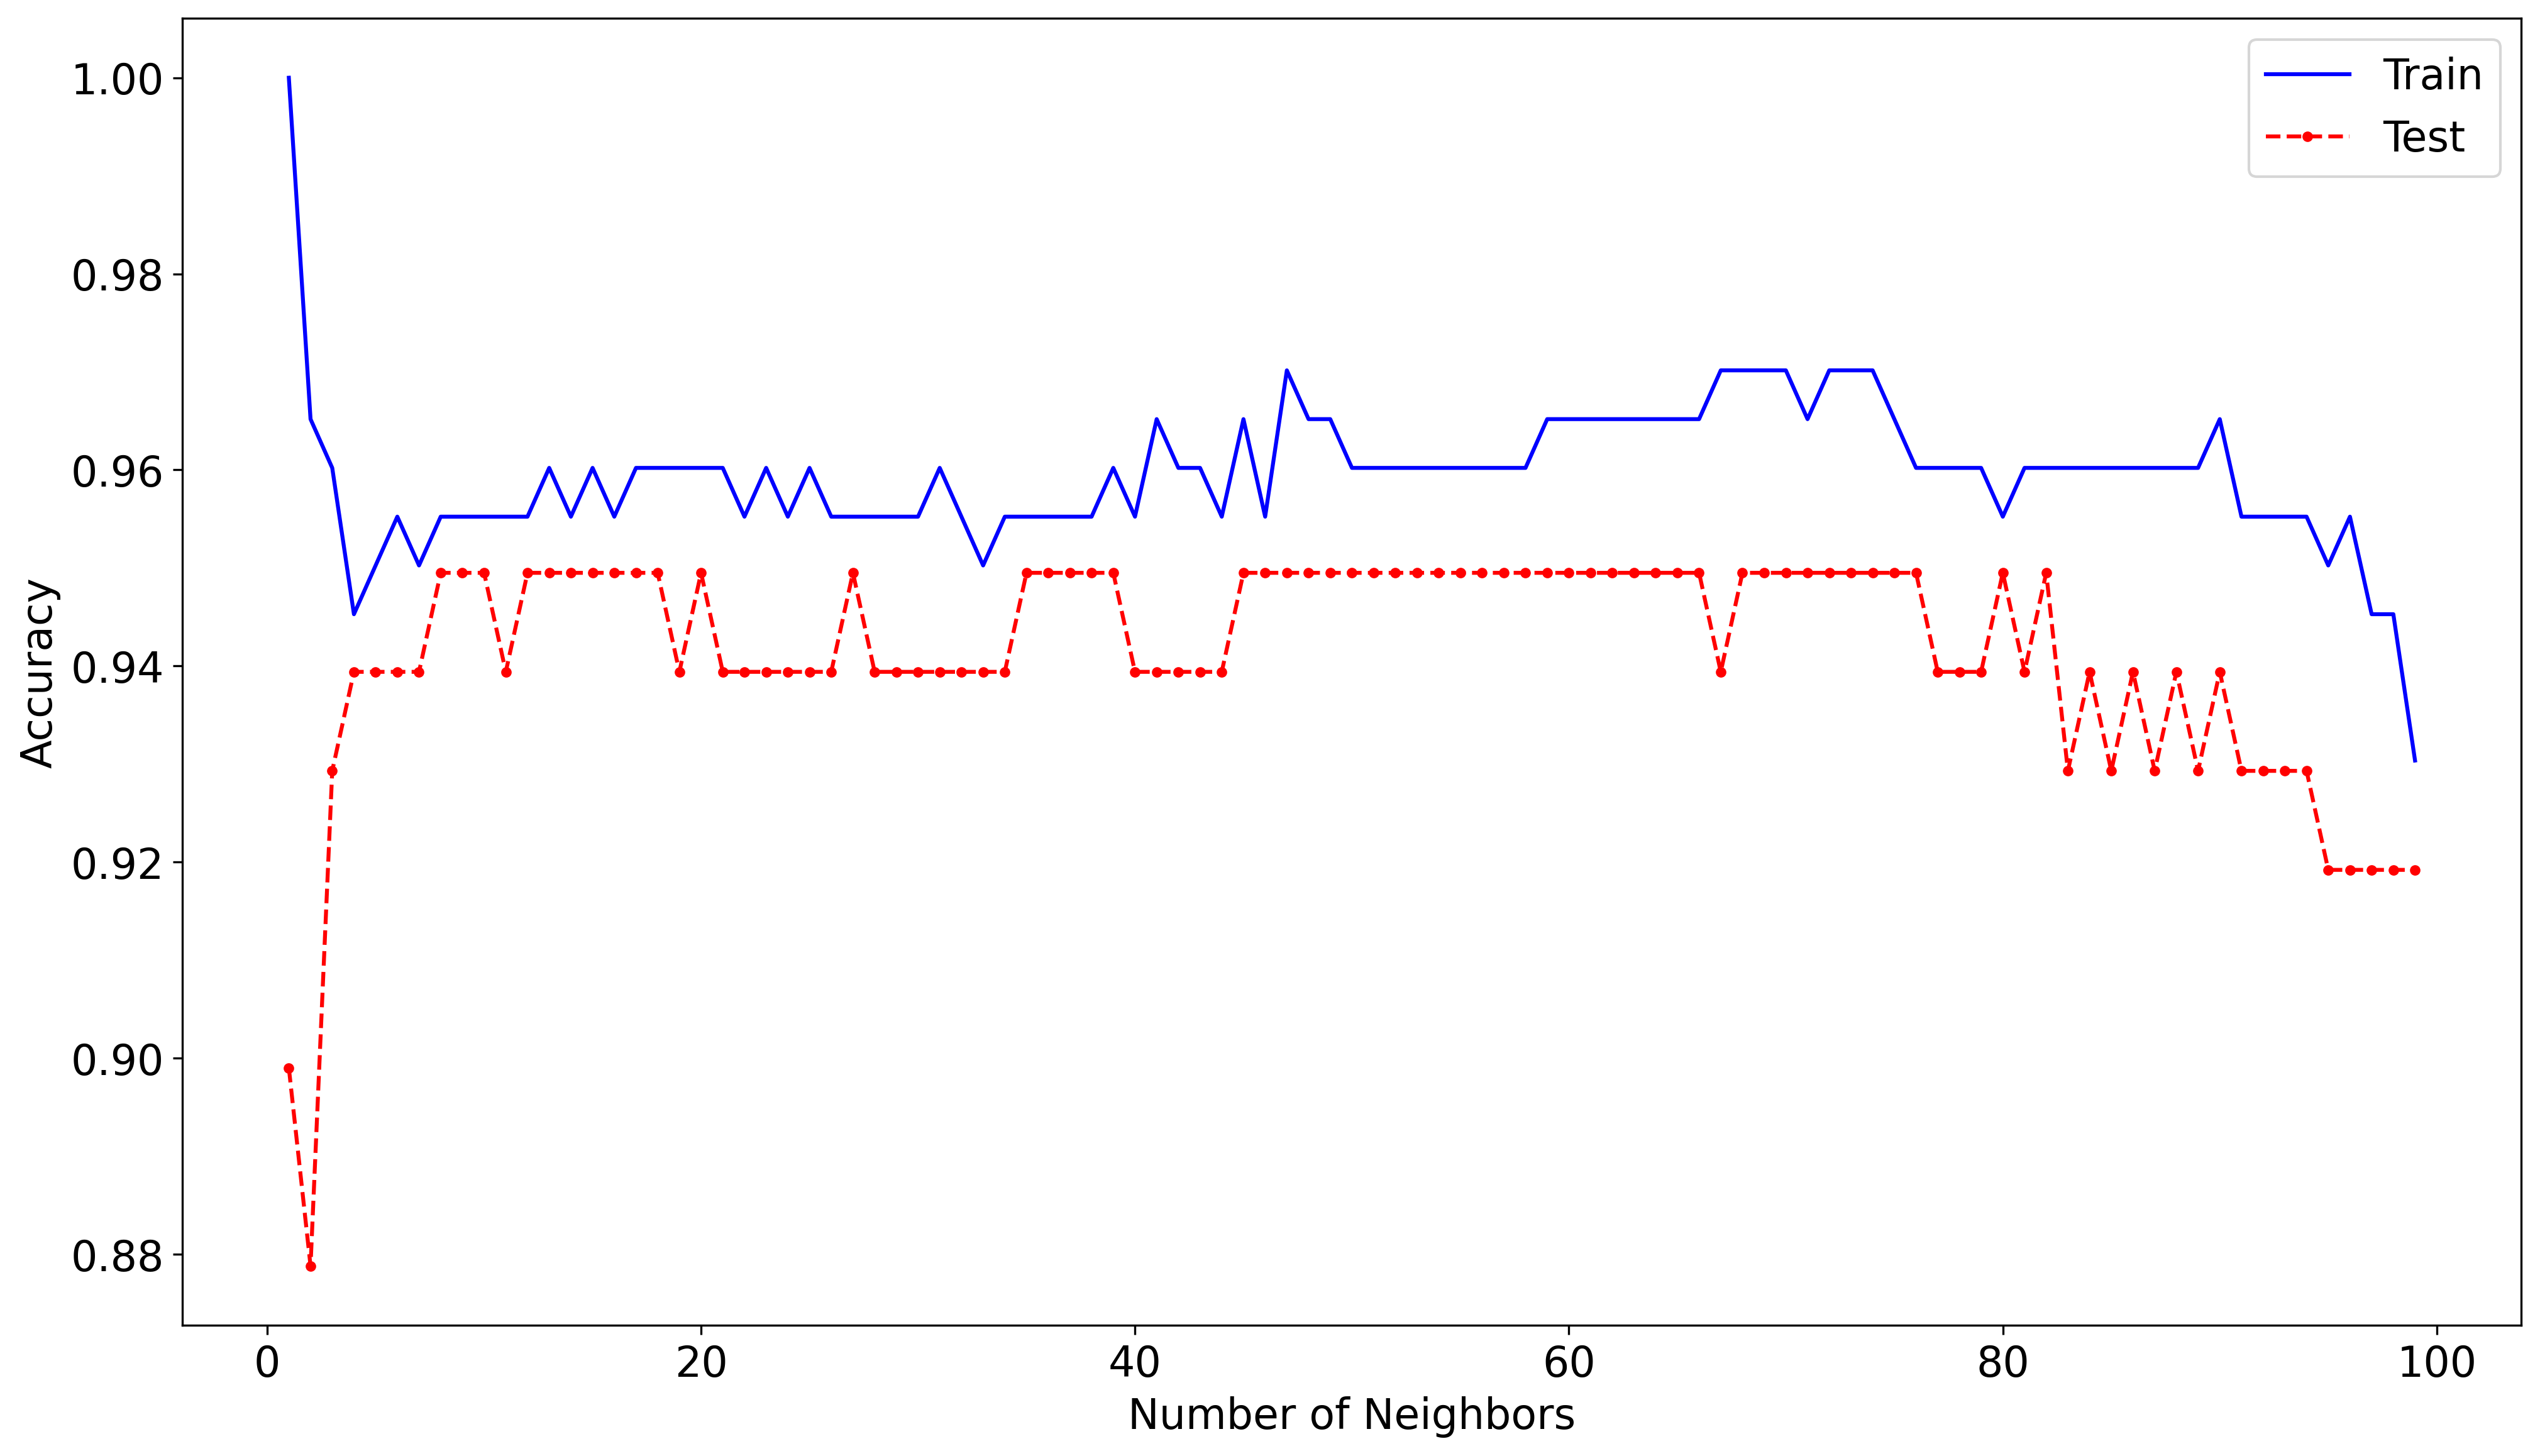

In [35]:
plt.plot(n, acc_train, marker='', linestyle='-',color='blue', label='Train')  
plt.plot(n, acc_test, marker='.', linestyle='--', color='red', label='Test')  
plt.ylabel('Accuracy')  
plt.xlabel('Number of Neighbors')
plt.legend(loc="upper right")  
plt.show() 

In [36]:
n_neighbors = 100  
model_knn = KNeighborsClassifier(n_neighbors, weights='uniform')  
model_knn.fit(X_train_scaled, y_train)  

KNeighborsClassifier(n_neighbors=100)

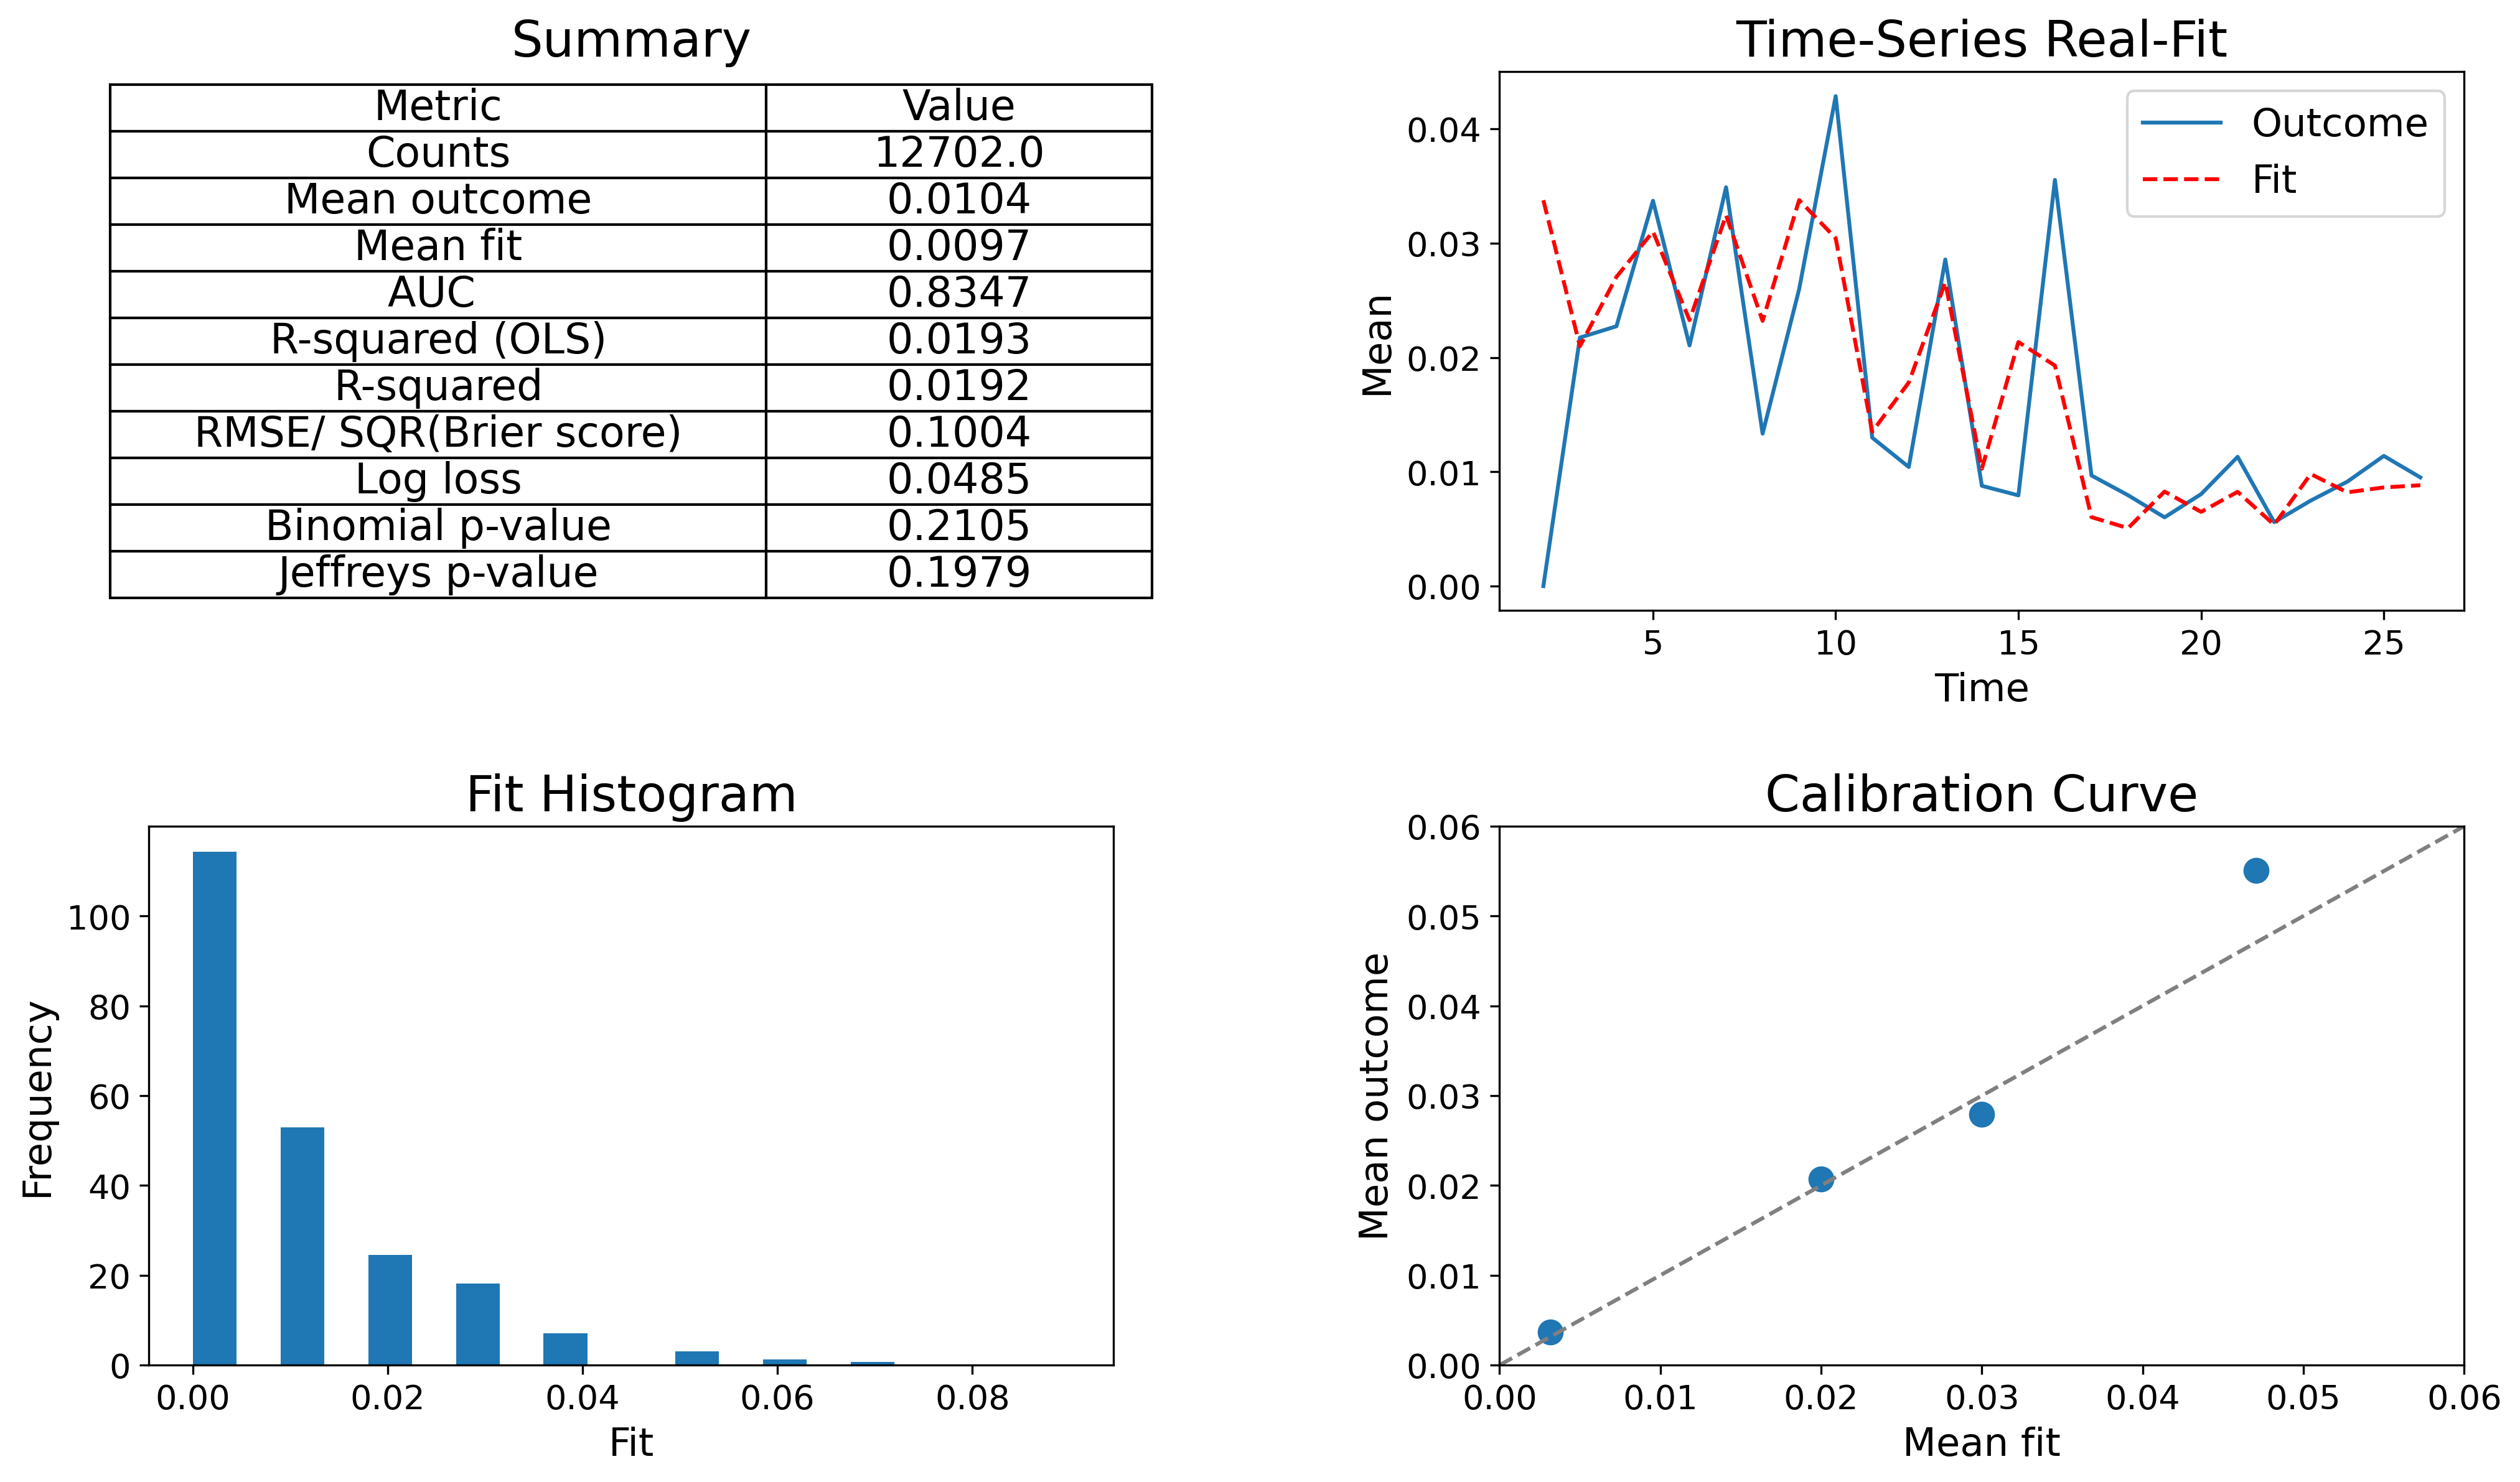

In [37]:
predictions_train = model_knn.predict_proba(X_train_scaled)[:,1].T 
validation(predictions_train, y_train, data_train['time'].values) 

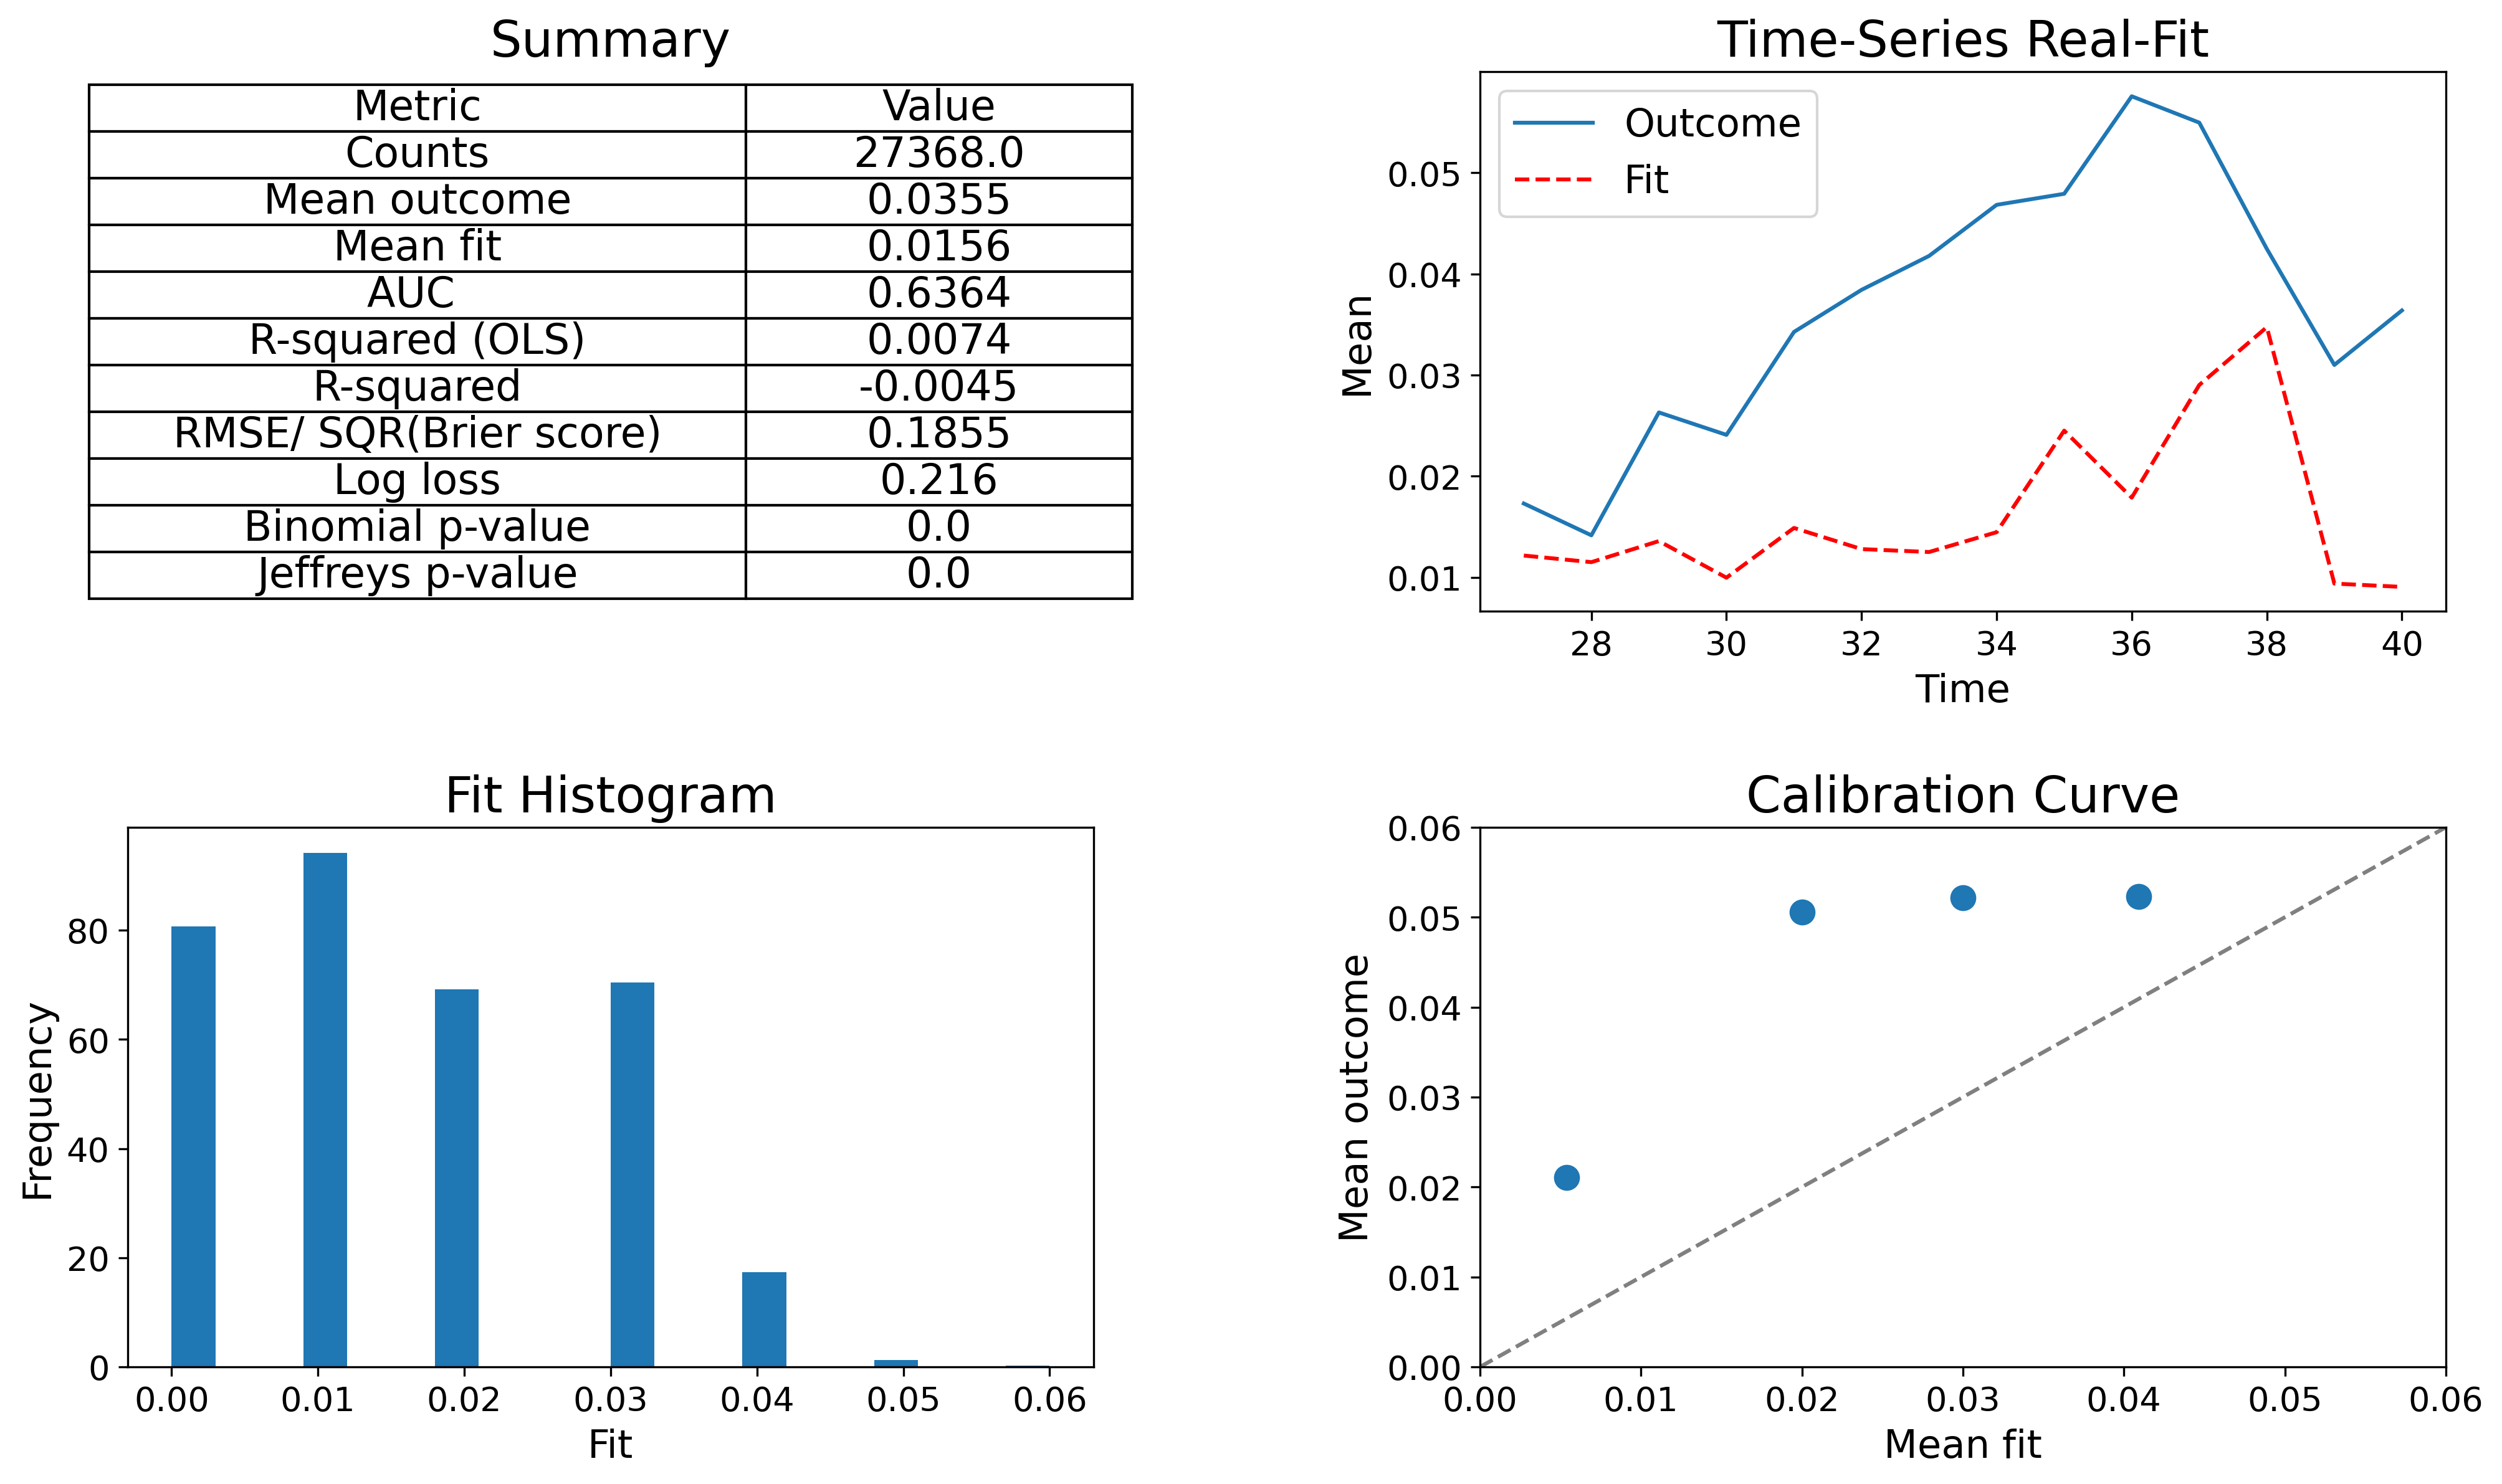

In [38]:
predictions_test = model_knn.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_knn = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_knn = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4)  

In [40]:
params_knn = {'n_neighbors': 2**(np.arange(0,13,1))} 
print(params_knn) 
model_knn_gs = KNeighborsClassifier()  
gs_knn = GridSearchCV(model_knn_gs, params_knn, verbose=1, n_jobs=2, cv=5, scoring='roc_auc')
gs_knn.fit(X_train_scaled, y_train)  
print(gs_knn.best_params_)  

filename= 'Mortgage_knn_GridSearch.sav'  
pickle.dump(gs_knn, open(filename, 'wb'))

{'n_neighbors': array([   1,    2,    4,    8,   16,   32,   64,  128,  256,  512, 1024,
       2048, 4096], dtype=int32)}
Fitting 5 folds for each of 13 candidates, totalling 65 fits
{'n_neighbors': 4096}


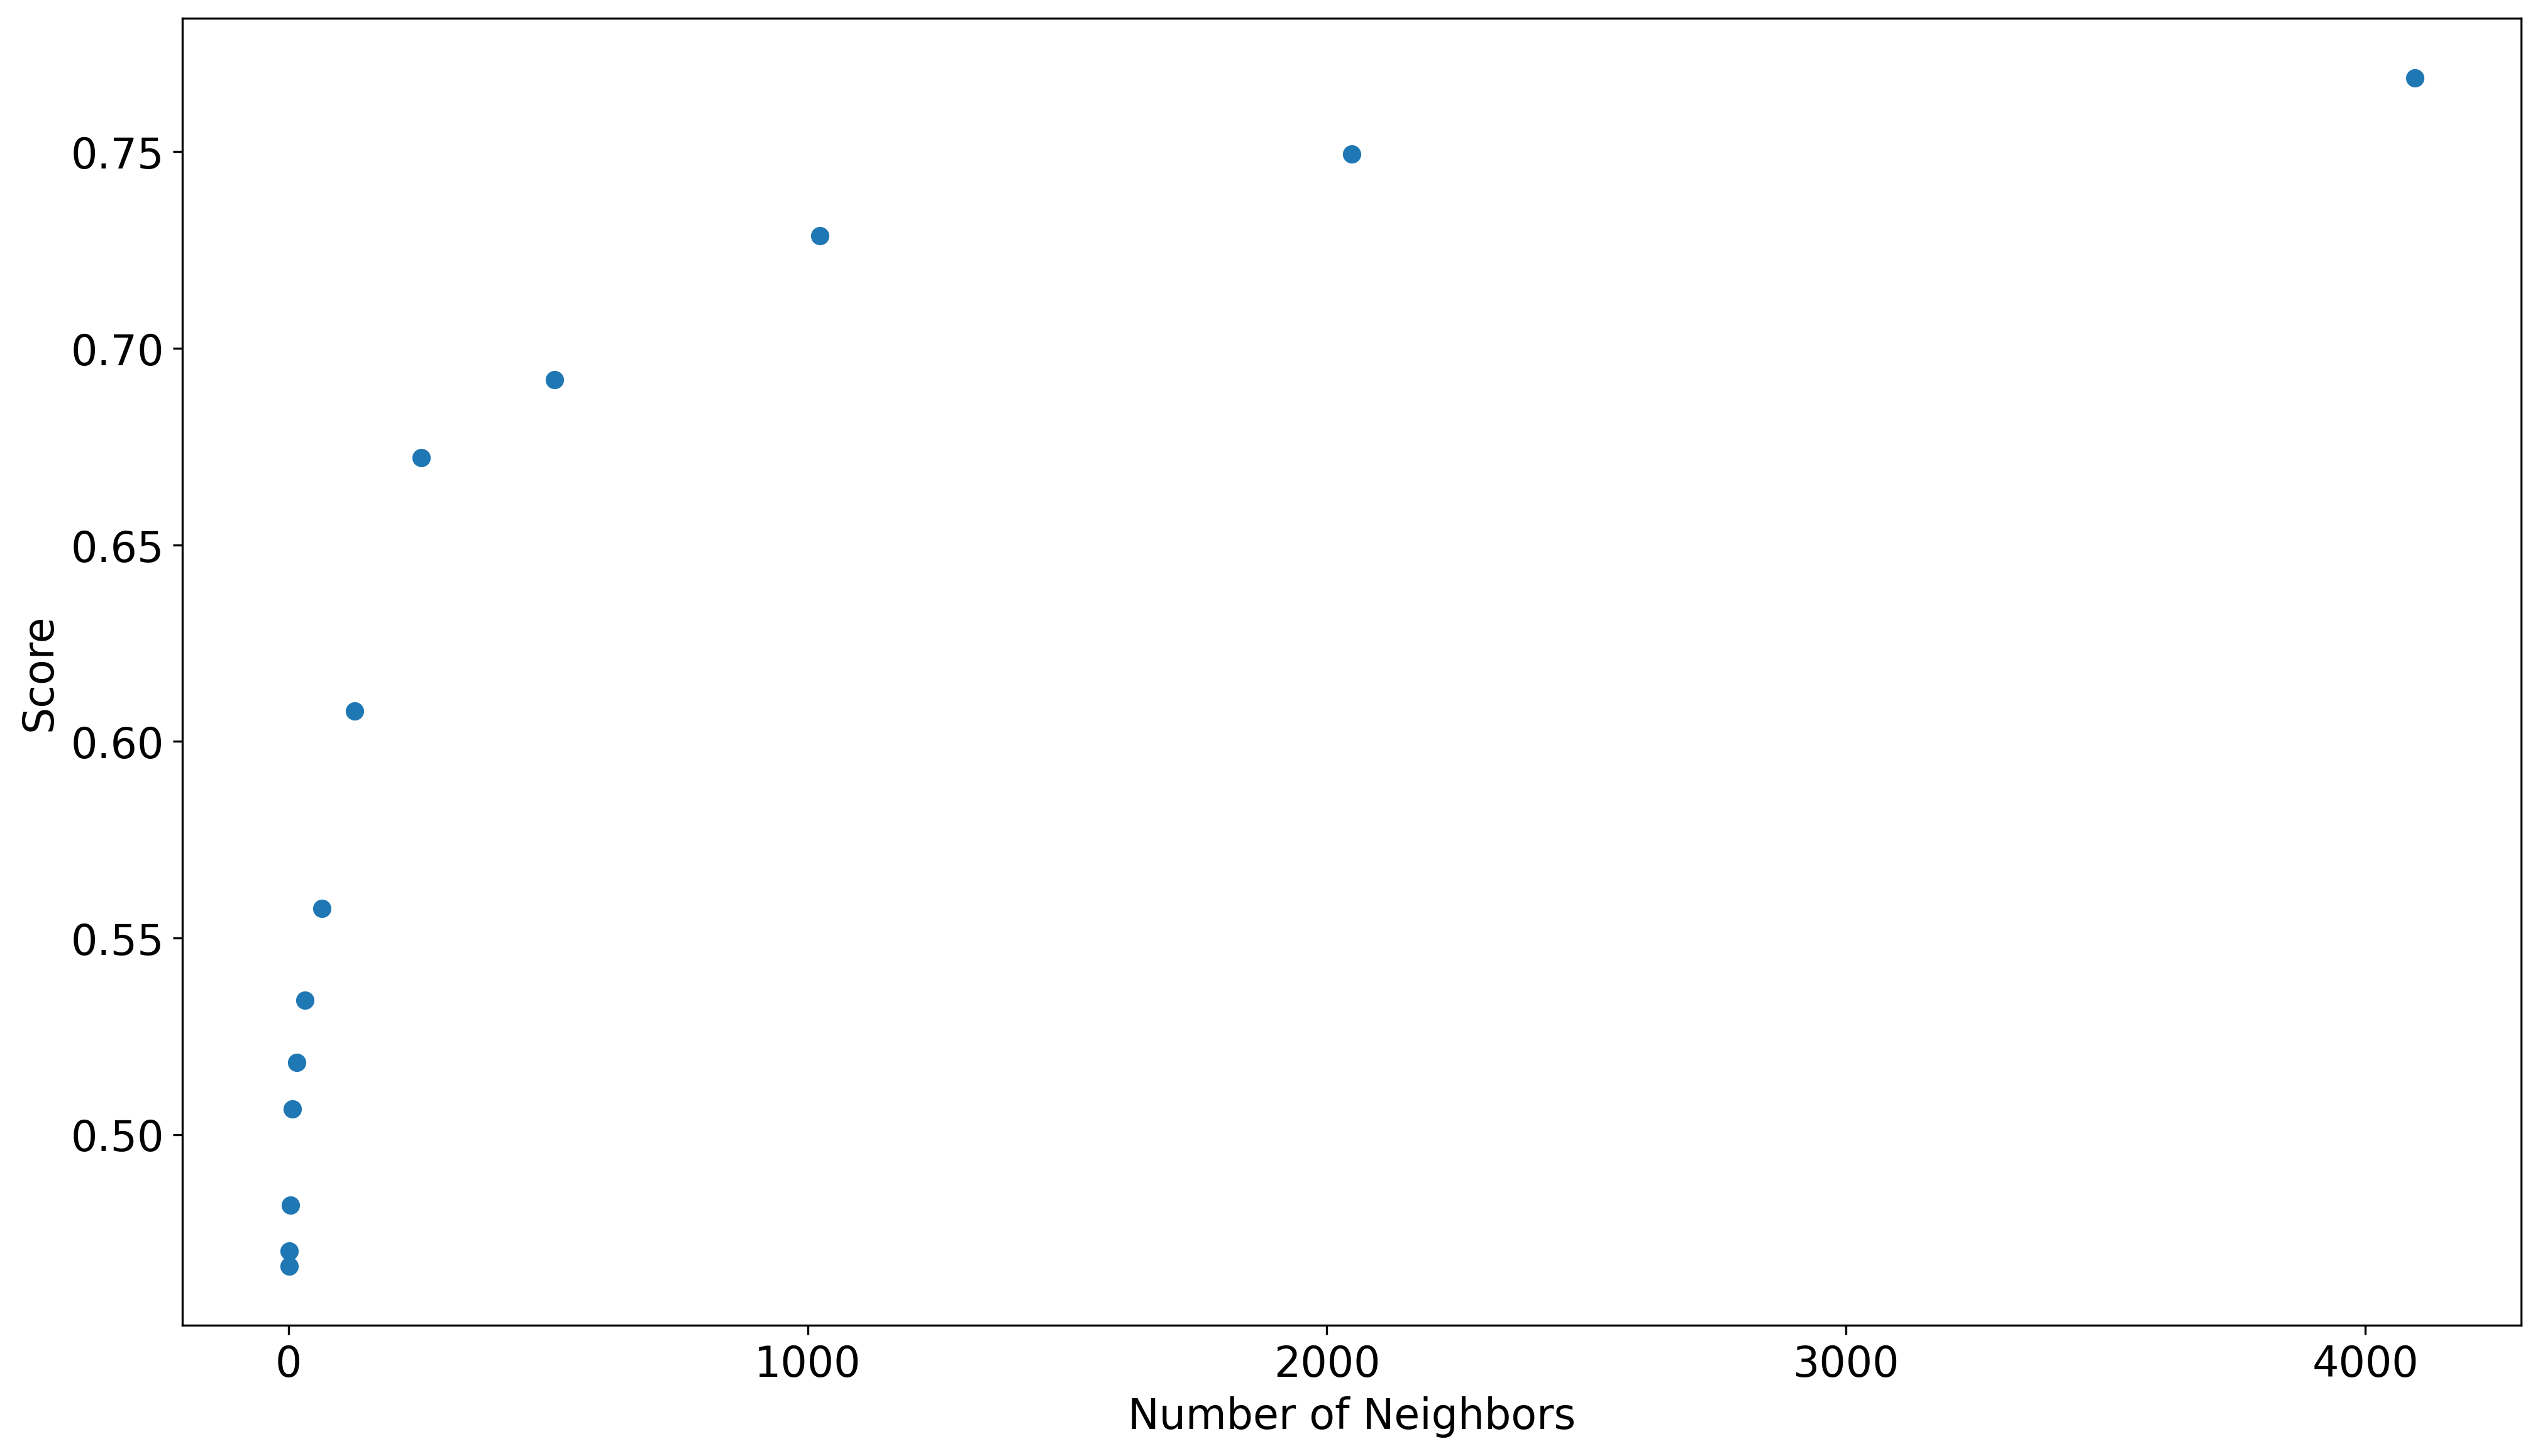

In [41]:
filename = 'Mortgage_knn_GridSearch.sav'  
gs_knn = pickle.load(open(filename, 'rb')) 
plt.plot(pd.DataFrame(gs_knn.cv_results_.get('params')).iloc[:,0], gs_knn.cv_results_['mean_test_score'], marker='o', linestyle='') 
plt.ylabel('Score')  
plt.xlabel('Number of Neighbors')  
plt.show() 


In [42]:
model_knn_best = KNeighborsClassifier(n_neighbors = gs_knn.best_params_.get('n_neighbors'))
model_knn_best.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=4096)

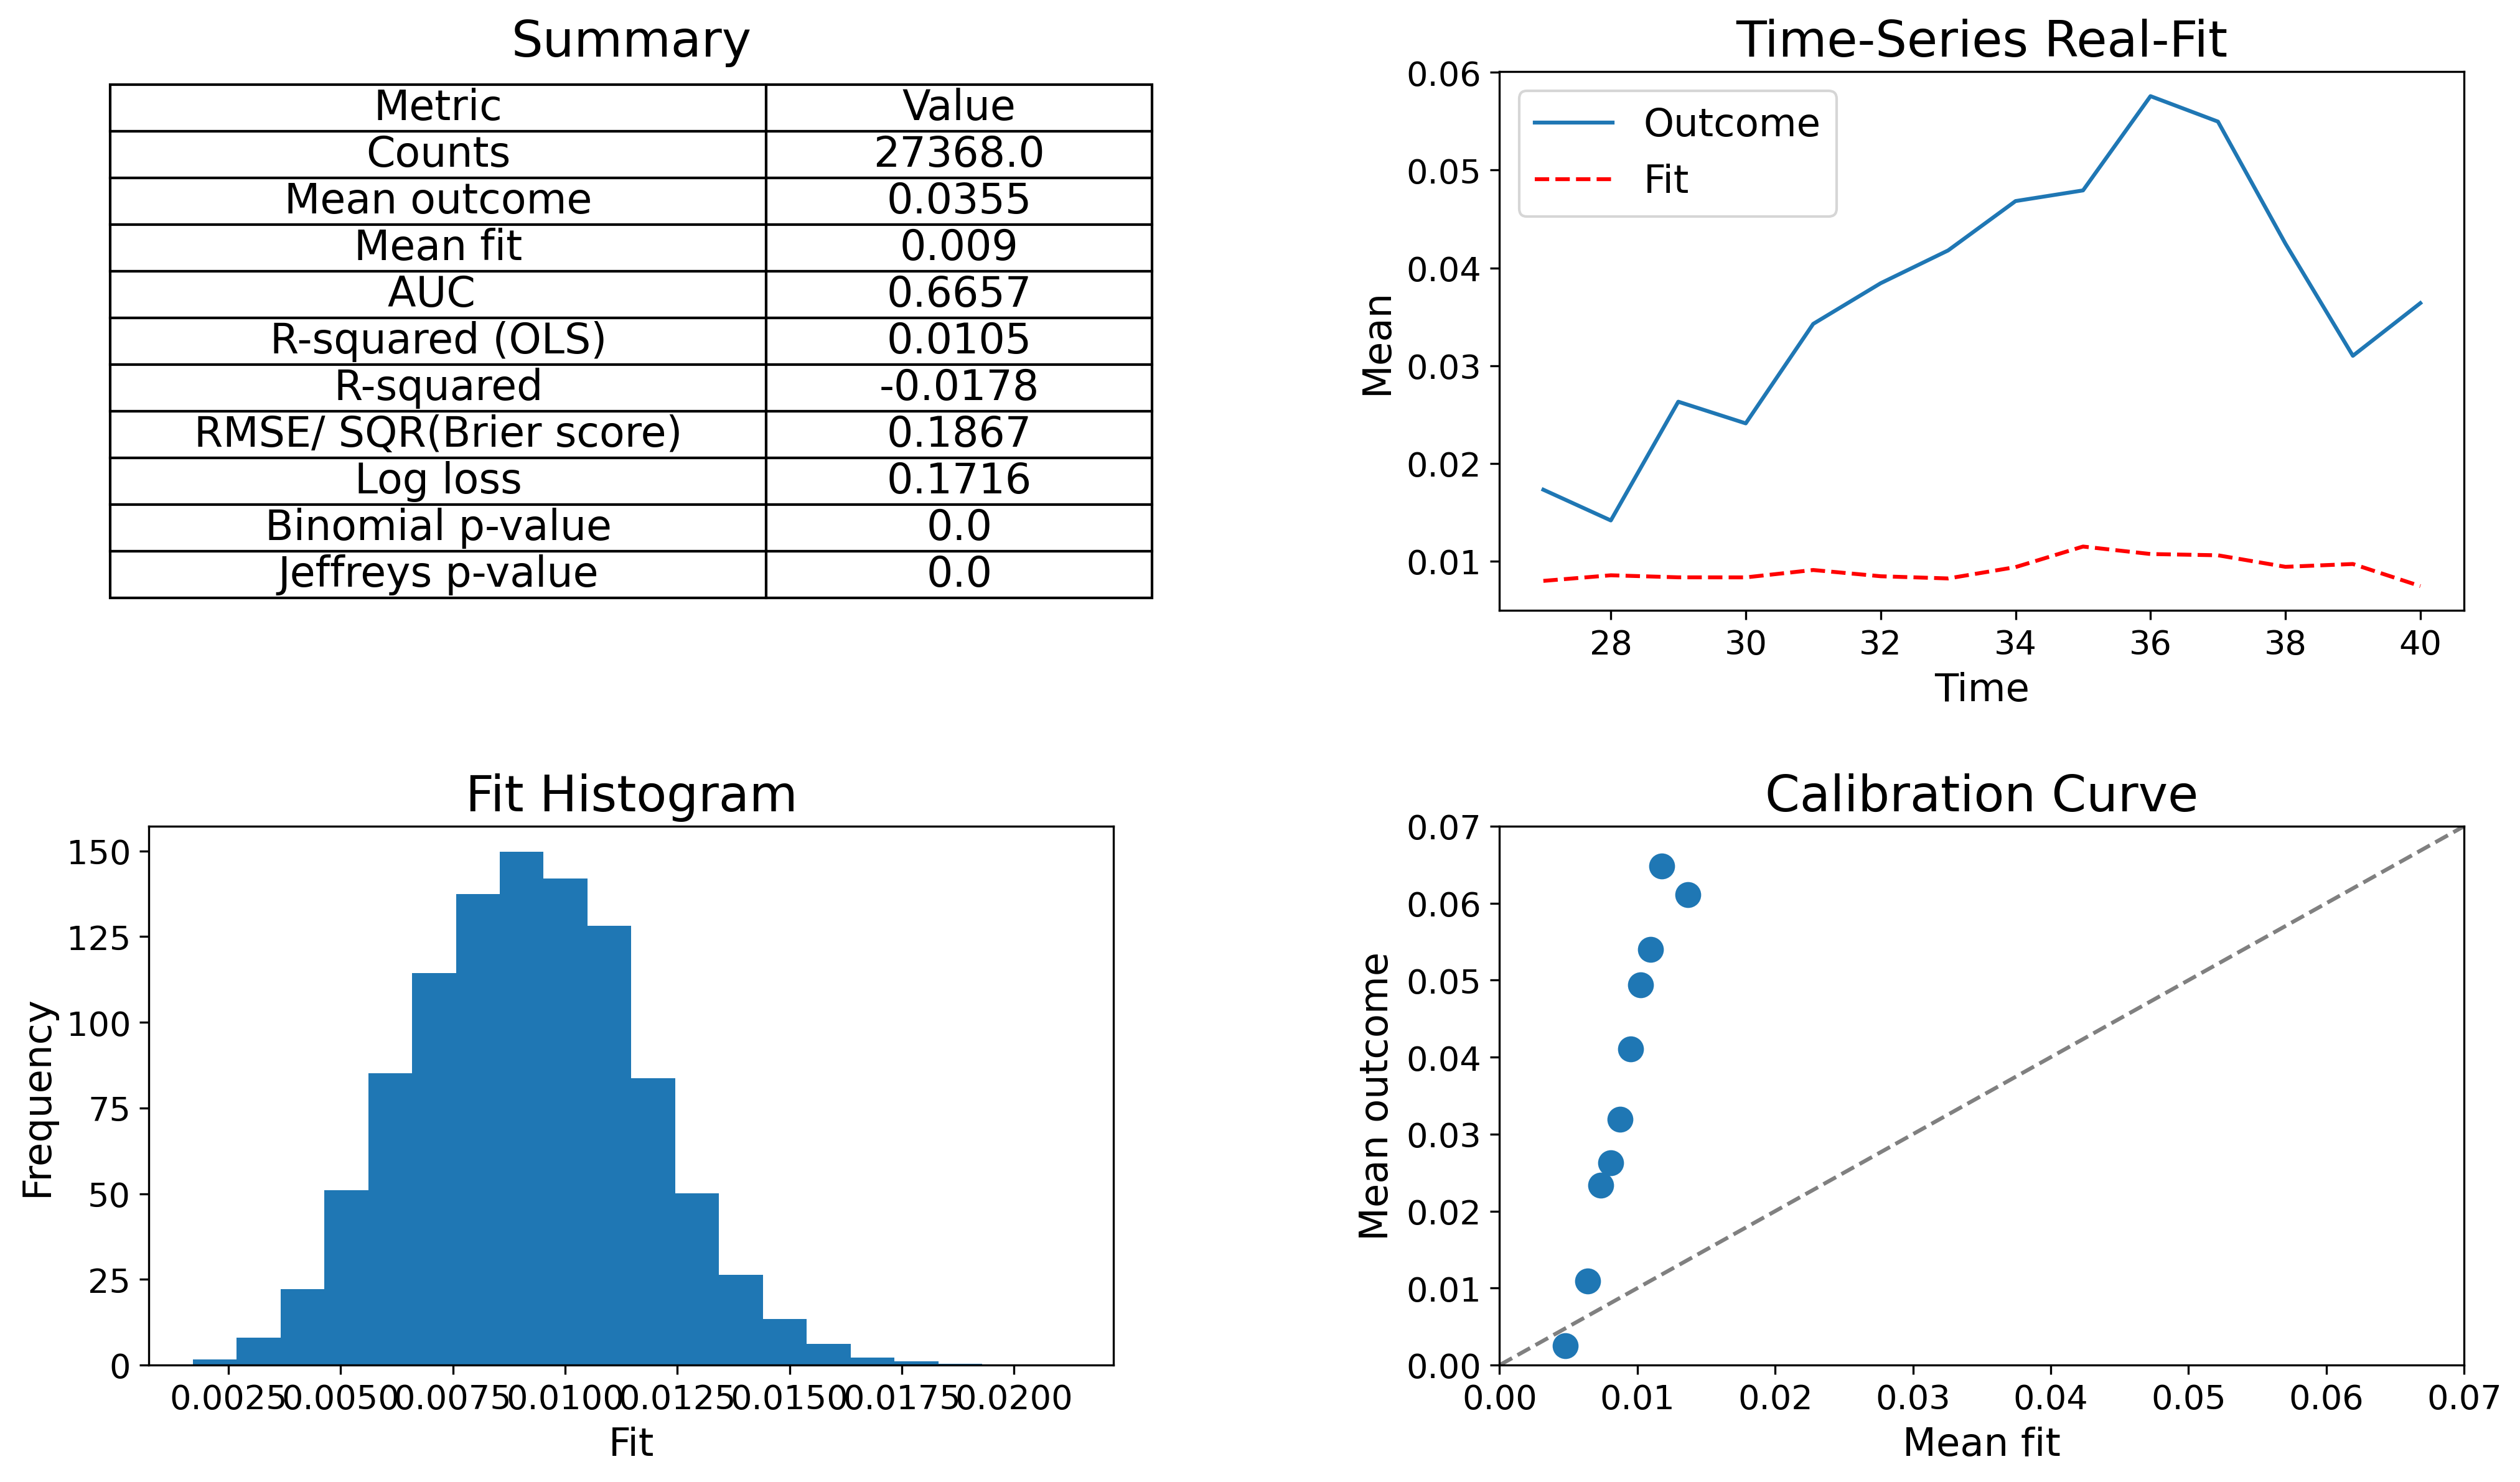

In [43]:
predictions_test = model_knn_best.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values) 
AUC_knn_best = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_knn_best = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

In [45]:
model_nb = GaussianNB() 
model_nb.fit(X_train_scaled, y_train) 

GaussianNB()

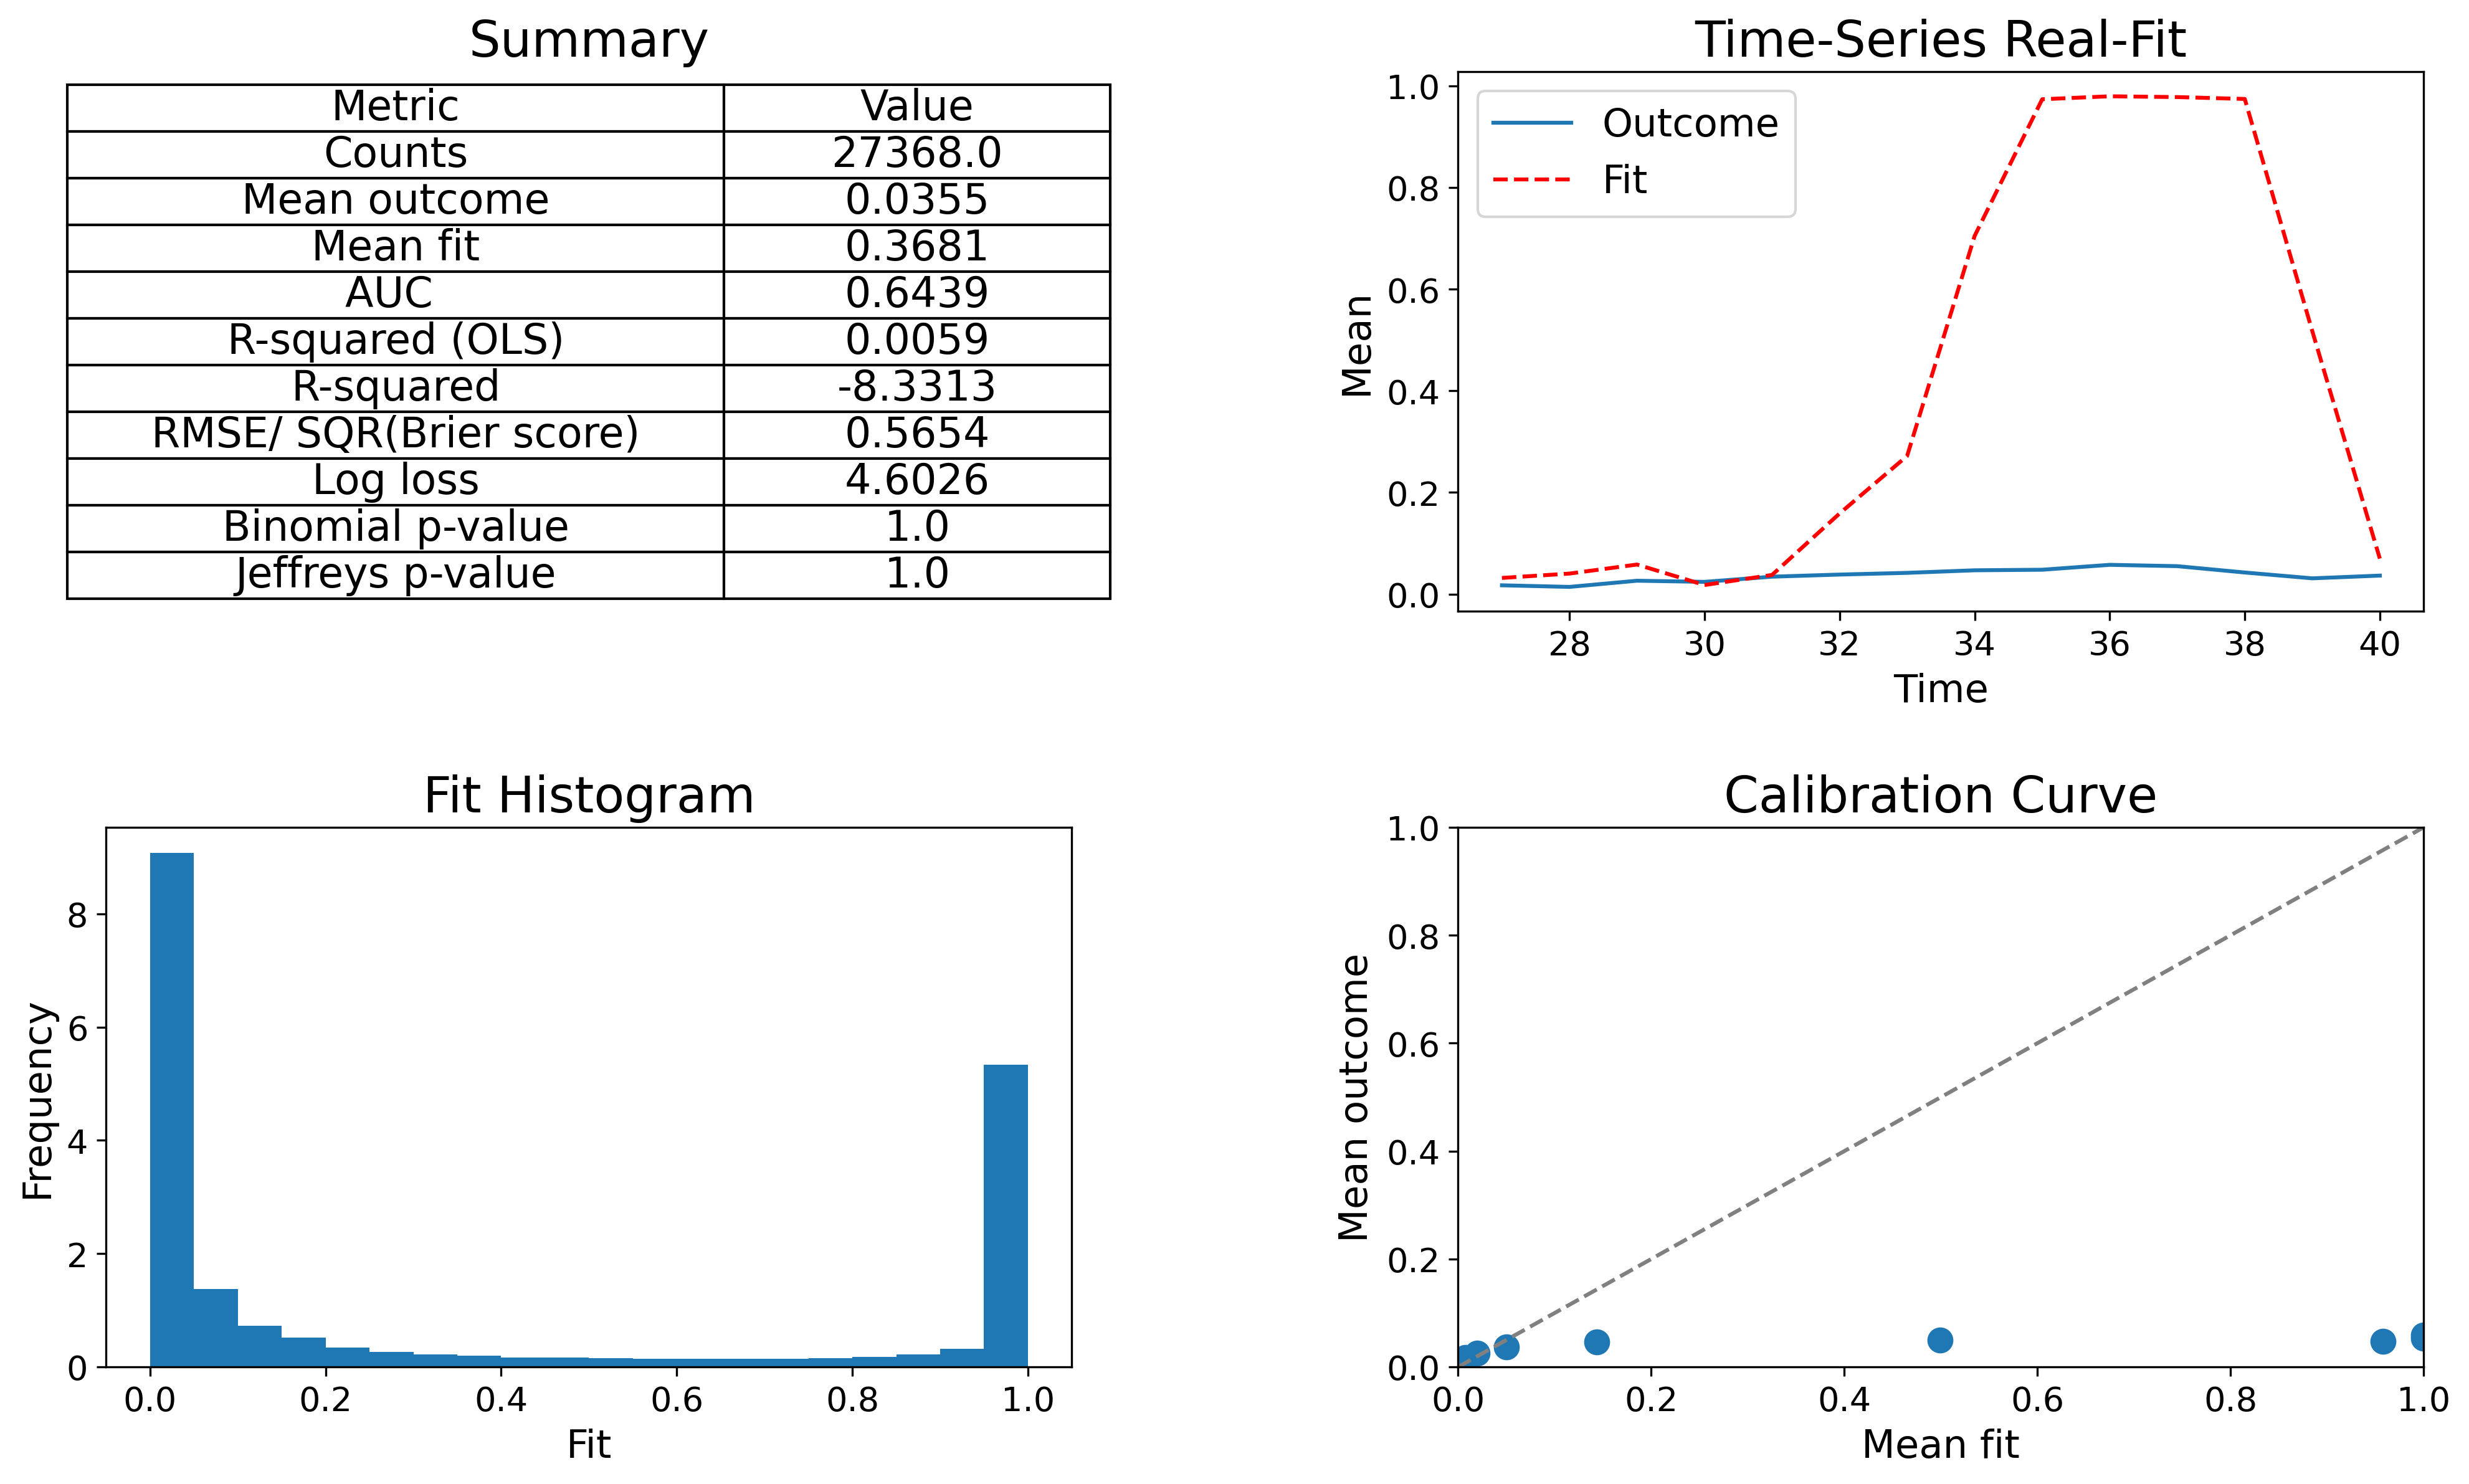

In [46]:
predictions_test = model_nb.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_nb = roc_auc_score(y_test, predictions_test).round(4) 
sqrt_brier_nb = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4)

In [47]:
model_dt = DecisionTreeClassifier(random_state=12345, max_depth=5, max_features=5)  
model_dt.fit(X_train_scaled, y_train)  
print(model_dt.feature_importances_.round(4)) 

[3.432e-01 3.363e-01 5.900e-02 1.908e-01 1.700e-02 0.000e+00 2.370e-02
 0.000e+00 2.000e-04 2.960e-02 0.000e+00]


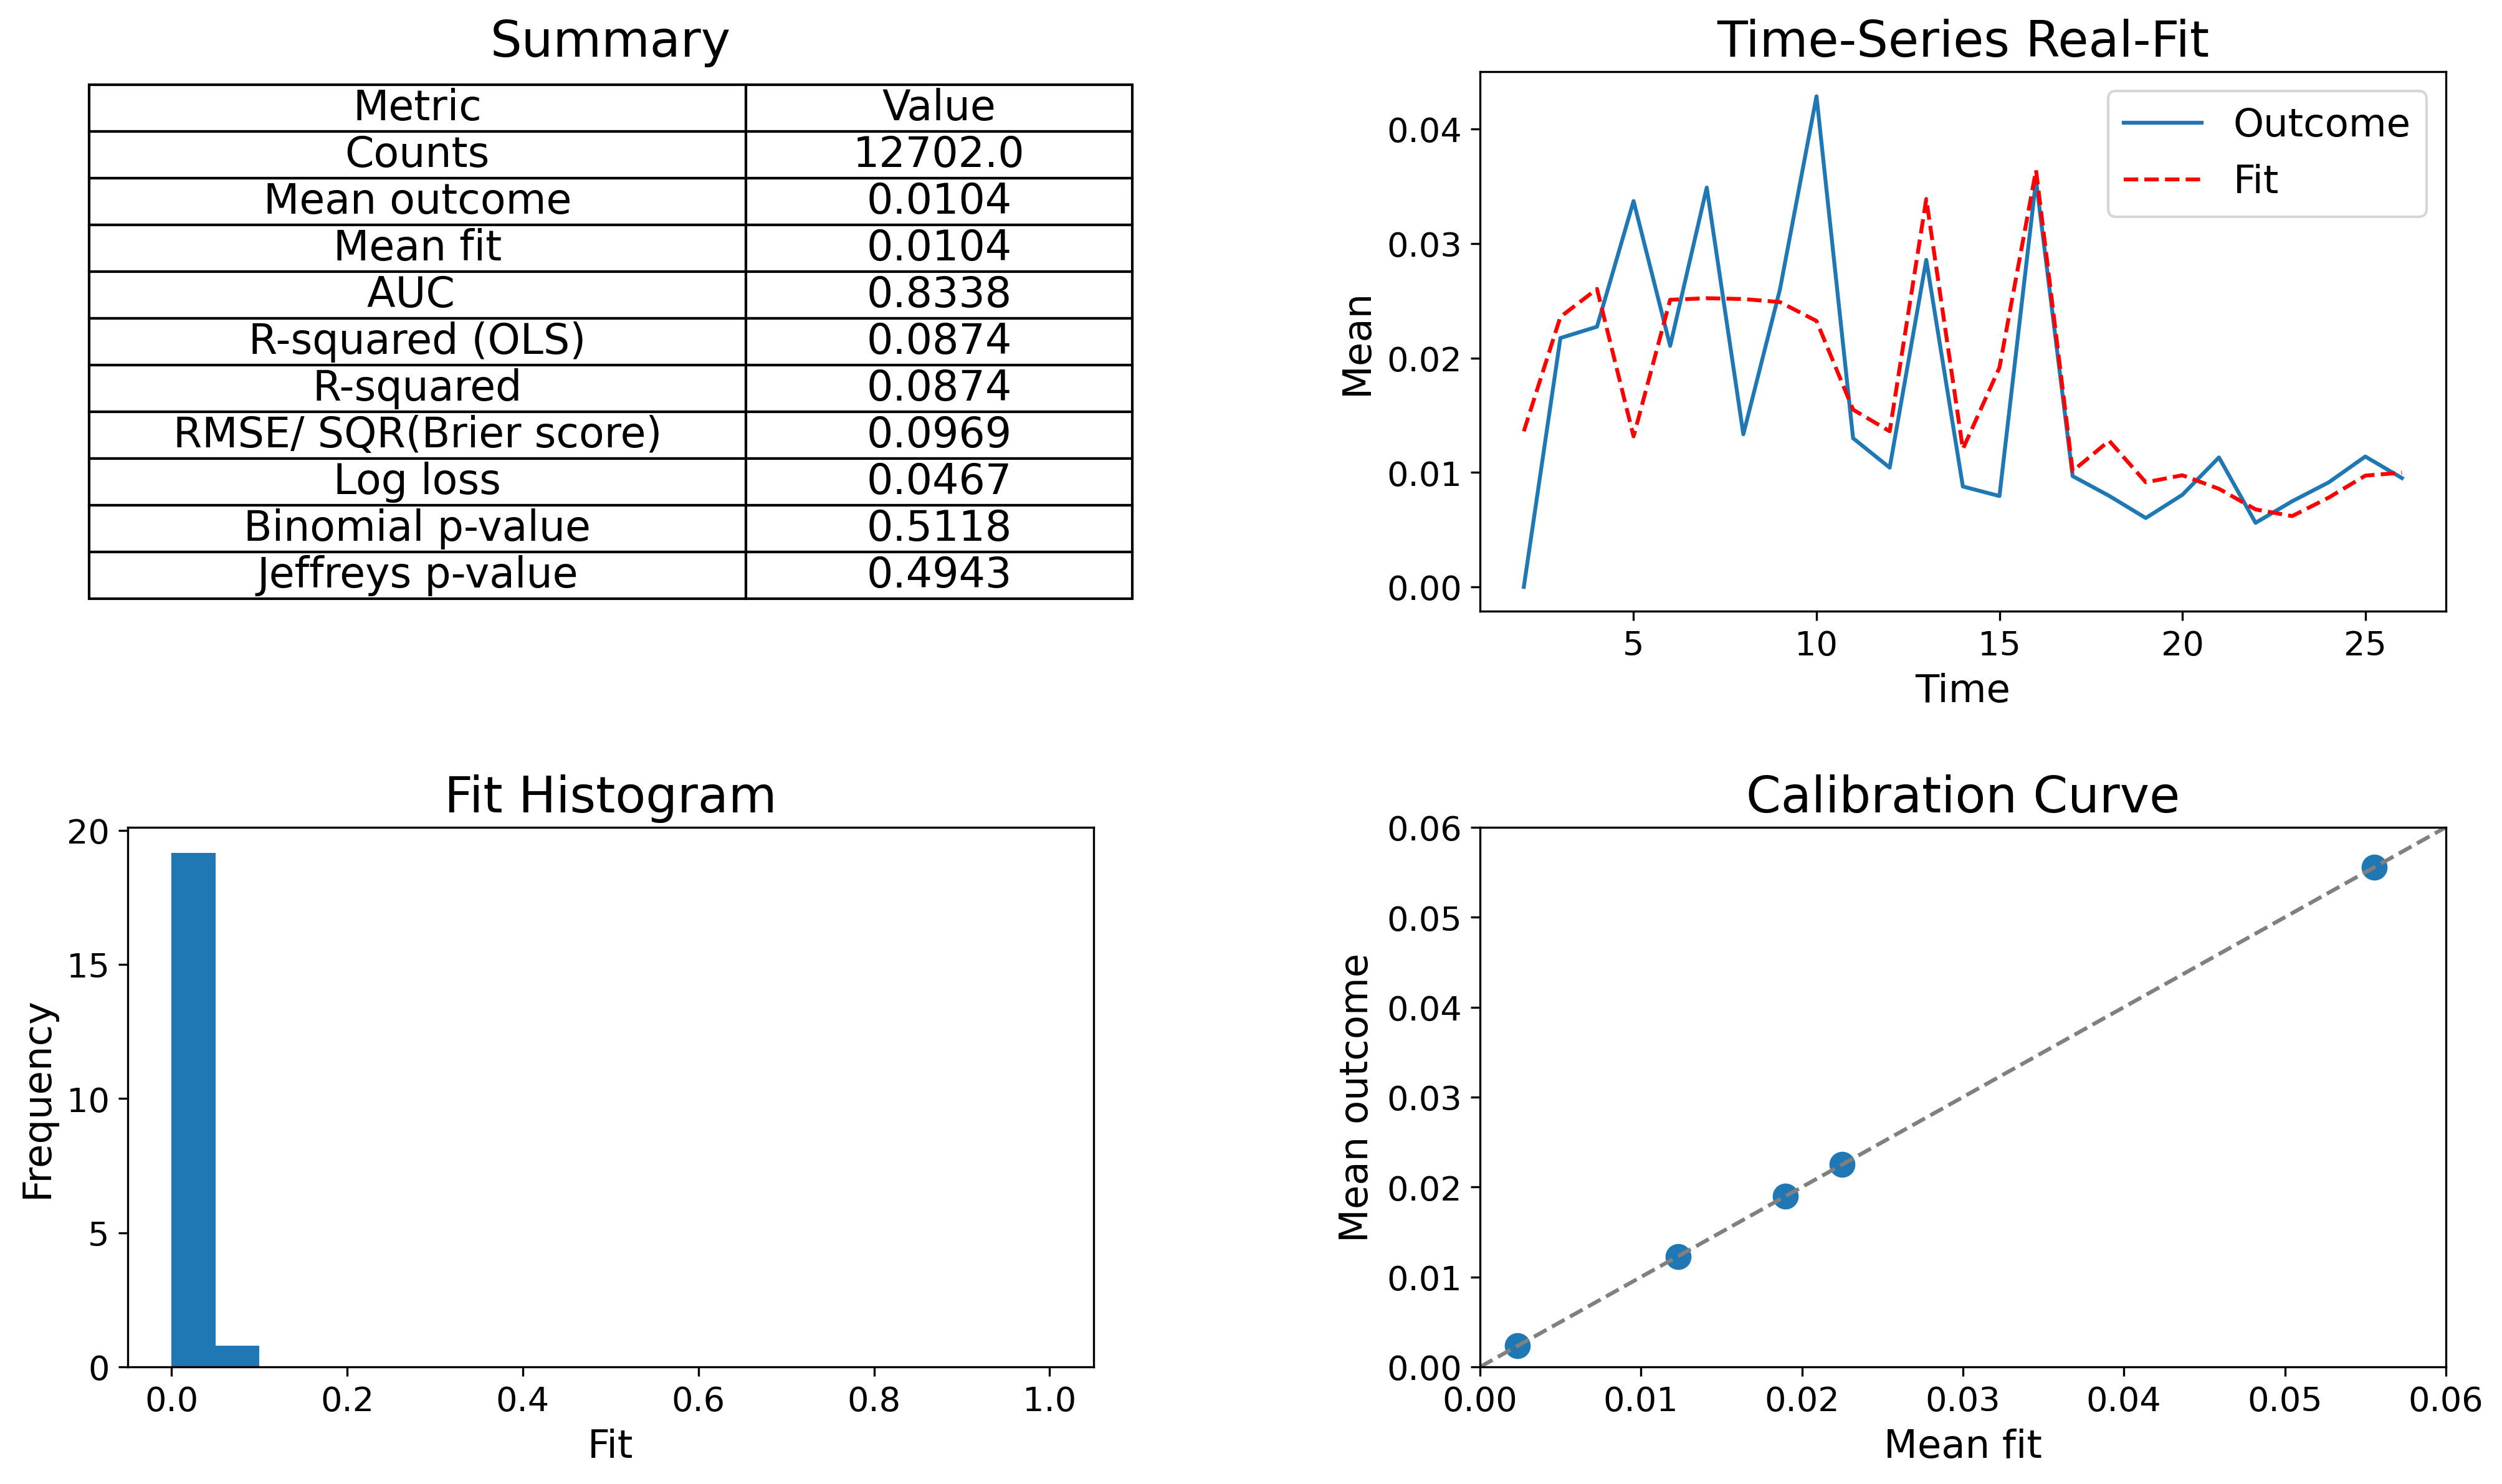

In [48]:
predictions_train = model_dt.predict_proba(X_train_scaled)[:,1].T  
validation(predictions_train, y_train, data_train['time'].values)  

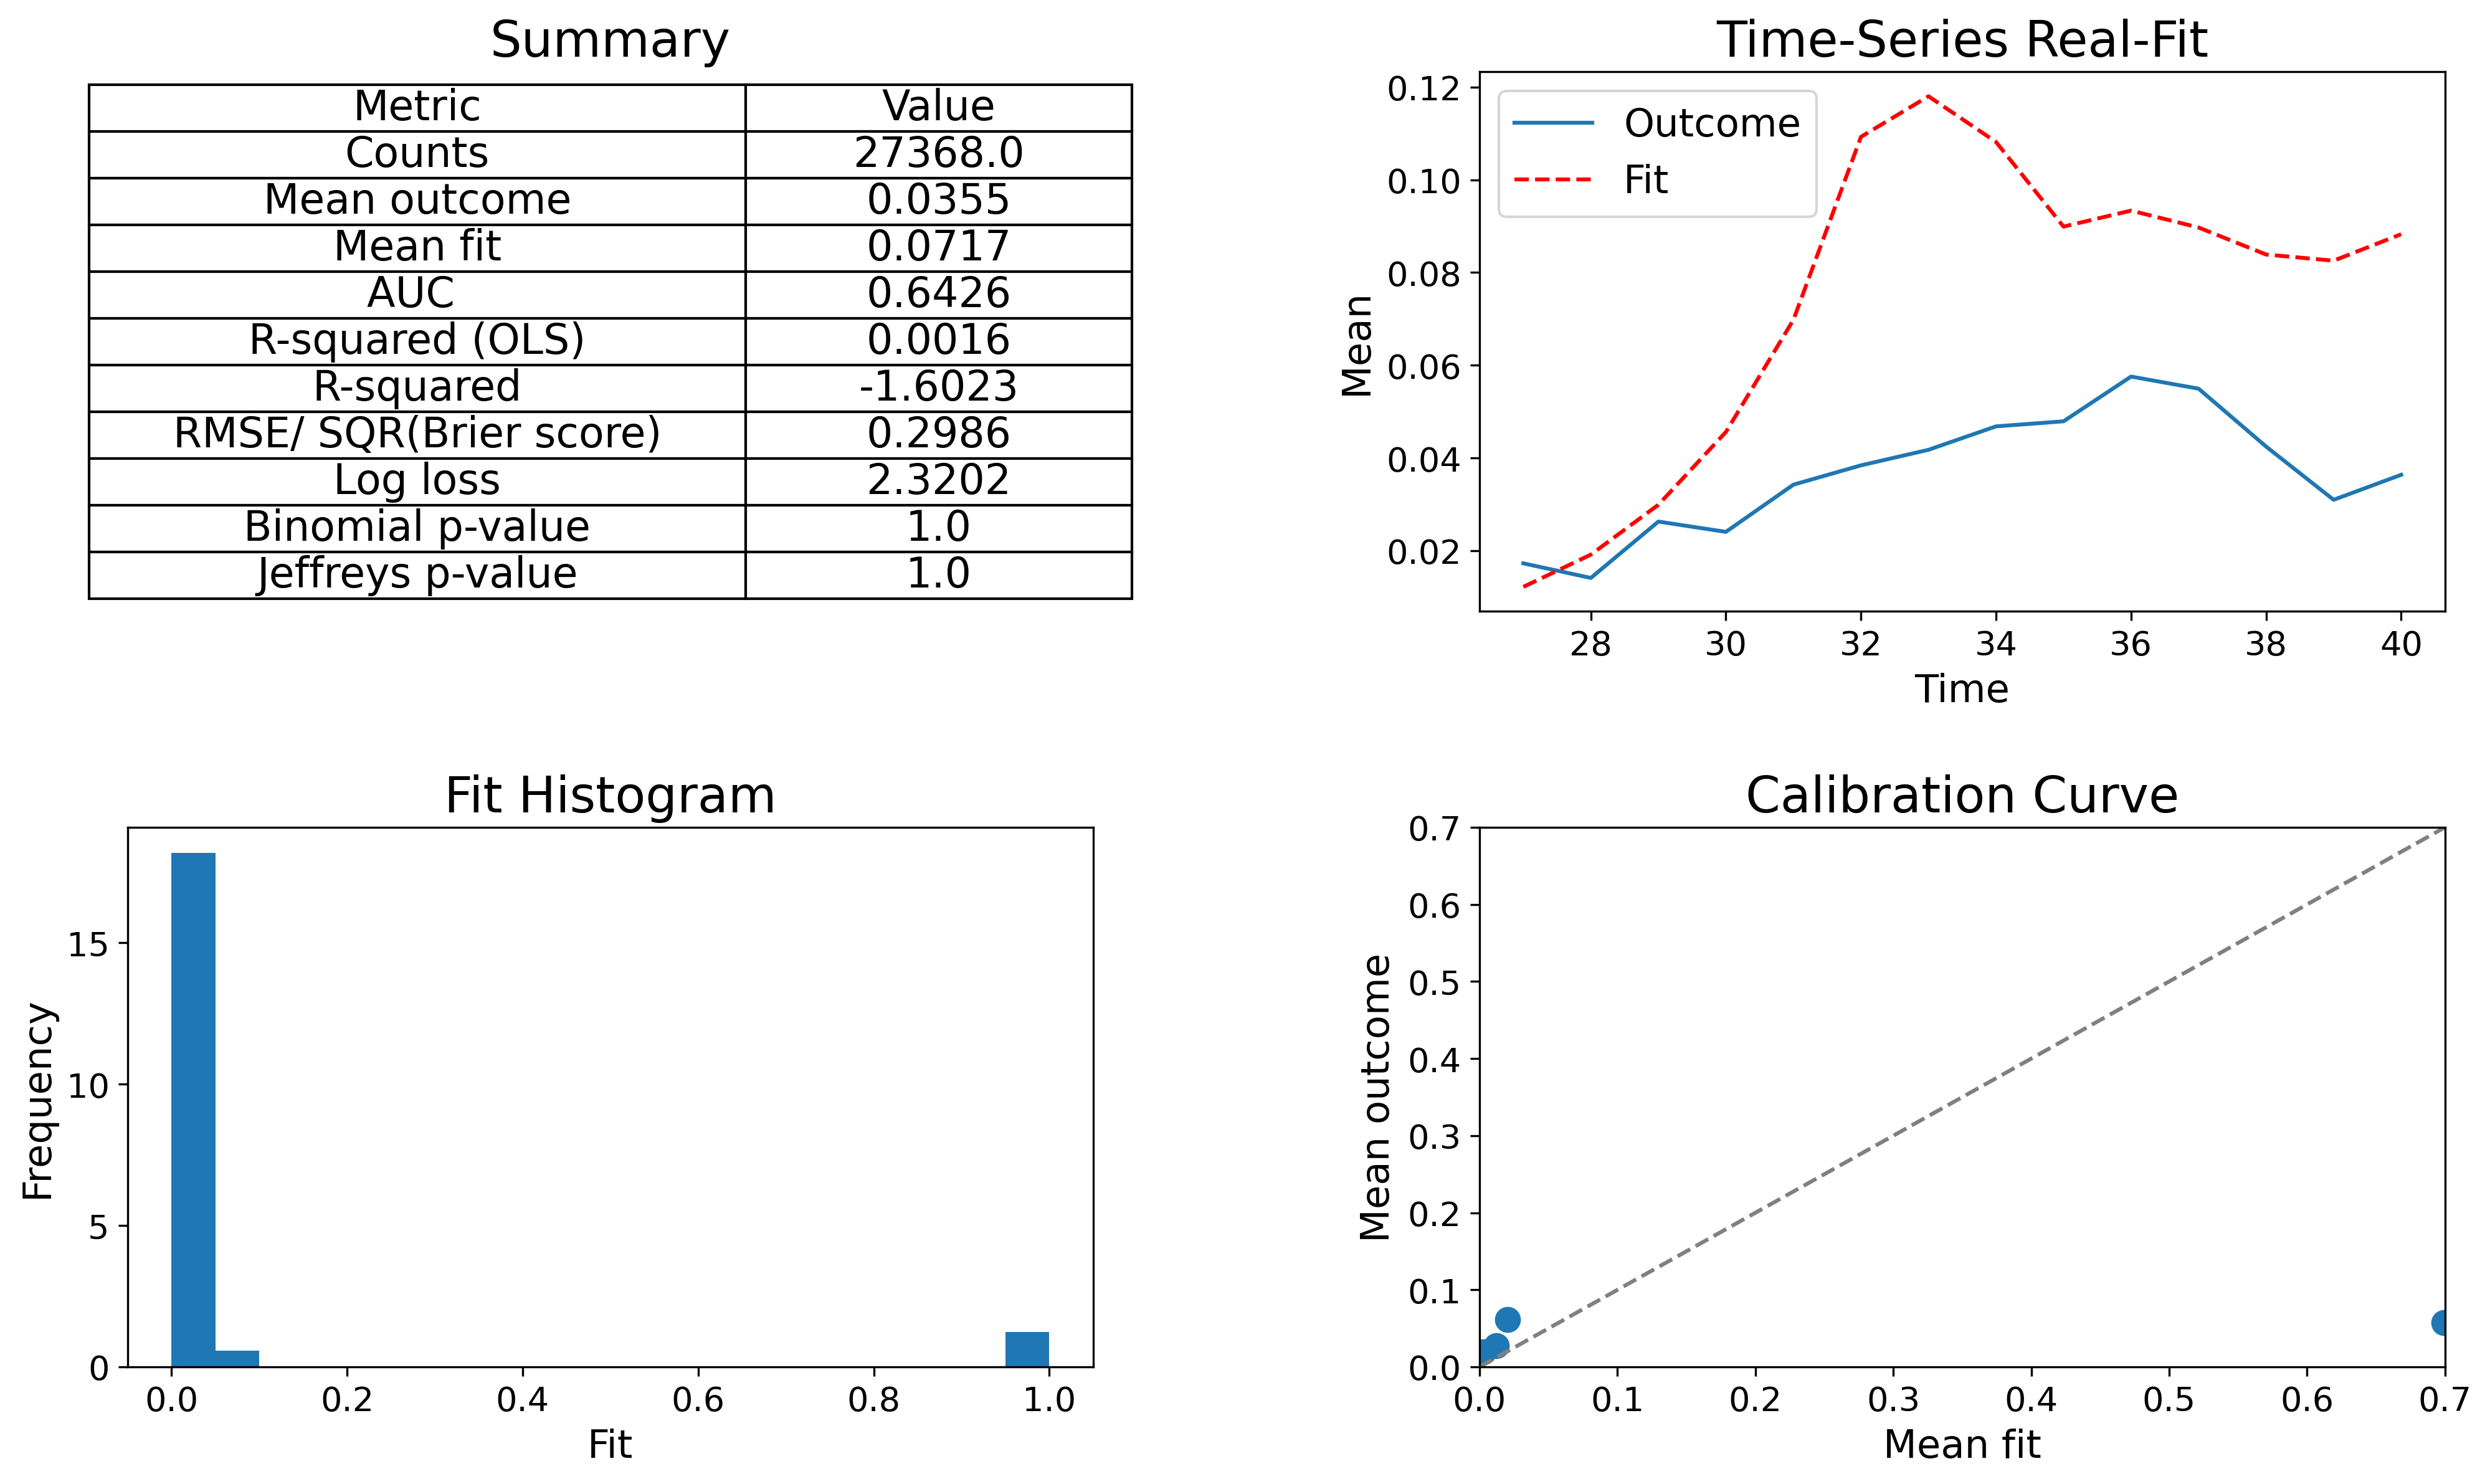

In [49]:
predictions_test = model_dt.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values)  
AUC_dt = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_dt = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4)  

In [50]:
params_dt = {  'max_depth': np.arange(2,10,1),  'max_features': np.arange(2,10,1)}  
model_dt = DecisionTreeClassifier(random_state=12345)  
gs_dt = GridSearchCV(model_dt, params_dt, verbose=1, n_jobs=2, cv=5, scoring='roc_auc')  
gs_dt.fit(X_train_scaled, y_train) 
print(gs_dt.best_params_)  


filename = 'Mortgage_dt_GridSearch.sav' 
pickle.dump(gs_dt, open(filename, 'wb'))  

Fitting 5 folds for each of 64 candidates, totalling 320 fits
{'max_depth': 4, 'max_features': 9}


In [51]:
filename = 'Mortgage_dt_GridSearch.sav' 
gs_dt = pickle.load(open(filename, 'rb')) 
model_dt_best = DecisionTreeClassifier(random_state=1234, max_depth = gs_dt.best_params_.get('max_depth'),  max_features = gs_dt.best_params_.get('max_features')) 
model_dt_best.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=4, max_features=9, random_state=1234)

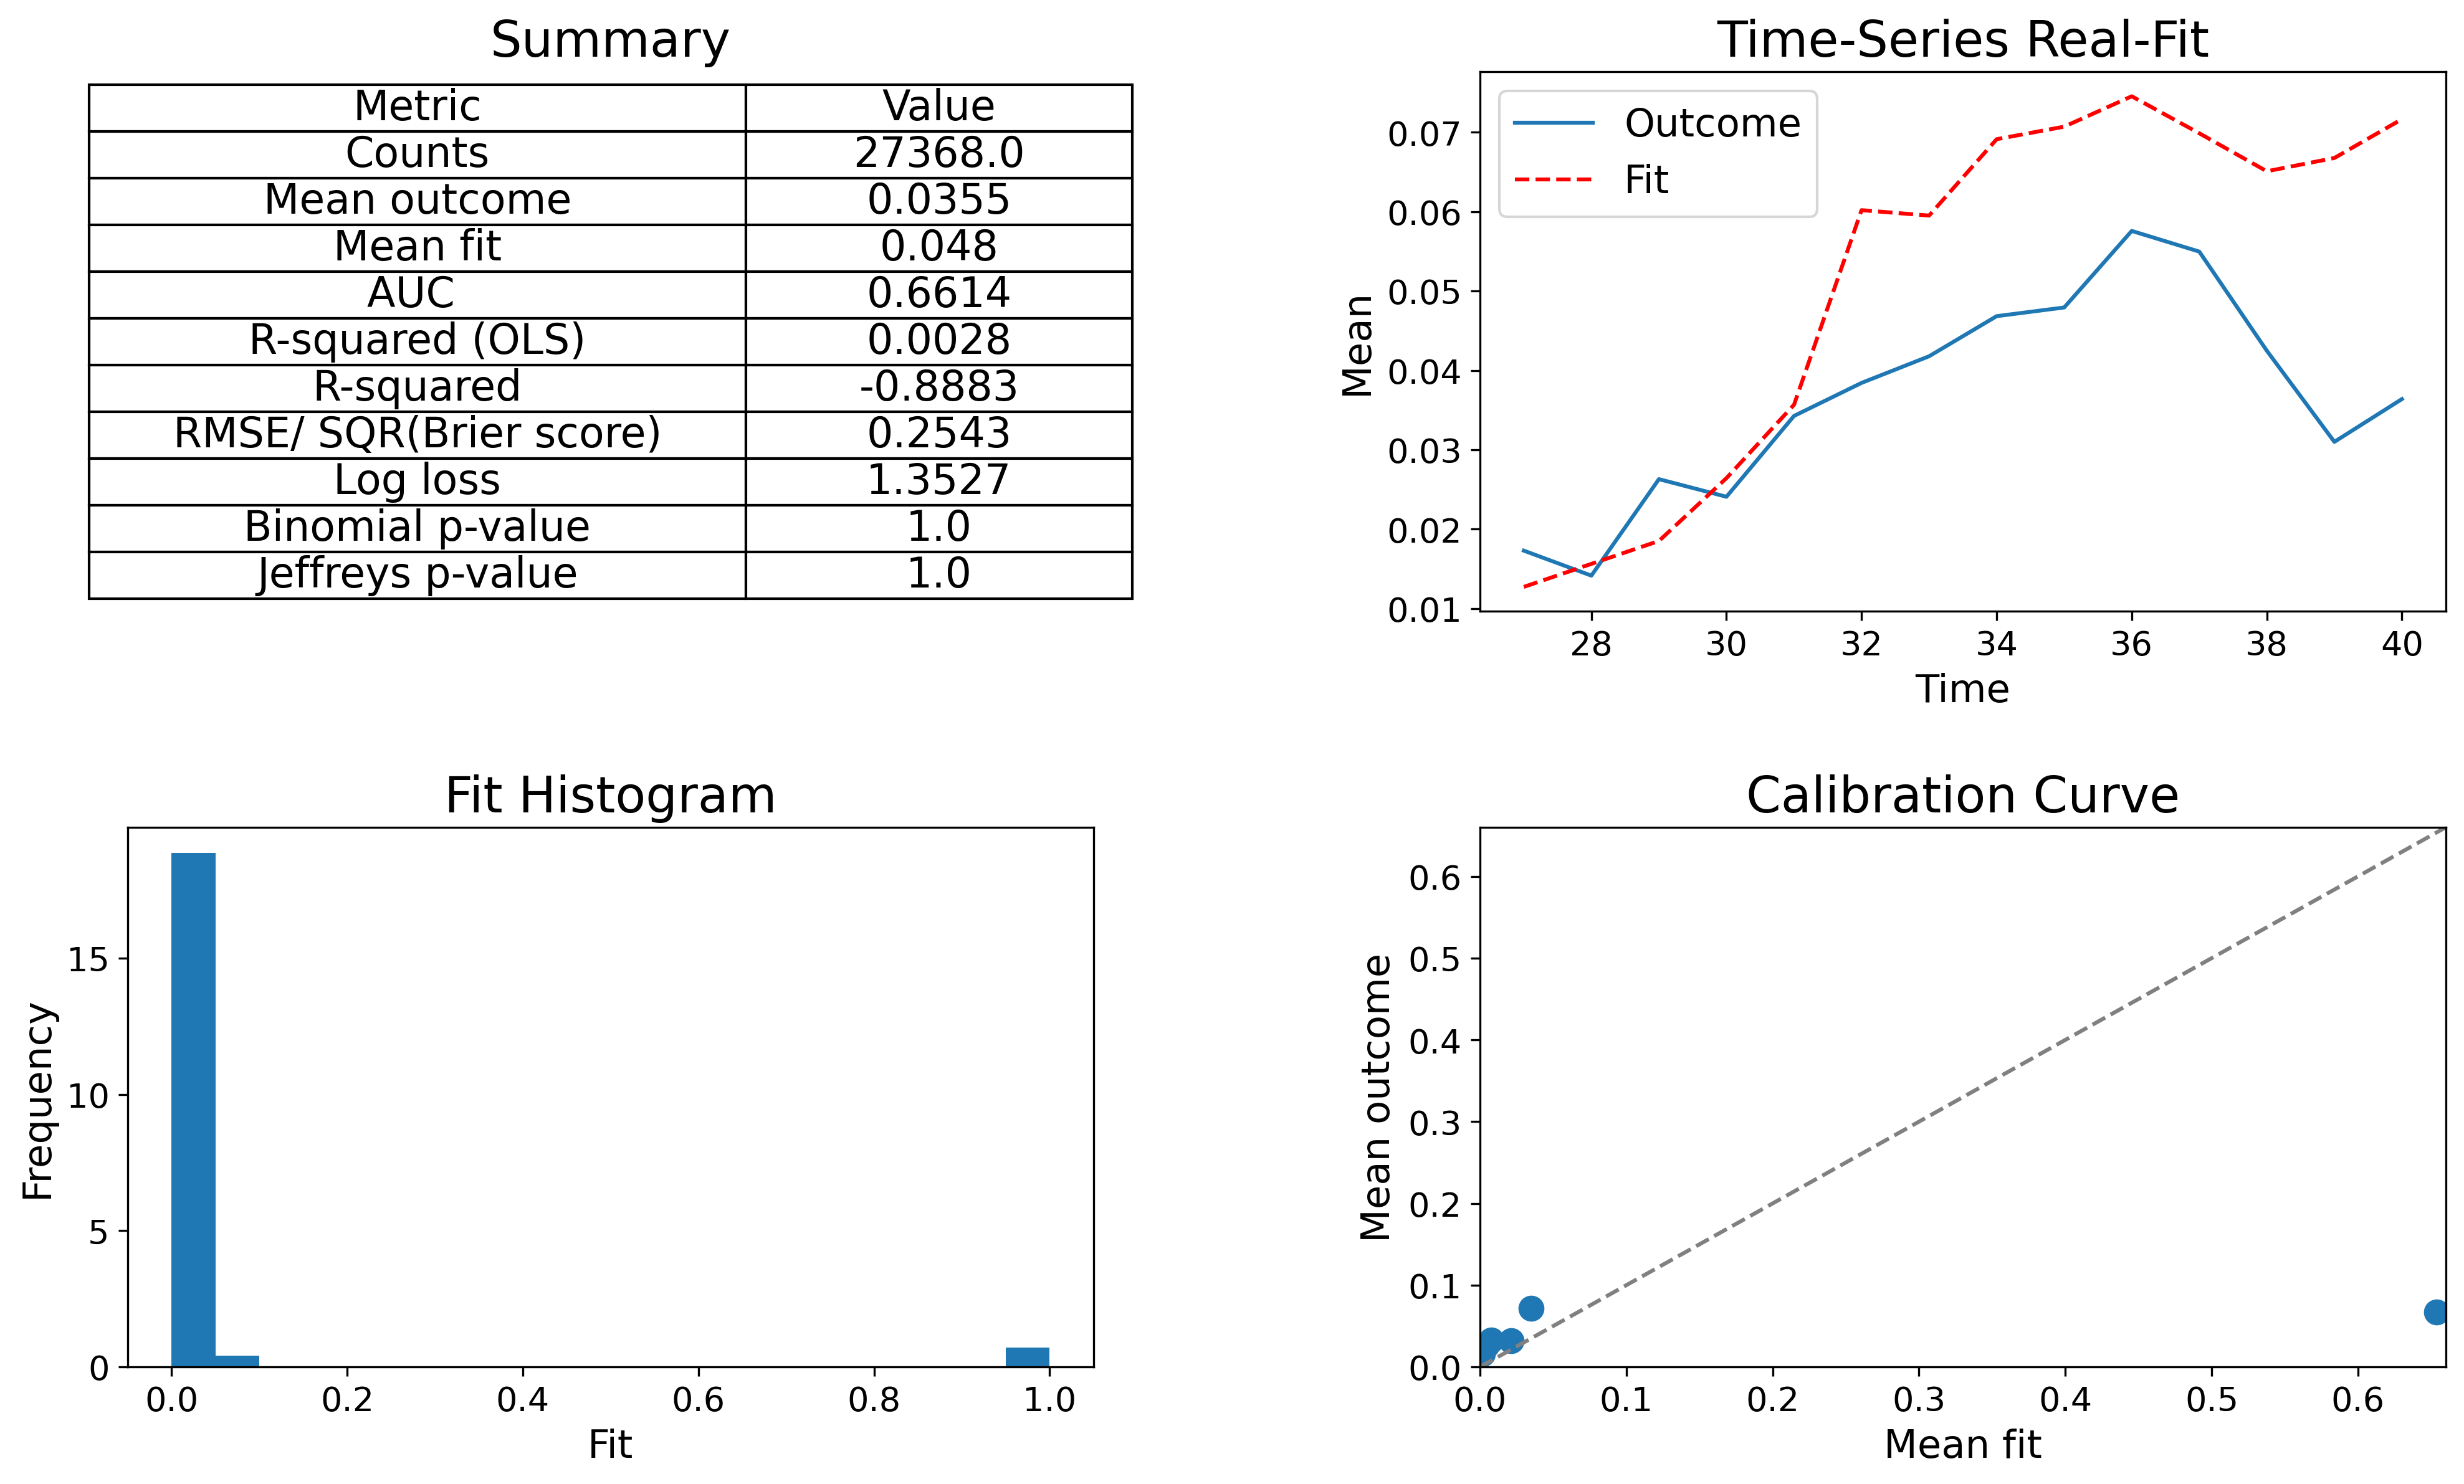

In [52]:
predictions_test = model_dt_best.predict_proba(X_test_scaled)[:,1].T 
validation(predictions_test, y_test, data_test['time'].values) 
AUC_dt_best = roc_auc_score(y_test, predictions_test).round(4)
sqrt_brier_dt_best = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 

In [53]:
model_dt_test = DecisionTreeClassifier(random_state=0, max_depth=1, max_features=11) 
model_dt_test.fit(X_train_scaled, y_train)  
print(model_dt_test.feature_importances_.round(4)) 

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [54]:
export_graphviz(model_dt_test,  out_file='model_dt_test.dot',  rounded=False, filled=True)  
(graph,) = pydot.graph_from_dot_file('model_dt_test.dot') 
graph.write_png('model_dt_test.png') 

from IPython.display import Image  

Image(filename = 'model_dt_test.png') 


NameError: name 'pydot' is not defined

In [55]:
model_svc = SVC(C=100, gamma='auto', kernel='linear', probability=True) 
model_svc.fit(X_train_scaled, y_train) 
print('Coefficients:', model_svc.coef_.round(decimals=4))  
print('Intercept:', model_svc.intercept_.round(decimals=4)) 
 

Coefficients: [[-0.0001 -0.0001  0.     -0.0001  0.0001 -0.      0.0002  0.0001  0.0001
  -0.0001  0.0001]]
Intercept: [-1.0005]


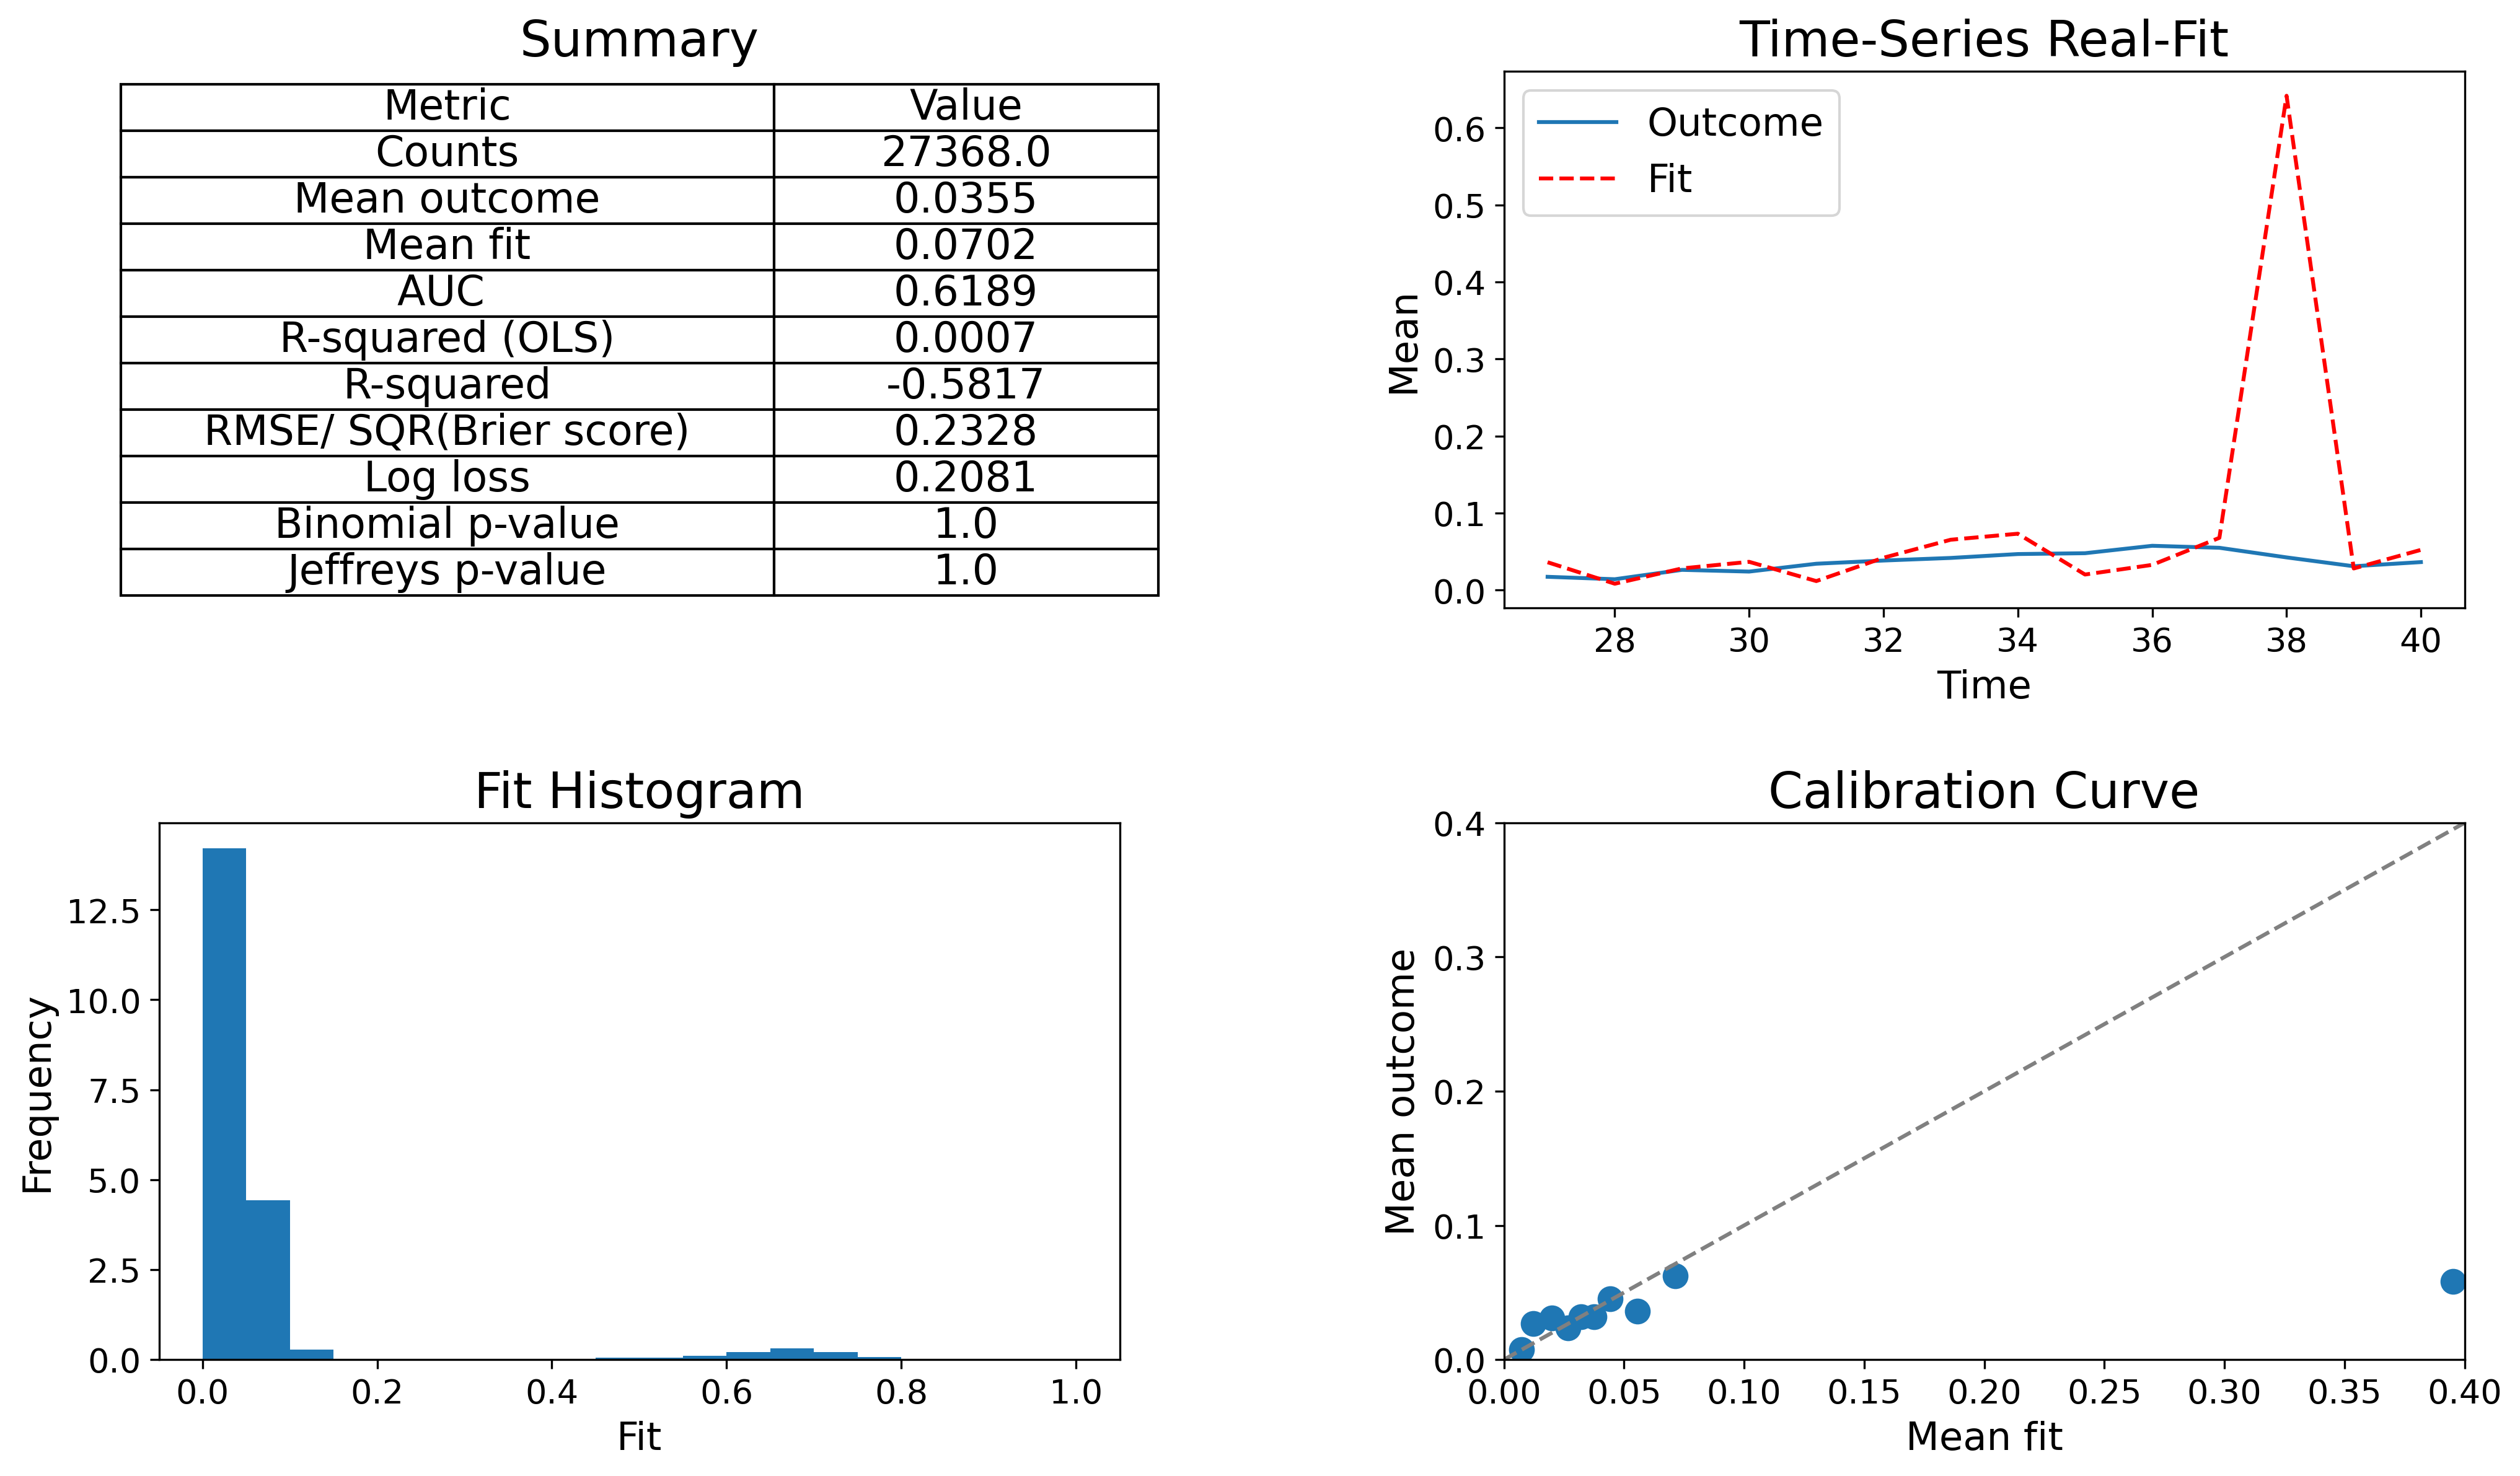

In [56]:
predictions_test = model_svc.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test['time'].values) 
AUC_svm = roc_auc_score(y_test, predictions_test).round(4)  
sqrt_brier_svm = np.sqrt(brier_score_loss(y_test, predictions_test)).round(4) 


In [57]:
result_table = pd.DataFrame([['Logistic Regression', AUC_logreg, sqrt_brier_logreg],  ['Logistic Regression (L1)', AUC_logreg_reg1, sqrt_brier_logreg_reg1],  ['Logistic Regression (CV 1)', AUC_logreg_reg2, sqrt_brier_logreg_reg2],  ['Logistic Regression (CV 2)', AUC_logreg_reg3, sqrt_brier_logreg_reg3],  ['KNN', AUC_knn, sqrt_brier_knn],  ['KNN (CV)', AUC_knn_best, sqrt_brier_knn_best],  ['Naive Bayes', AUC_nb, sqrt_brier_nb],  ['Decision Tree', AUC_dt, sqrt_brier_dt],  ['Decision Tree (CV)', AUC_dt_best, sqrt_brier_dt_best],  ['SVM', AUC_svm, sqrt_brier_svm]  ]).rename(columns={0:'Method', 1:'AUC', 2:'RMSE SQR(Brier score)'})  
pd.set_option('display.max_rows', None) 
print(result_table.sort_values(by='AUC', axis=0, ascending=False))

                       Method     AUC  RMSE SQR(Brier score)
1    Logistic Regression (L1)  0.6737                 0.1871
0         Logistic Regression  0.6732                 0.1871
2  Logistic Regression (CV 1)  0.6712                 0.1870
5                    KNN (CV)  0.6657                 0.1867
8          Decision Tree (CV)  0.6614                 0.2543
6                 Naive Bayes  0.6439                 0.5654
7               Decision Tree  0.6426                 0.2986
4                         KNN  0.6364                 0.1855
3  Logistic Regression (CV 2)  0.6321                 0.1866
9                         SVM  0.6189                 0.2328
